<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/winam_wh_regional_hierarchical_driver_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/winam_wh_regional_hierarchical_driver_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winam Gulf water hyacinth — **regional dynamic panel** driver model

**Question this notebook answers.** Does splitting Winam Gulf into a small number
of fixed, ecologically meaningful regions reveal environmental driver information
that a single gulf-wide monthly series cannot see — and does it do so *without*
pretending that grid cells are independent replicates?

**The response.** One number per **region** per **calendar month** — the
area-weighted regional mean of hard-class WH cover over a **fixed** cell
membership $C_r$:

$$\text{wh\_cover}_{r,t} \;=\;
\frac{\sum_{i \in C_r} \text{WH area}_{i,t}}
     {\sum_{i \in C_r} \text{valid classified area}_{i,t}}$$

Dividing by the *validly classified* area (not the region's total area) is what
makes months of different cloudiness comparable; fixing $C_r$ through time is
what stops a change in *which* cells were observed from masquerading as a change
in how much hyacinth there is.

---

## The one claim this notebook refuses to make

> Regionalisation **does not multiply the sample size** for a driver that has
> only one gulf-wide value per month.

If lake level is a single altimetry series, copying it into 8 regions produces 8
identical columns, not 8 independent observations. §10 measures, for **every**
driver, how much of its variance is between-region-within-month, and labels the
ones with no meaningful regional variation `temporal_only`. Those drivers are
still estimated — they are real mechanisms — but the notebook states plainly that
their effective replication is the number of **months**, not the number of
region-months. Only drivers labelled `spatiotemporal` gain genuine information
from the regional design.

## What is non-negotiable here (inherited, not re-litigated)

| Rule | Where it is enforced |
|---|---|
| the existing 500 m cell-month panel | §6 loader, §6b provenance gate |
| **hard-class** WH cover, no classifier-uncertainty weighting | §6b asserts the run manifest's `USE_PROBABILITY_RESPONSE = False` / `WEIGHT_COVER_BY_CONFIDENCE = False` |
| WH cover = WH area / **valid classified** area | §9 `regional_monthly_panel` |
| area-weighted aggregation | §9, weight = each cell's classified area that month |
| **fixed** regional cell membership through time | §8 assigns once from static covariates; §9 asserts membership never changes |
| the complete calendar-month grid, excluded months kept **missing** | §9d reindex; §11 missing-data audit |
| existing batch/run provenance controls | §6b |
| predeclared mechanisms and a-priori lags | §3e `REGIONAL_FORCING_TERMS` |
| endogenous optical proxies kept out of driver inference | §3e `REGIONAL_PROXY_TERMS`, reported descriptively only |
| **one observation per region per month** | §9, §11 — the 469,559 cell-month rows are never an inferential $n$ |

## Structure

| § | What it does |
|---|---|
| 1–3 | Install, imports, configuration (every threshold in one cell) |
| 4 | Helpers — loading, provenance, calendar, aggregation |
| 5 | Helpers — **response-blind** regionalisation, and §5c self-tests |
| 6 | Load the cell-month panel; provenance gate |
| 7 | Static covariate distributions; where each threshold comes from |
| 8 | **Build the regions**; audit, map, exports |
| 9 | **Region-month panel** — the inferential dataset |
| 10 | **Does the regional design add information?** Driver variance decomposition |
| 11 | Model dataset, standardisation, missing-data audit |
| 12 | The estimator — panel regression with AR(p) errors, month-clustered SEs |
| 13 | Step 1 — persistence structure selected on the **no-driver** model |
| 14 | Step 2 — matched null vs full: AICc and a month-clustered F-test |
| 15 | Diagnostics — residual autocorrelation, stationarity, collinearity, influence |
| 16 | Driver associations — clustered CIs, ROPE, conservative verdicts |
| 17 | Temporal validation — expanding-window, one calendar month ahead |
| 18 | Regional transfer — leave-one-region-out |
| 19 | Regionalisation sensitivity |
| 20 | Figures |
| 21 | Exports and run manifest |
| 22 | Synthesis; implementation summary |
| 23 | Validation assertion table |
| 24–25 | How to read the model; implementation summary |

## How long it takes

**The whole notebook runs in well under a minute.** Every model is a least-squares
fit: the estimator has no shortcuts to take and no sampler to converge, so
`FAST_MODE` does **not** weaken any fit. It changes one thing only — how many of
the predeclared §19 regionalisation variants are re-run — and every exported
table still records which mode produced it. **`FAST_MODE = False` is the
configuration any reported number must come from.**

Because a validation fold costs milliseconds rather than hours, §17 uses **every
feasible origin** rather than a handful, and §18 withholds **every** region.

`USE_SYNTHETIC_DEMO = True` builds a synthetic *cell-month panel* — geography,
static covariates, gulf-wide and regionally-varying drivers, a known common
temporal signal, known regional intercepts and known driver slopes — and runs the
entire pipeline, regionalisation included, with no Google Drive. It is a
recovery test, never a result: every exported table carries `is_synthetic`.


## 1. Install packages

**Nothing needs installing.** Colab already has numpy / pandas / scipy /
statsmodels / matplotlib, and every model in this notebook is a least-squares
fit in statsmodels. The whole of §12–§19 runs in seconds.

`geopandas` is optional and only affects the GeoPackage export and the shoreline
overlay on the map — the region map itself is drawn from the grid cells with
matplotlib and needs nothing extra. `shapely` and `pyproj` (both bundled with
geopandas, and both already present on Colab) are used in §7a-ii for the river
network.


In [1]:
# Colab: nothing to install. Uncomment only if a runtime is missing them.
# !pip -q install geopandas          # optional: GeoPackage export + shoreline overlay


## 2. Imports and Google Drive mount

Every optional dependency is guarded. A missing package changes *what runs* and
says so; it never changes whether the notebook runs.


In [2]:
from pathlib import Path
import json
import math
import time
import warnings
from collections import deque

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

import scipy.stats as sstats
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*No frequency information was provided.*")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 90)

IN_COLAB = False
try:  # pragma: no cover - Colab only
    from google.colab import drive  # noqa: F401
    IN_COLAB = True
except Exception:
    pass

DRIVE_MOUNTED = False
if IN_COLAB:  # pragma: no cover - Colab only
    try:
        drive.mount("/content/drive", force_remount=False)
        DRIVE_MOUNTED = True
    except Exception as exc:
        print("Drive mount failed:", exc)

try:
    from IPython.display import display  # noqa: F401
except Exception:  # pragma: no cover - non-IPython
    display = print

print(f"Colab: {IN_COLAB} | Drive mounted: {DRIVE_MOUNTED}")
print(f"numpy {np.__version__} | pandas {pd.__version__} | statsmodels {sm.__version__}")

# --- geopandas: OPTIONAL, for the GeoPackage export and shoreline overlay ----
try:
    import geopandas as gpd
    from shapely.geometry import box as shapely_box
    HAVE_GEOPANDAS = True
    print(f"geopandas {gpd.__version__}")
except Exception as exc:
    HAVE_GEOPANDAS = False
    gpd = None
    shapely_box = None
    print(f"geopandas unavailable -> GeoPackage export and the shoreline overlay "
          f"are skipped; the region map and CSV exports still run: {exc}")

# --- shapely + pyproj: needed for the mapped river network in §7a-ii ---------
# Both ship with geopandas, but they are imported separately because §7a-ii
# needs only them, and the river covariate is worth having even where the
# GeoPackage export is not available.
try:
    import shapely
    import shapely.geometry
    import shapely.ops
    import pyproj
    HAVE_SHAPELY = hasattr(shapely, "distance")   # shapely >= 2.0
    print(f"shapely {shapely.__version__} | pyproj {pyproj.__version__}"
          + ("" if HAVE_SHAPELY else "  (shapely < 2.0 -> §7a-ii skipped)"))
except Exception as exc:
    HAVE_SHAPELY = False
    shapely = pyproj = None
    print(f"shapely/pyproj unavailable -> §7a-ii falls back to the panel's "
          f"dist_majriver_m: {exc}")


Mounted at /content/drive
Colab: True | Drive mounted: True
numpy 2.0.2 | pandas 2.2.2 | statsmodels 0.14.6
geopandas 1.1.4
shapely 2.1.2 | pyproj 3.7.2


## 3. Configuration

Every decision that changes a number lives in this one cell. The regionalisation
thresholds in §3c are the ones a reader will interrogate hardest, so each records
**where it came from** — a repository precedent, or an operational definition
with a response-blind fallback and a sensitivity variant.


In [3]:
# =====================================================================
# 3a. Where the data comes from
# =====================================================================
# The 500 m cell-month panel exported by winam_wh_spatial_panel_driver_gam.ipynb
# §17: OUTPUT_DIR / f"wh_spatial_panel_{CELL_SIZE_M}m_{run_tag}_{start}_to_{end}.csv"
# It carries the hard-class response (wh_area_ha, valid_area_ha, wh_cover,
# wh_present), the static habitat covariates used to build the regions, and the
# merged environmental covariates. Set PANEL_CSV explicitly, or leave it None to
# take the most recent match of PANEL_GLOB in PANEL_DIR.
PANEL_DIR = Path("/content/drive/MyDrive/WH_spatial_panel_test")
PANEL_CSV = None
PANEL_GLOB = "wh_spatial_panel_*.csv"

# The run manifest written beside the panel by the same section. Read (not
# required) so §6b can check the provenance controls rather than assume them.
PANEL_MANIFEST_GLOB = "driver_gam_run_manifest_*.json"

# The COMPLETE monthly environmental tables exported by the spatial workflow.
# These are loaded independently of whether a WH map passed its coverage
# threshold (§6c), which is exactly what the state-space model needs: the driver
# process must continue through months the response does not cover.
EE_MONTHLY_GLOB = "ee_monthly_covariates_*.csv"
EE_CELLMONTH_GLOB = "ee_cellmonth_covariates_*.csv"

# Optional extra monthly series merged on `month` (one row per month) - e.g.
# gauged discharge, an ENSO/IOD index, measured nutrients. Gulf-wide by
# construction, so §10 will label anything from here `temporal_only`.
EXTRA_MONTHLY_CSV = None

# Optional shoreline / AOI polygon for the map. The repository ships one at
# aoi/winam_gulf_main_lake_aoi.geojson (EPSG:4326); the notebook falls back to
# the boundary of the eligible cell set when it is absent or geopandas is not
# installed.
SHORELINE_GEOJSON_CANDIDATES = [
    Path("aoi/winam_gulf_main_lake_aoi.geojson"),
    Path("/content/Dissertation/aoi/winam_gulf_main_lake_aoi.geojson"),
    Path("/content/drive/MyDrive/WH_drivers/winam_gulf_main_lake_aoi.geojson"),
]

OUTPUT_DIR = Path("/content/drive/MyDrive/WH_regional_hierarchical_model")

# Run the whole pipeline - regionalisation included - on a synthetic cell-month
# panel with KNOWN common persistence, regional intercepts and driver slopes, and
# no Drive. Use it to (a) check the notebook end-to-end and (b) confirm the
# machinery recovers effects that are genuinely there. Never report synthetic
# numbers: every exported table is tagged is_synthetic.
USE_SYNTHETIC_DEMO = False
SYNTHETIC_SEED = 20260810
SYNTHETIC_N_MONTHS = 108
SYNTHETIC_MISSING_FRACTION = 0.18     # calendar months excluded by the coverage filter
SYNTHETIC_DOMAIN_KM = (40.0, 18.0)    # an elongated gulf, open at one end
SYNTHETIC_CELL_SIZE_M = 500           # the same 500 m lattice as the real panel

# =====================================================================
# 3b. Provenance controls (inherited from the panel build)
# =====================================================================
# These are CHECKS, not switches. §6b compares them against the panel and its
# run manifest and refuses to continue when the panel is not the one this
# notebook is entitled to analyse.
EXPECTED_CELL_SIZE_M = 500
# Projected CRS the panel's x_km / y_km centroids live in (UTM 36S), used only to
# write the region GeoPackage and to place the shoreline overlay.
PANEL_CRS = "EPSG:32736"
# The response must be the hard-class one. The panel build exposes these flags;
# a panel built with either of them True is a different estimand.
REQUIRE_HARD_CLASS_RESPONSE = True
# Set to e.g. "S2_only" or "S2+S1" to pin the sensor run; None accepts whatever
# the panel says and records it.
REQUIRE_RUN_TAG = None
# Columns whose presence means the panel carries batch/run provenance. Recorded
# in the manifest and printed; a panel mixing several is reported, never merged
# silently.
PROVENANCE_COLUMNS = ["sensor", "source_export_token", "source_file",
                      "classifier_version", "batch_id", "run_tag"]

# =====================================================================
# 3c. Regionalisation - thresholds and minimum sizes  (RESPONSE-BLIND)
# =====================================================================
# NOTHING in this block may be derived from WH cover, WH prevalence, model
# residuals, temporal environmental values or any classification output. §5a
# enforces that with `assert_response_blind`, which raises on a response-derived
# column name.
#
# Provenance of each threshold (searched for in the repository first; see §7b):
#   river_dist_m  5000  - reuses the 5 km radius already used to build
#                         `openness_index` (EE circle kernel, 5000 m) as the
#                         gulf's established local-influence length scale, and
#                         "major river" is the repository's own definition
#                         (HydroSHEDS RIV_ORD <= EE_RIVER_MAJOR_MAX_ORD = 7).
#   shore_dist_m  2000  - reuses EE_CATCHMENT_BUFFER_M = 2000 m, the repository's
#                         existing local catchment-influence buffer.
#   openness      None  - NO repository precedent. Resolved response-blind as a
#                         quantile of `openness_index` among littoral cells
#                         (OPENNESS_FALLBACK_QUANTILE) and printed as an
#                         OPERATIONAL DEFINITION.
#   depth_m       None  - optional; when set, a cell deeper than this is forced
#                         to open_gulf even if it is close to shore.
REGION_THRESHOLDS = {
    "river_dist_m": 5000.0,
    "shore_dist_m": 2000.0,
    "openness": None,
    "depth_m": None,
}
OPENNESS_FALLBACK_QUANTILE = 0.50     # median openness among littoral cells
# When a threshold is None and no quantile rule is given the class collapses into
# its parent class, and §8 says so rather than inventing a number.

# A configured threshold is only worth anything if it actually PARTITIONS THIS
# AOI. A cut inherited from another context can sit entirely outside the local
# distribution and then silently classifies everything one way. That is not
# hypothetical here: Winam Gulf is small enough that every eligible cell lies
# within ~3.8 km of a HydroSHEDS RIV_ORD <= 7 river, so the 5000 m river cut
# above puts 100% of cells in `river_influenced_bay`, no cell ever reaches the
# shore/openness rules, and the regionalisation collapses to ONE region.
#
# §7c therefore measures, for every configured cut, the share of eligible cells
# the class rule would place inside it. A cut whose share falls outside the band
# below does not partition the AOI and is replaced by the PRE-DECLARED
# response-blind quantile of that covariate's own distribution, exactly as
# `openness` has always been resolved. Both the check and the replacement read
# static geography only — never WH cover, prevalence, residuals or model skill.
#
# The quantiles are declared HERE, before any threshold is resolved, so they can
# never be tuned to a result. §19 varies them as predeclared sensitivity
# variants.
THRESHOLD_DISCRIMINATION_BAND = (0.05, 0.95)
THRESHOLD_FALLBACK_QUANTILES = {
    "river_dist_m": 0.25,   # the quarter of the gulf nearest a major river mouth
    "shore_dist_m": 0.50,   # the littoral half
    "openness": OPENNESS_FALLBACK_QUANTILE,
    "depth_m": None,        # stays unset; the class collapses into its parent
}

# --- the river network the river-distance covariate is measured from ---------
# The panel's `dist_majriver_m` comes from Earth Engine's HydroSHEDS
# `RIV_ORD <= EE_RIVER_MAJOR_MAX_ORD = 7` cut. For a water body this small that
# order is far too permissive: it places EVERY eligible Winam Gulf cell within
# 3,746 m of a "major river" (77 m at the closest), so the covariate spans a
# factor of fifty and cannot separate a river-influenced bay from open water.
#
# `aoi/winam_major_rivers.geojson` in this repository is a mapped river network
# (KEN_Rivers, ILRI / OCHA Kenya, 1:250,000, built by
# `aoi/make_winam_major_rivers.py`). It carries, for every named watercourse,
# its total mapped course length and its distance to the analysed water body.
# The two thresholds below decide which of those count as MAJOR, and §7a-ii
# measures each cell's distance to the nearest one as `dist_majriver_local_m`.
#
# Both thresholds are declared HERE, before anything is fitted, and neither may
# be chosen by looking at WH cover. A named watercourse qualifies when it is
# long enough to have a real catchment AND close enough to discharge into the
# analysed water body — a long river that never approaches the gulf is not a
# source of river influence on it.
#
# WHERE THE LAYER COMES FROM. The default is GitHub: the layer is versioned in
# this repository beside the notebook that reads it, so a Colab runtime needs
# nothing staged on Drive by hand and every run of this notebook — on any
# machine, by anyone — reads the same file. Local paths are tried FIRST so a
# deliberately modified layer still wins; §7a-ii prints which source was used
# and the SHA-256 of the bytes it actually read, and both go into the run
# manifest, so "which river network produced this number" is answerable after
# the fact.
RIVER_VECTOR_REPO = "Qalani/Dissertation"
RIVER_VECTOR_PATH = "aoi/winam_major_rivers.geojson"
# Tried in order. The first entry is a COMMIT SHA, not a branch: a branch name
# resolves to whatever that branch points at today, so a run that reads `main`
# is reproducible only for as long as nobody touches the layer. A commit SHA is
# immutable, survives the branch being deleted, and makes "which river network
# produced this number" answerable from the notebook alone.
#
# `main` follows as a safety net so the notebook still runs if the pinned commit
# is ever unreachable — and because the digest below is verified either way, a
# fallback that quietly served different bytes could not pass unnoticed.
#
# To adopt a NEW river layer: regenerate it with aoi/make_winam_major_rivers.py,
# commit it, then update BOTH the SHA below and RIVER_LAYER_EXPECTED_SHA256.
RIVER_VECTOR_REFS = [
    "31491ab52eb265c2b991a6393e254958ac0ab895",   # added aoi/winam_major_rivers.geojson
    "main",
]
# SHA-256 of the layer's bytes. §7a-ii checks what it read against this and says
# so loudly on a mismatch, so the pin above is verified rather than trusted.
# Set to None to accept whatever is found (and record its digest anyway).
RIVER_LAYER_EXPECTED_SHA256 = (
    "a9f1a4c416d744e05690ceb5f93e55b2ea8aefc5d37d8eaef6beda03196b5779")
RIVER_VECTOR_CANDIDATES = [
    # explicit local overrides win, if a copy has been staged deliberately
    "/content/drive/MyDrive/WH_regional_hierarchical_model/winam_major_rivers.geojson",
    "/content/drive/MyDrive/winam_major_rivers.geojson",
    "aoi/winam_major_rivers.geojson",
    "../aoi/winam_major_rivers.geojson",
] + [f"https://raw.githubusercontent.com/{RIVER_VECTOR_REPO}/{_ref}/"
     f"{RIVER_VECTOR_PATH}" for _ref in RIVER_VECTOR_REFS]
RIVER_MAJOR_MIN_LENGTH_KM = 20.0      # a major river has a real catchment
RIVER_MAJOR_MAX_GULF_DIST_KM = 10.0   # ...and it must actually reach the gulf
# When the layer cannot be found the notebook falls back to the panel's
# `dist_majriver_m` and says so loudly. It does not silently proceed as though
# nothing changed, because on this AOI that column is the reason the first run
# collapsed.
REQUIRE_LOCAL_RIVER_VECTOR = False

# Column preferences. The first present column is used; the choice is printed.
# `dist_majriver_local_m` (§7a-ii, mapped network) outranks the panel's
# HydroSHEDS-derived column when it is available.
REGION_COVARIATE_PREFERENCE = {
    "river_dist_m": ["dist_majriver_local_m", "dist_majriver_m", "dist_river_m"],
    "shore_dist_m": ["dist_shore_m"],
    "openness": ["openness_index", "gsw_water_fraction"],
    "depth_m": ["depth_m"],
}

# Contiguity used to split a class into geographically disconnected units.
REGION_CONTIGUITY = "queen"           # "queen" (8-neighbour) or "rook" (4-neighbour)

# Minimum requirements for a region to be USABLE. A component below any of these
# is merged into the most physically similar adjacent region (§5b); if it has no
# adjacent region it is dropped and reported.
MIN_REGION_CELLS = 40                 # >= 10 km2 at 500 m
MIN_REGION_ELIGIBLE_AREA_HA = 1000.0  # eligible (mask-passing) water area
MIN_REGION_MONTHS = 24                # retained months the region must have
MIN_REGION_MEDIAN_COVERAGE = 0.70     # median cell-coverage fraction across months

# Target band, reported but never forced. If fewer regions clear the
# requirements, fewer are kept and §8d states the consequence for hierarchical
# estimation (a small number of groups makes between-region variances weakly
# identified).
REGION_COUNT_TARGET = (6, 12)

# ...and a HARD floor, which is not a preference. ONE REGION IS NOT A REGIONAL
# DESIGN. With R = 1 the between-region variances have no groups to be estimated
# from, every month-cluster holds a single observation so the clustered
# covariance has nothing to pool over, and §10's between-region variance shares
# are 0 by ARITHMETIC rather than by measurement — which then
# reads as "no driver varies regionally" when nothing was actually tested.
# §8a stops the run rather than emitting tables that look like results.
REGION_COUNT_HARD_MIN = 2
# Escape hatch for deliberate inspection of a collapsed regionalisation. Leave
# False for any run whose numbers might be quoted.
ALLOW_DEGENERATE_REGIONALISATION = False

# =====================================================================
# 3d. Region-month panel gates
# =====================================================================
# Gulf-wide month filter, inherited from the panel/AOI workflow: a month enters
# only if it classified this share of the eligible water cells.
MIN_MONTHLY_COVERAGE_FRACTION = 0.90
# Fixed cell membership: a cell joins a region only if it is validly observed in
# at least this share of the retained months (mirrors MIN_CELL_MONTH_FRACTION in
# the AOI temporal notebook, so the two analyses use the same discipline).
MIN_CELL_MONTH_FRACTION = 0.80
# A region-month must pass BOTH gates to be an observation.
MIN_REGION_MONTH_CELL_COVERAGE = 0.70        # observed cells / eligible cells
MIN_REGION_MONTH_VALID_AREA_COVERAGE = 0.70  # valid area / that region's best month

RESPONSE_TRANSFORM = "logit"
RESPONSE_EPS = 1e-4

# =====================================================================
# 3e. Drivers - mechanism, a-priori sign, a-priori lag
# =====================================================================
# ONE representation per mechanism, with the sign the mechanism requires and the
# lag at which it acts. Identical discipline (and, where the columns exist,
# identical entries) to TEMPORAL_FORCING_TERMS in winam_wh_temporal_driver_model.
#   term: (mechanism, expected sign, a-priori lag in months)
REGIONAL_FORCING_TERMS = {
    "rain_chirps_30d_mm": ("antecedent rainfall -> catchment runoff and nutrient "
                           "delivery; acts with a delay", "+", 1),
    "air_temp_c":         ("thermal control on growth rate", "+", 0),
    "wind_speed_ms":      ("wind speed -> mixing and mat drift", "?", 0),
    "wave_exposure_idx":  ("openness x wind^2 -> wave disturbance, mat fragmentation", "-", 0),
    "lake_level_m":       ("lake level -> depth over littoral habitat and flushing", "-", 0),
}
REGIONAL_FORCING_FALLBACKS = {
    "rain_chirps_30d_mm": ["rain_chirps_mm", "rain_chirps_90d_mm"],
    "air_temp_c":         ["water_temp_c"],
    "wind_speed_ms":      ["wind_axis_comp_ms", "wind_cross_comp_ms"],
    "lake_level_m":       ["lake_level_anom_m"],
}

# When is a driver's regional variation REAL? Two tests, both applied in §10.
# A driver below EITHER is labelled `temporal_only`: repeating one gulf-wide
# number across regions is not extra information, and the notebook must not
# claim the regional design raised its effective replication.
DRIVER_REGIONAL_SHARE_MIN = 0.05   # share of total variance that is
                                   # within-month, between-region
DRIVER_REGIONAL_CV_MIN = 1e-6      # median within-month coefficient of variation
                                   # across regions; below this the columns are
                                   # numerically identical copies
# A driver whose regional series is this well explained by the annual harmonics
# alone cannot be separated from "it is the wet season".
SEASON_CONFOUND_R2 = 0.80
# Pairwise |r| above this makes two drivers redundant; the one later in the
# mechanism list is dropped and reported.
MAX_ABS_PAIRWISE_R = 0.90

# Endogenous optical / biogeochemical proxies: measured from the same reflectance
# a floating mat dominates, so they are downstream of WH as much as upstream.
# Excluded from every driver claim; reported once, descriptively (§16d).
REGIONAL_PROXY_TERMS = ["chl_mci_s3", "chl_mph_s3", "chl_ndci_s2",
                        "turb_ndti_s2", "chl_modis_mg_m3"]

# Static habitat covariates. Constant within a region through time, so they can
# never explain temporal variation; they enter only through the regionalisation
# and the partially pooled regional intercept.
KNOWN_STATIC_COLS = ["depth_m", "dist_shore_m", "dist_river_m", "dist_majriver_m",
                     "frac_cropland", "frac_urban", "frac_wetland", "openness_index",
                     "pop_count", "built_surface", "gsw_water_fraction",
                     "bathy_water_fraction", "shore_gx", "shore_gy",
                     "x_km", "y_km", "cell_area_m2"]

# effective_depth_m = depth_m + lake-level anomaly, and depth_m is constant within
# a fixed region, so its regional mean IS the lake-level anomaly plus a constant.
REGIONAL_DEGENERATE_COLS = {
    "effective_depth_m": "= constant regional depth + lake-level anomaly",
    "lake_level_anom_m": "= lake_level_m - constant",
}

# PREDECLARED random-slope candidates, in preference order. Only terms that §10
# labels `spatiotemporal` are eligible, and at most RANDOM_SLOPE_MAX_TERMS are
# used. Declared here so the choice cannot be made after seeing a result.
RANDOM_SLOPE_CANDIDATES = ["rain_chirps_30d_mm", "wave_exposure_idx"]
RANDOM_SLOPE_MAX_TERMS = 2
# Below this many usable regions the model drops random slopes entirely and
# keeps region intercepts + common slopes. Ten, not six: a between-region slope
# pattern described by a handful of groups is not a measurement of regional
# heterogeneity, and reporting it as one is exactly the failure this notebook
# exists to avoid.
RANDOM_SLOPE_MIN_REGIONS = 10

# =====================================================================
# 3f. Model and estimator
# =====================================================================
SEASON_HARMONICS = 2       # deterministic annual Fourier pairs (2 -> 4 columns)
INCLUDE_TREND = True       # common long-term linear trend on the scaled month index

# Region of practical equivalence on the STANDARDISED LOGIT scale. A |slope|
# below this is practically zero: a 1 SD driver change moving the log-odds of
# cover by less than 0.05 is not an ecologically interesting association at this
# sample size. Configured explicitly, never inferred from a fit.
ROPE_HALFWIDTH = 0.05
HDI_PROB = 0.95                       # confidence level for every interval

FAST_MODE = True
# FAST_MODE no longer changes the ESTIMATOR — every fit is least squares and
# takes milliseconds, so there is nothing to shorten. It changes only how many
# predeclared SENSITIVITY VARIANTS §19 runs, and it is still recorded on every
# export, because a run that skipped most of its robustness checks is not the
# run a number should be quoted from.

# Regression with AR(p) errors on the region-month panel (§12), fitted by
# iterated Cochrane-Orcutt and reported with MONTH-CLUSTERED standard errors.
#
# The AR order is CHOSEN in §13 by AICc, on the no-driver model, from
# 0..AR_MAX_LAGS. AR_MAX_LAGS also fixes the estimation sample: only rows whose
# calendar lags 1..AR_MAX_LAGS are observed months can be quasi-differenced, and
# holding that sample fixed is what makes the candidates' AICc values, and the
# null/full pair, comparable.
AR_MAX_LAGS = 2
AR_MAX_ITER = 25                      # Cochrane-Orcutt iterations
# Standard errors cluster on CALENDAR MONTH: every region observed in the same
# month counts as ONE independent unit. For a driver with one gulf-wide value per
# month this makes the effective sample size the number of months, which is
# exactly the claim §10 makes and the reason this notebook exists.
CLUSTER_ON = "month"
# Below this many clusters the clustered covariance is itself unreliable.
MIN_MONTH_CLUSTERS = 20

# Diagnostic thresholds required before a coefficient may be reported (§15).
RESID_ACF_MAX_LAG = 12
LJUNG_BOX_LAGS = 3                    # calendar lags tested for leftover persistence
LJUNG_BOX_ALPHA = 0.05
MAX_DRIVER_VIF = 10.0                 # collinearity among the driver columns
INFLUENCE_MAX_SHIFT = 0.10            # leave-one-calendar-month-out coefficient shift

# =====================================================================
# 3g. Validation
# =====================================================================
# Expanding-window, ONE-calendar-month-ahead prediction.
VAL_MIN_TRAIN_MONTHS = 36        # observed calendar months before the first origin
# EVERY feasible origin is used. A cap existed only because each fold meant two
# MCMC refits; a fold is now milliseconds, so there is no cap to justify and no
# question of one landing in a single season.
VAL_MAX_ORIGINS = None
VAL_MIN_TRAIN_ROWS = 40          # training region-months a fold must have
# Drivers must be knowable at the origin. Anything with an a-priori lag of 0 is
# moved to lag 1 for the FORECAST evaluation (the a-priori specification is kept
# unchanged for the §14/§16 association inference - different questions).
VAL_FORECAST_MIN_LAG = 1
# Calendar MONTHS are the resampling unit for uncertainty on performance
# differences. Regions within a month are not independent replicates.
VAL_BOOTSTRAP_DRAWS = 2000
VAL_MIN_BOOTSTRAP_MONTHS = 8     # below this no interval is formed, it is withheld

RUN_LORO = True                  # leave-one-region-out transfer (§18)
LORO_MAX_REGIONS = None          # every region; each refit is milliseconds

# =====================================================================
# 3h. Regionalisation sensitivity (§19)
# =====================================================================
# A SMALL, PREDECLARED set of response-blind variants. This is not a search: the
# variants are fixed here, all of them are reported, and none of them may be
# promoted to the headline because it produced a stronger driver result.
# Stated as QUANTILES of this AOI's own covariate distributions, not as absolute
# metres. An absolute cut inherited from elsewhere may sit entirely outside the
# local distribution (see THRESHOLD_DISCRIMINATION_BAND above), in which case
# every "variant" built from it collapses to the same regionalisation and the
# sensitivity analysis silently tests nothing. Quantile variants always move the
# partition, and they stay response-blind.
REGIONALISATION_VARIANTS = {
    "river_q15":      {"_river_quantile": 0.15},
    "river_q35":      {"_river_quantile": 0.35},
    "littoral_q35":   {"_shore_quantile": 0.35},
    "littoral_q65":   {"_shore_quantile": 0.65},
    "openness_q35":   {"_openness_quantile": 0.35},
    "openness_q65":   {"_openness_quantile": 0.65},
    "min_cells_80":   {"_min_region_cells": 80},
}
SENSITIVITY_VARIANTS_FAST = ["river_q15", "openness_q65"]

RANDOM_STATE = 20260810

OUTPUT_DIR = Path(OUTPUT_DIR)
try:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_WRITABLE = True
except Exception as exc:
    OUTPUT_WRITABLE = False
    print(f"OUTPUT_DIR not writable ({exc}); §21 will skip the exports.")

SENSITIVITY_VARIANTS = (SENSITIVITY_VARIANTS_FAST if FAST_MODE
                        else list(REGIONALISATION_VARIANTS))

print("Configuration loaded.")
print(f"  mode              : {'FAST (development)' if FAST_MODE else 'FINAL (reportable)'}")
print(f"  estimator         : regression with AR(p<={AR_MAX_LAGS}) errors, "
      f"{CLUSTER_ON}-clustered SEs, {int(HDI_PROB * 100)}% intervals")
print(f"  mechanisms        : {len(REGIONAL_FORCING_TERMS)}")
print(f"  ROPE (std. logit) : +/- {ROPE_HALFWIDTH}")
print(f"  region thresholds : {REGION_THRESHOLDS}")
print(f"  output            : {OUTPUT_DIR}")
if FAST_MODE:
    print("\n*** FAST_MODE = True. These settings are for development. Set "
          "FAST_MODE = False before quoting any number. ***")


Configuration loaded.
  mode              : FAST (development)
  estimator         : regression with AR(p<=2) errors, month-clustered SEs, 95% intervals
  mechanisms        : 5
  ROPE (std. logit) : +/- 0.05
  region thresholds : {'river_dist_m': 5000.0, 'shore_dist_m': 2000.0, 'openness': None, 'depth_m': None}
  output            : /content/drive/MyDrive/WH_regional_hierarchical_model

*** FAST_MODE = True. These settings are for development. Set FAST_MODE = False before quoting any number. ***


## 4. Helpers — loading, provenance, calendar, aggregation

These are the same primitives the AOI temporal notebook uses, kept deliberately
identical so the two analyses read the same data the same way:

| Helper | Why it exists |
|---|---|
| `load_cellmonth_panel` | one loader for the 500 m panel, month column normalised to first-of-month |
| `_area_columns` | resolves the WH / valid-area columns whether the panel spells them `_ha` or `_m2` |
| `monthly_coverage_table` | the **gulf-wide** month filter — a cloudy month measures a different piece of lake, not less hyacinth |
| `fixed_cell_membership` | the fixed cell set $C$; a cell joins only if it is observed in most retained months |
| `month_index` / `months_from_index` | integer calendar-month arithmetic, so a lag is a *calendar* lag even across a gap |
| `reindex_calendar_months` | the complete monthly grid, missing months kept as `NaN` |
| `fourier_terms` | deterministic annual harmonics that depend on the calendar month alone, so a forecast fold can build them without future information |
| `transform_response` | logit of cover, **recording what was clipped** |

`make_synthetic_cellmonth_panel` builds a whole synthetic *cell-month* panel —
geography, static covariates, drivers, known effects — so the regionalisation
itself is exercised offline, not just the model.


In [4]:
# =====================================================================
# 4. Loading, provenance, calendar and aggregation helpers
# =====================================================================


def newest_match(directory, pattern):
    """Most recently modified file matching `pattern` in `directory`, or None."""
    directory = Path(directory)
    if not directory.exists():
        return None
    hits = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime)
    return hits[-1] if hits else None


def to_month_start(series):
    """Coerce anything date-like to first-of-month timestamps."""
    return pd.to_datetime(series).dt.to_period("M").dt.to_timestamp()


def month_index(months):
    """Integer calendar-month index (12 * year + month - 1).

    A difference in this index IS a difference in calendar months, which is the
    single property every temporal routine in this notebook relies on.
    """
    m = pd.to_datetime(pd.Series(months).reset_index(drop=True))
    return (m.dt.year.astype(int) * 12 + m.dt.month.astype(int) - 1).to_numpy()


def months_from_index(mi):
    """Inverse of `month_index`: month-start timestamps."""
    mi = np.asarray(mi, dtype=int).ravel()
    return pd.to_datetime([f"{int(v) // 12:04d}-{int(v) % 12 + 1:02d}-01" for v in mi])


def calendar_span_months(months):
    """Calendar months spanned by a record, gaps included."""
    mi = month_index(months)
    return (int(mi.max() - mi.min()) + 1) if len(mi) else 0


def load_cellmonth_panel(panel_csv=None, panel_dir=None,
                         panel_glob="wh_spatial_panel_*.csv"):
    """Load the exported cell-month panel and normalise its month column."""
    path = Path(panel_csv) if panel_csv else newest_match(panel_dir, panel_glob)
    if path is None or not Path(path).exists():
        return None, None
    df = pd.read_csv(path)
    if "month" not in df.columns:
        raise ValueError(f"{path} has no 'month' column; not a cell-month panel.")
    df["month"] = to_month_start(df["month"])
    return df, Path(path)


def _area_columns(panel):
    """Resolve the WH / valid area columns, accepting the ha or m2 spelling."""
    wh_col = next((c for c in ("wh_area_ha", "wh_area_ha_hard") if c in panel.columns), None)
    valid_col = "valid_area_ha" if "valid_area_ha" in panel.columns else None
    if wh_col is None and "wh_area_m2" in panel.columns:
        panel["wh_area_ha"] = panel["wh_area_m2"] / 1e4
        wh_col = "wh_area_ha"
    if valid_col is None and "valid_area_m2" in panel.columns:
        panel["valid_area_ha"] = panel["valid_area_m2"] / 1e4
        valid_col = "valid_area_ha"
    if wh_col is None or valid_col is None:
        raise ValueError("panel needs WH area and valid area columns "
                         "(wh_area_ha/wh_area_m2 and valid_area_ha/valid_area_m2)")
    return wh_col, valid_col


def monthly_coverage_table(panel, min_coverage):
    """Per-month observed share of the eligible cells, and the retain decision.

    `coverage_fraction` is reused when the panel already carries it (the spatial
    panel computes it against the water/habitat mask, which is the right
    denominator). Otherwise it is computed against the number of DISTINCT cells
    ever observed, the best available proxy for "eligible".
    """
    _, valid_col = _area_columns(panel)
    per_month = (panel.groupby("month", as_index=False)
                 .agg(n_cells_observed=("grid_id", "nunique"),
                      valid_area_ha=(valid_col, "sum")))
    if "coverage_fraction" in panel.columns:
        cov = panel.groupby("month", as_index=False)["coverage_fraction"].first()
        per_month = per_month.merge(cov, on="month", how="left")
        per_month["coverage_basis"] = "panel coverage_fraction"
    else:
        n_eligible = int(panel["grid_id"].nunique())
        per_month["coverage_fraction"] = per_month["n_cells_observed"] / max(n_eligible, 1)
        per_month["coverage_basis"] = f"n_cells_observed / {n_eligible} cells ever observed"
    per_month["retained"] = per_month["coverage_fraction"] >= float(min_coverage)
    per_month["exclusion_reason"] = np.where(
        per_month["retained"], "",
        f"monthly coverage below MIN_MONTHLY_COVERAGE_FRACTION={float(min_coverage):g}")
    return per_month.sort_values("month").reset_index(drop=True)


def fixed_cell_membership(panel, months_kept, min_cell_month_fraction):
    """Cells observed in >= `min_cell_month_fraction` of the retained months.

    Returns (cell_ids, audit). Fixing membership is what makes a regional series
    a series about hyacinth rather than about which cells were cloud-free.
    """
    sub = panel[panel["month"].isin(months_kept)]
    n_months = int(sub["month"].nunique())
    seen = sub.groupby("grid_id")["month"].nunique()
    need = float(min_cell_month_fraction) * n_months
    keep = seen[seen >= need].index
    _, valid_col = _area_columns(panel)
    area_all = float(sub[valid_col].sum())
    area_keep = float(sub[sub["grid_id"].isin(keep)][valid_col].sum())
    audit = {
        "n_months_retained": n_months,
        "n_cells_total": int(sub["grid_id"].nunique()),
        "n_cells_kept": int(len(keep)),
        "min_months_required": float(need),
        "share_of_classified_area_kept": (area_keep / area_all) if area_all else np.nan,
        "min_cell_month_fraction": float(min_cell_month_fraction),
    }
    return pd.Index(np.sort(keep)), audit


def reindex_calendar_months(frame, month_col="month", by=None):
    """Put a monthly frame on an unbroken month grid, per group when `by` is given.

    Excluded / never-observed months become all-NaN rows carrying only their key
    columns, so a lag is always a calendar lag and a gap never silently becomes
    "last month".
    """
    frame = frame.sort_values(([by] if by else []) + [month_col]).reset_index(drop=True)
    full = pd.date_range(frame[month_col].min(), frame[month_col].max(), freq="MS")
    if by is None:
        out = (frame.set_index(month_col).reindex(full)
               .rename_axis(month_col).reset_index())
    else:
        parts = []
        for key, grp in frame.groupby(by, sort=True):
            g = (grp.drop(columns=[by]).set_index(month_col).reindex(full)
                 .rename_axis(month_col).reset_index())
            g[by] = key
            parts.append(g)
        out = pd.concat(parts, ignore_index=True)
    out["year"] = out[month_col].dt.year
    out["month_num"] = out[month_col].dt.month
    mi = month_index(out[month_col])
    out["time_index"] = (mi - mi.min()).astype(float)
    cols = ([by] if by else []) + [month_col, "year", "month_num", "time_index"]
    rest = [c for c in out.columns if c not in cols]
    return out[cols + rest].reset_index(drop=True)


def fourier_terms(months, n_harmonics, prefix="season"):
    """Deterministic annual Fourier terms for arbitrary month timestamps.

    Depends on the CALENDAR MONTH only, so it is identical whichever subset of
    the record it is evaluated on - which is exactly what lets a rolling-origin
    fold build it for a future month without using any future information.
    """
    idx = pd.to_datetime(pd.Series(months).reset_index(drop=True))
    ang = 2 * np.pi * idx.dt.month.to_numpy(dtype=float) / 12.0
    out = pd.DataFrame(index=range(len(idx)))
    for k in range(1, int(n_harmonics) + 1):
        out[f"{prefix}_sin{k}"] = np.sin(k * ang)
        out[f"{prefix}_cos{k}"] = np.cos(k * ang)
    return out


def transform_response(values, how="logit", eps=1e-4):
    """Map cover onto the modelling scale, reporting exactly what was clipped."""
    y = pd.to_numeric(pd.Series(values), errors="coerce").astype(float)
    if how == "identity":
        return y, {"transform": "identity", "n_clipped_low": 0, "n_clipped_high": 0,
                   "eps": float(eps)}
    if how == "log":
        n_lo = int((y <= 0).sum())
        return np.log(y.clip(lower=eps)), {"transform": "log", "n_clipped_low": n_lo,
                                           "n_clipped_high": 0, "eps": float(eps)}
    if how == "logit":
        n_lo = int((y <= 0).sum())
        n_hi = int((y >= 1).sum())
        p = y.clip(lower=eps, upper=1 - eps)
        return np.log(p / (1 - p)), {"transform": "logit", "n_clipped_low": n_lo,
                                     "n_clipped_high": n_hi, "eps": float(eps)}
    raise ValueError(f"unknown RESPONSE_TRANSFORM {how!r}")


def inverse_transform_response(values, how="logit", eps=1e-4):
    """Back to the cover scale, for reporting RMSE in units a reader recognises."""
    v = np.asarray(values, dtype=float)
    if how == "identity":
        return v
    if how == "log":
        return np.exp(v)
    if how == "logit":
        return 1.0 / (1.0 + np.exp(-v))
    raise ValueError(f"unknown transform {how!r}")


def panel_provenance_audit(panel, manifest, expected_cell_size_m=500,
                           require_hard_class=True, require_run_tag=None,
                           provenance_columns=()):
    """Check the panel is the run this notebook is entitled to analyse.

    Returns (audit_rows, blocking_failures). Nothing here is a switch: a failing
    check is reported, and §6b raises on any BLOCKING failure rather than
    quietly analysing a panel built to different rules.
    """
    rows, blocking = [], []

    def _add(check, value, expected, ok, blocking_if_false=True, note=""):
        rows.append({"check": check, "found": value, "expected": expected,
                     "ok": bool(ok), "blocking": bool(blocking_if_false and not ok),
                     "note": note})
        if blocking_if_false and not ok:
            blocking.append(check)

    man = manifest or {}
    cs = man.get("cell_size_m")
    _add("cell_size_m", cs, expected_cell_size_m,
         cs is None or int(cs) == int(expected_cell_size_m),
         note="from the panel run manifest; unchecked when no manifest was found")

    if require_hard_class:
        conf = man.get("confidence_usage", {}) or {}
        kind = str(man.get("response_kind", "")).lower()
        soft_flags = {k: v for k, v in conf.items() if bool(v)}
        _add("hard_class_response",
             {"response_kind": man.get("response_kind"), "confidence_usage": conf},
             "hard-class WH cover, no classifier-uncertainty weighting",
             (not soft_flags) and ("prob" not in kind) and ("soft" not in kind),
             note="USE_PROBABILITY_RESPONSE / WEIGHT_COVER_BY_CONFIDENCE must be off")

    if require_run_tag is not None:
        found = man.get("run_label")
        _add("run_tag", found, require_run_tag,
             found is None or str(found) == str(require_run_tag))

    for col in provenance_columns:
        if col in panel.columns:
            vals = pd.Series(panel[col].astype(str).unique())
            _add(f"provenance:{col}", sorted(vals.tolist())[:8], "recorded",
                 True, blocking_if_false=False,
                 note=f"{len(vals)} distinct value(s)")

    # A panel mixing several classifier versions is reported, never merged blind.
    if "classifier_version" in panel.columns:
        n_v = int(panel["classifier_version"].astype(str).nunique())
        _add("single_classifier_version", n_v, 1, n_v <= 1,
             note="several classifier versions in one panel is a provenance error")

    _add("one_row_per_cell_month",
         int(panel.duplicated(["grid_id", "month"]).sum()), 0,
         int(panel.duplicated(["grid_id", "month"]).sum()) == 0)

    return pd.DataFrame(rows), blocking


print("§4 loading / calendar / provenance helpers defined.")


§4 loading / calendar / provenance helpers defined.


### 4b. A synthetic **cell-month panel** with known effects

The recovery test has to exercise the regionalisation, not just the model, so the
synthetic route builds a whole panel rather than a ready-made regional series:

* an elongated gulf on a 500 m lattice, with two side bays and two river mouths;
* static covariates computed from that geometry the same way the real ones are —
  `dist_shore_m` from the water mask, `openness_index` as the mean water fraction
  in a 5 km neighbourhood, `dist_majriver_m` from the river-mouth points,
  `depth_m` increasing away from shore;
* drivers with **deliberately different spatial structure**: rainfall carries a
  real west–east gradient that changes month to month (*spatiotemporal*); wind
  speed and lake level are single gulf-wide series (*temporal only*); wave
  exposure is `openness_index × wind²`, so a gulf-wide driver acquires genuine
  regional variation through a static field (*spatiotemporal*);
* a response built on the logit scale from **known** regional intercepts, a
  **known** common AR(1) state, **known** driver slopes, a **known** river-linked
  slope heterogeneity for rainfall, and two decoy drivers with zero effect;
* excluded (cloudy) calendar months, so the gap machinery is exercised too.

What the recovery test must show: the rainfall and wave-exposure slopes recovered
with the right sign, the decoys not recovered, the common persistence recovered,
wind speed and lake level flagged `temporal_only`, and rainfall flagged
`heterogeneous` if its regional slope spread is large enough to detect.


In [5]:
# =====================================================================
# 4b. Synthetic cell-month panel with KNOWN effects
# =====================================================================


def _disk_kernel(radius_cells):
    """Binary disk used for the openness neighbourhood mean."""
    r = int(radius_cells)
    yy, xx = np.mgrid[-r:r + 1, -r:r + 1]
    return ((xx ** 2 + yy ** 2) <= r ** 2).astype(float)


def make_synthetic_cellmonth_panel(n_months=108, seed=20260810,
                                   domain_km=(40.0, 18.0), cell_size_m=500,
                                   missing_fraction=0.18):
    """A synthetic 500 m cell-month panel with a known generative structure.

    Returns (panel, truth, geometry) where `geometry` carries the water mask and
    the river-mouth points used to draw the synthetic map.
    """
    from scipy import ndimage

    rng = np.random.default_rng(seed)
    cs_km = cell_size_m / 1000.0
    nx = int(round(domain_km[0] / cs_km))
    ny = int(round(domain_km[1] / cs_km))
    xs = (np.arange(nx) + 0.5) * cs_km
    ys = (np.arange(ny) + 0.5) * cs_km
    XX, YY = np.meshgrid(xs, ys, indexing="ij")

    # --- an elongated gulf, open at the west, with two side bays -------------
    axis = 0.5 * domain_km[1] + 1.8 * np.sin(2 * np.pi * XX / 34.0)
    half_width = 3.2 + 2.6 * np.exp(-((XX - 6.0) / 9.0) ** 2) \
        + 1.6 * np.exp(-((XX - 30.0) / 12.0) ** 2)
    water = np.abs(YY - axis) < half_width
    # Two narrow side bays hanging off the main channel.
    water |= (np.abs(XX - 12.5) < 1.6) & (YY > axis) & (YY < axis + 5.6)
    water |= (np.abs(XX - 26.0) < 1.4) & (YY < axis) & (YY > axis - 5.0)
    water[0, :] = water[0, :] & (np.abs(ys - axis[0, :]) < half_width[0, :])

    # --- static covariates, computed exactly like the real ones --------------
    # dist_shore_m: Euclidean distance to the nearest non-water cell.
    dist_shore_m = ndimage.distance_transform_edt(water, sampling=cell_size_m)
    # openness_index: mean water fraction in a 5 km circular neighbourhood, the
    # same construction as the Earth Engine layer (circle kernel, 5000 m).
    k = _disk_kernel(int(round(5.0 / cs_km)))
    openness = ndimage.convolve(water.astype(float), k / k.sum(), mode="nearest")
    # Two river mouths on the shoreline: one at the head of the eastern channel,
    # one at the mouth of the northern side bay.
    river_mouths = np.array([[36.5, float(0.5 * domain_km[1] + 1.8 * np.sin(2 * np.pi * 36.5 / 34.0))],
                             [12.5, float(0.5 * domain_km[1] + 1.8 * np.sin(2 * np.pi * 12.5 / 34.0)) + 5.0]])
    d_riv = np.min(np.stack([np.hypot(XX - mx, YY - my) for mx, my in river_mouths]), axis=0)
    dist_majriver_m = d_riv * 1000.0
    # depth increases away from shore and towards the open (western) end.
    depth = 0.9 + 0.0016 * dist_shore_m + 0.10 * (domain_km[0] - XX)
    frac_cropland = np.clip(0.55 - 0.00006 * dist_shore_m + rng.normal(0, 0.02, water.shape), 0, 1)

    gid = np.full(water.shape, -1, dtype=np.int64)
    wi, wj = np.nonzero(water)
    gid[wi, wj] = np.arange(wi.size)
    n_cells = int(wi.size)

    cells = pd.DataFrame({
        "grid_id": np.arange(n_cells, dtype=np.int64),
        "x_km": XX[wi, wj], "y_km": YY[wi, wj],
        "dist_shore_m": dist_shore_m[wi, wj],
        "dist_majriver_m": dist_majriver_m[wi, wj],
        "openness_index": openness[wi, wj],
        "depth_m": depth[wi, wj],
        "frac_cropland": frac_cropland[wi, wj],
        "gsw_water_fraction": np.clip(0.85 + 0.15 * openness[wi, wj], 0, 1),
        "bathy_water_fraction": 1.0,
        "cell_area_m2": float(cell_size_m) ** 2,
    })

    # --- monthly drivers -----------------------------------------------------
    months = pd.date_range("2017-01-01", periods=int(n_months), freq="MS")
    ang = 2 * np.pi * months.month.to_numpy(dtype=float) / 12.0
    t_idx = np.arange(len(months), dtype=float)

    rain_gulf = 62 + 52 * np.sin(ang - 0.6) + rng.gamma(2.0, 11.0, len(months))
    # a WEST-EAST rainfall gradient whose strength changes month to month, strong
    # enough that the regional means genuinely differ within a month
    rain_grad = rng.normal(0.0, 1.1, len(months))
    wind_gulf = 3.2 + 0.6 * np.sin(ang + 1.1) + rng.normal(0, 0.32, len(months))
    air_gulf = 25.0 + 1.6 * np.cos(ang) + rng.normal(0, 0.45, len(months))
    level_gulf = 1134.0 + 0.55 * np.sin(2 * np.pi * t_idx / 42.0) + rng.normal(0, 0.05, len(months))

    xc = (cells["x_km"].to_numpy() - cells["x_km"].mean()) / cells["x_km"].std()
    yc = (cells["y_km"].to_numpy() - cells["y_km"].mean()) / cells["y_km"].std()

    # rainfall: gulf-wide level + a per-month spatial gradient -> SPATIOTEMPORAL
    rain = rain_gulf[None, :] * (1.0 + 0.45 * rain_grad[None, :] * xc[:, None])
    rain = np.clip(rain, 0.5, None)
    # air temperature: gulf-wide plus a small, FIXED north-south offset
    air = air_gulf[None, :] + 0.20 * yc[:, None]
    # wind and lake level: ONE value per month, copied to every cell
    wind = np.repeat(wind_gulf[None, :], n_cells, axis=0)
    level = np.repeat(level_gulf[None, :], n_cells, axis=0)
    # wave exposure: a gulf-wide driver acquiring regional structure via openness
    wave = cells["openness_index"].to_numpy()[:, None] * wind ** 2
    decoy_a = rng.normal(0, 1, (n_cells, len(months)))
    decoy_b = np.repeat(rng.normal(10, 2, len(months))[None, :], n_cells, axis=0)

    def _z(a):
        return (a - np.nanmean(a)) / np.nanstd(a)

    # --- known generative structure on the logit scale -----------------------
    B_RAIN, B_WAVE, B_AIR = 0.45, -0.30, 0.10
    RHO_G, SIG_G = 0.70, 0.45
    g = np.zeros(len(months))
    g[0] = rng.normal(0, SIG_G / np.sqrt(1 - RHO_G ** 2))
    for t in range(1, len(months)):
        g[t] = RHO_G * g[t - 1] + rng.normal(0, SIG_G)

    # habitat intercept: sheltered, shallow, river-influenced cells hold more WH
    a_cell = (-2.6
              - 0.55 * _z(cells["dist_shore_m"].to_numpy())
              - 0.45 * _z(cells["openness_index"].to_numpy())
              - 0.40 * _z(np.log1p(cells["dist_majriver_m"].to_numpy()))
              + rng.normal(0, 0.20, n_cells))
    # KNOWN slope heterogeneity: cells near a major river respond more to rain
    rain_slope_cell = B_RAIN + 0.30 * (-_z(np.log1p(cells["dist_majriver_m"].to_numpy())))
    lam_cell = 1.0 + 0.25 * _z(cells["openness_index"].to_numpy())

    z_rain_lag1 = np.c_[np.full(n_cells, np.nan), _z(rain)[:, :-1]]
    eta = (a_cell[:, None]
           + rain_slope_cell[:, None] * np.nan_to_num(z_rain_lag1)
           + B_WAVE * _z(wave) + B_AIR * _z(air)
           + 0.45 * np.sin(ang - 0.9)[None, :]
           + 0.010 * t_idx[None, :]
           + lam_cell[:, None] * g[None, :]
           + rng.normal(0, 0.30, (n_cells, len(months))))
    cover = 1.0 / (1.0 + np.exp(-eta))

    # --- cloudy months and per-cell missingness ------------------------------
    n_missing = int(round(float(missing_fraction) * len(months)))
    cloudy = set(rng.choice(np.arange(6, len(months)), size=max(n_missing, 0),
                            replace=False).tolist()) if n_missing else set()
    rows = []
    for ti, m in enumerate(months):
        keep_p = 0.35 if ti in cloudy else 0.985
        seen = rng.random(n_cells) < keep_p
        if not seen.any():
            continue
        idx = np.nonzero(seen)[0]
        valid_frac = np.clip(rng.beta(24, 2, idx.size), 0.05, 1.0)
        valid_ha = valid_frac * (float(cell_size_m) ** 2) / 1e4
        rows.append(pd.DataFrame({
            "grid_id": cells["grid_id"].to_numpy()[idx],
            "month": m,
            "valid_area_ha": valid_ha,
            "wh_area_ha": cover[idx, ti] * valid_ha,
            "wh_cover": cover[idx, ti],
            "wh_present": (cover[idx, ti] > 0.01).astype(int),
            "rain_chirps_30d_mm": rain[idx, ti],
            "air_temp_c": air[idx, ti],
            "wind_speed_ms": wind[idx, ti],
            "lake_level_m": level[idx, ti],
            "wave_exposure_idx": wave[idx, ti],
            "chl_ndci_s2": 0.05 + 0.6 * cover[idx, ti] + rng.normal(0, 0.02, idx.size),
            "turb_ndti_s2": 0.10 + 0.03 * _z(rain)[idx, ti] + rng.normal(0, 0.01, idx.size),
            "decoy_noise": decoy_a[idx, ti],
            "decoy_level": decoy_b[idx, ti],
        }))
    panel = pd.concat(rows, ignore_index=True)
    panel = panel.merge(cells, on="grid_id", how="left")
    cov = (panel.groupby("month")["grid_id"].nunique() / n_cells).rename("coverage_fraction")
    panel = panel.merge(cov.reset_index(), on="month", how="left")
    panel["sensor"] = "S2"
    panel["classifier_version"] = "synthetic_v1"

    truth = {
        "beta_rain_chirps_30d_mm_lag1": B_RAIN,
        "beta_wave_exposure_idx_lag0": B_WAVE,
        "beta_air_temp_c_lag0": B_AIR,
        # Zero by construction, GIVEN the other terms: wind acts only through
        # wave_exposure_idx = openness x wind^2, and lake level does nothing.
        "beta_wind_speed_ms_lag0": 0.0,
        "beta_lake_level_m_lag0": 0.0,
        "beta_decoy_noise": 0.0,
        "beta_decoy_level": 0.0,
        "rho_common_state": RHO_G,
        "sigma_common_state": SIG_G,
        "trend_per_month_logit": 0.010,
        "rain_slope_heterogeneity_sd_cellwise": float(np.std(rain_slope_cell)),
        "temporal_only_by_construction": ["wind_speed_ms", "lake_level_m"],
        "spatiotemporal_by_construction": ["rain_chirps_30d_mm", "wave_exposure_idx",
                                           "air_temp_c"],
        "n_cells": n_cells, "n_months": int(len(months)),
        "n_cloudy_months": int(len(cloudy)),
    }
    geometry = {"water_mask": water, "x_km": xs, "y_km": ys,
                "river_mouths_km": river_mouths, "cell_size_m": cell_size_m}

    # The COMPLETE environmental tables the spatial workflow exports: every month
    # the covariate query covered, INCLUDING months whose WH map failed the
    # coverage filter. This is what lets the state process keep real forcing
    # through a gap instead of losing the month entirely.
    env_monthly = pd.DataFrame({
        "month": months, "rain_chirps_30d_mm": rain.mean(axis=0),
        "air_temp_c": air.mean(axis=0), "wind_speed_ms": wind_gulf,
        "lake_level_m": level_gulf, "wave_exposure_idx": wave.mean(axis=0)})
    _cm = []
    for ti, m in enumerate(months):
        _cm.append(pd.DataFrame({
            "grid_id": cells["grid_id"].to_numpy(), "month": m,
            "rain_chirps_30d_mm": rain[:, ti], "air_temp_c": air[:, ti],
            "wind_speed_ms": wind[:, ti], "lake_level_m": level[:, ti],
            "wave_exposure_idx": wave[:, ti]}))
    env_cellmonth = pd.concat(_cm, ignore_index=True)
    return panel, truth, geometry, env_monthly, env_cellmonth


print("§4b synthetic cell-month panel generator defined.")


§4b synthetic cell-month panel generator defined.


## 5. Helpers — **response-blind** regionalisation

The regions must be built from geography alone. If a region boundary is drawn
where the hyacinth is, then "regions differ in hyacinth" is a tautology and every
regional intercept, slope and verdict downstream is circular.

`assert_response_blind` is therefore not decoration: it raises on any column
whose name matches a response, prevalence, residual, prediction or
classification pattern, and it is called at the top of every regionalisation
routine. The only inputs allowed are cell coordinates and **static** physical
covariates.

### The rules

| Class | Rule (first match wins, evaluated in this order) |
|---|---|
| `river_influenced_bay` | `river_dist_m` ≤ threshold |
| `sheltered_littoral` | otherwise, `shore_dist_m` ≤ threshold **and** openness < threshold |
| `exposed_littoral` | otherwise, `shore_dist_m` ≤ threshold |
| `open_gulf` | everything else (optionally forced by `depth_m` > threshold) |

Order matters and is fixed in advance: river influence dominates shelter, and
shelter dominates exposure. Every cell records the rule that produced its class
and the covariate values that triggered it, so the assignment is auditable
cell by cell.

### From class to region

An ecological class is not a region: `sheltered_littoral` cells occur in several
physically separate bays, and a single time series pooling bays 40 km apart is
not the "ecologically meaningful region" the design asks for. So each class is
split into **contiguous components** on the 500 m grid adjacency, and components
below the minimum-size requirements are merged into the **most physically
similar adjacent** component — similarity being Euclidean distance in the
standardised static-covariate space — rather than kept as tiny, noisy series.
A component with no adjacent component at all is dropped, and said so.


In [6]:
# =====================================================================
# 5a. Response-blindness guard and covariate resolution
# =====================================================================
# Any column matching one of these patterns is a RESPONSE or a model output and
# may never touch the regionalisation.
RESPONSE_LIKE_PATTERNS = (
    "wh_", "cover", "occurrence", "present", "prevalence", "resid", "fitted",
    "pred", "yhat", "y_hat", "proba", "prob_", "confidence", "class", "score",
    "cluster", "label_", "mean_cover", "hyacinth",
)
# Columns that contain a banned substring but are legitimate static geography.
RESPONSE_BLIND_ALLOWLIST = {"gsw_water_fraction", "bathy_water_fraction",
                            "frac_cropland", "frac_urban", "frac_wetland"}


def assert_response_blind(columns, context=""):
    """Raise if any column could carry response, prediction or classifier signal.

    This is the guard that makes the regions honest. It is deliberately noisy:
    a false positive costs a rename, a false negative costs the whole analysis.
    """
    bad = []
    for c in columns:
        name = str(c).lower()
        if name in RESPONSE_BLIND_ALLOWLIST:
            continue
        if any(p in name for p in RESPONSE_LIKE_PATTERNS):
            bad.append(c)
    if bad:
        raise ValueError(
            f"response-blindness violated{' in ' + context if context else ''}: "
            f"{bad} look like response / classification / model-output columns. "
            "Regions must be built from coordinates and STATIC physical "
            "covariates only.")
    return True


def static_cell_table(panel, static_cols, cell_col="grid_id",
                      month_col="month", tol=1e-9):
    """One row per cell of the static covariates, asserting they are static.

    A covariate that varies within a cell through time is NOT static, and using
    its mean would smuggle temporal information into the regionalisation. Such a
    column is dropped with a printed reason.
    """
    present = [c for c in static_cols if c in panel.columns]
    assert_response_blind(present, "static_cell_table")
    if not present:
        raise ValueError("no static covariates found in the panel")
    grp = panel.groupby(cell_col)
    spread = grp[present].agg(lambda s: float(np.nanmax(s) - np.nanmin(s))
                              if s.notna().any() else 0.0)
    varying = [c for c in present if float(np.nanmax(spread[c].to_numpy())) > tol]
    keep = [c for c in present if c not in varying]
    out = grp[keep].first().reset_index()
    audit = pd.DataFrame({
        "column": present,
        "max_within_cell_range": [float(np.nanmax(spread[c].to_numpy())) for c in present],
        "treated_as_static": [c in keep for c in present],
        "reason": ["static within every cell" if c in keep
                   else "varies within a cell through time -> NOT usable for "
                        "response-blind regionalisation" for c in present],
    })
    return out, audit


def resolve_region_covariates(cells, preference):
    """Pick the first available column for each regionalisation covariate role."""
    chosen, rows = {}, []
    for role, candidates in preference.items():
        pick = next((c for c in candidates if c in cells.columns
                     and pd.to_numeric(cells[c], errors="coerce").notna().any()), None)
        chosen[role] = pick
        rows.append({"role": role, "candidates": ", ".join(candidates),
                     "chosen": pick if pick else "(none available)",
                     "usable": pick is not None})
    assert_response_blind([v for v in chosen.values() if v], "resolve_region_covariates")
    return chosen, pd.DataFrame(rows)


def grid_cell_indices(cells, cell_size_m):
    """Integer lattice indices (ix, iy) from cell-centroid km coordinates.

    Mirrors `build_grid_neighbours` in the spatial panel notebook, so adjacency
    here means exactly what adjacency means there.
    """
    cs = float(cell_size_m)
    ix = np.round((cells["x_km"].to_numpy() * 1000.0 - cs / 2.0) / cs).astype(np.int64)
    iy = np.round((cells["y_km"].to_numpy() * 1000.0 - cs / 2.0) / cs).astype(np.int64)
    return ix, iy


def neighbour_offsets(contiguity="queen"):
    if contiguity == "rook":
        return [(-1, 0), (1, 0), (0, -1), (0, 1)]
    return [(dx, dy) for dx in (-1, 0, 1) for dy in (-1, 0, 1)
            if not (dx == 0 and dy == 0)]


def connected_components(ix, iy, labels, contiguity="queen"):
    """Contiguous components WITHIN each label, on the regular grid lattice.

    Breadth-first over integer lattice coordinates: O(n) and exact, with no
    dependence on geopandas or a contiguity matrix.
    """
    ix = np.asarray(ix, dtype=np.int64)
    iy = np.asarray(iy, dtype=np.int64)
    labels = np.asarray(labels)
    coord_to_pos = {(int(a), int(b)): p for p, (a, b) in enumerate(zip(ix, iy))}
    offsets = neighbour_offsets(contiguity)
    comp = np.full(len(ix), -1, dtype=np.int64)
    nxt = 0
    for start in range(len(ix)):
        if comp[start] >= 0:
            continue
        lab = labels[start]
        queue = deque([start])
        comp[start] = nxt
        while queue:
            p = queue.popleft()
            for dx, dy in offsets:
                q = coord_to_pos.get((int(ix[p]) + dx, int(iy[p]) + dy))
                if q is None or comp[q] >= 0 or labels[q] != lab:
                    continue
                comp[q] = nxt
                queue.append(q)
        nxt += 1
    return comp


def component_adjacency(ix, iy, comp, contiguity="queen"):
    """Set of unordered component pairs that share at least one grid edge."""
    ix = np.asarray(ix, dtype=np.int64)
    iy = np.asarray(iy, dtype=np.int64)
    comp = np.asarray(comp)
    coord_to_pos = {(int(a), int(b)): p for p, (a, b) in enumerate(zip(ix, iy))}
    offsets = neighbour_offsets(contiguity)
    pairs = set()
    for p in range(len(ix)):
        for dx, dy in offsets:
            q = coord_to_pos.get((int(ix[p]) + dx, int(iy[p]) + dy))
            if q is None or comp[q] == comp[p]:
                continue
            pairs.add((min(comp[p], comp[q]), max(comp[p], comp[q])))
    return pairs


print("§5a response-blindness guard and contiguity helpers defined.")


§5a response-blindness guard and contiguity helpers defined.


In [7]:
# =====================================================================
# 5b. Ecological class assignment and component merging
# =====================================================================
# Fixed evaluation order. River influence dominates shelter; shelter dominates
# exposure. Declared here so the order can never be changed after seeing a
# result.
ECO_CLASS_ORDER = ["river_influenced_bay", "sheltered_littoral",
                   "exposed_littoral", "open_gulf"]
ECO_CLASS_LABEL = {
    "river_influenced_bay": "River-influenced bay",
    "sheltered_littoral": "Sheltered littoral",
    "exposed_littoral": "Exposed littoral",
    "open_gulf": "Open gulf",
}


def assign_ecological_class(cells, covariates, thresholds):
    """Assign each cell an ecological class from STATIC covariates only.

    Returns a frame with `region_type` and a human-readable `assignment_rule`
    recording which rule fired and on what values, so any cell's class can be
    defended individually.
    """
    used = [c for c in covariates.values() if c]
    assert_response_blind(used, "assign_ecological_class")
    n = len(cells)
    out = pd.DataFrame(index=cells.index)
    out["grid_id"] = cells["grid_id"].to_numpy()

    def _col(role):
        c = covariates.get(role)
        if not c or c not in cells.columns:
            return None
        return pd.to_numeric(cells[c], errors="coerce").to_numpy()

    riv, sho = _col("river_dist_m"), _col("shore_dist_m")
    opn, dep = _col("openness"), _col("depth_m")
    t_riv = thresholds.get("river_dist_m")
    t_sho = thresholds.get("shore_dist_m")
    t_opn = thresholds.get("openness")
    t_dep = thresholds.get("depth_m")

    cls = np.array(["open_gulf"] * n, dtype=object)
    rule = np.array(["default: outside every littoral rule"] * n, dtype=object)

    is_littoral = np.zeros(n, dtype=bool)
    if sho is not None and t_sho is not None:
        is_littoral = sho <= float(t_sho)
    if dep is not None and t_dep is not None:
        # A deep cell is open gulf even if the shoreline is close (a steep shore).
        is_littoral &= dep <= float(t_dep)

    is_sheltered = np.zeros(n, dtype=bool)
    if opn is not None and t_opn is not None:
        is_sheltered = opn < float(t_opn)

    m_exposed = is_littoral & ~is_sheltered
    cls[m_exposed] = "exposed_littoral"
    m_shelt = is_littoral & is_sheltered
    cls[m_shelt] = "sheltered_littoral"

    is_river = np.zeros(n, dtype=bool)
    if riv is not None and t_riv is not None:
        is_river = riv <= float(t_riv)
    cls[is_river] = "river_influenced_bay"

    for i in range(n):
        bits = []
        if riv is not None:
            bits.append(f"river_dist={riv[i]:.0f}m")
        if sho is not None:
            bits.append(f"shore_dist={sho[i]:.0f}m")
        if opn is not None:
            bits.append(f"openness={opn[i]:.3f}")
        if dep is not None and np.isfinite(dep[i]):
            bits.append(f"depth={dep[i]:.1f}m")
        if cls[i] == "river_influenced_bay":
            why = f"river_dist <= {t_riv:.0f} m"
        elif cls[i] == "sheltered_littoral":
            why = f"shore_dist <= {t_sho:.0f} m and openness < {t_opn:.3f}"
        elif cls[i] == "exposed_littoral":
            why = (f"shore_dist <= {t_sho:.0f} m and openness >= "
                   f"{t_opn:.3f}" if t_opn is not None
                   else f"shore_dist <= {t_sho:.0f} m")
        else:
            why = "no littoral or river rule matched"
        rule[i] = f"{why} [{'; '.join(bits)}]"

    out["region_type"] = cls
    out["assignment_rule"] = rule
    return out


def _standardise(frame, cols):
    z = frame[cols].astype(float).copy()
    for c in cols:
        s = z[c].std(ddof=0)
        z[c] = (z[c] - z[c].mean()) / (s if s and np.isfinite(s) and s > 0 else 1.0)
    return z.fillna(0.0)


def merge_small_components(cells, comp, sim_cols, min_cells, min_area_ha,
                           area_col="eligible_area_ha", contiguity="queen",
                           cell_size_m=500, max_iter=None):
    """Merge under-sized components into the most physically similar neighbour.

    "Physically similar" is Euclidean distance between the components' means in
    the standardised static-covariate space, which is response-blind by
    construction. Merging is iterative and always starts from the SMALLEST
    offending component, so the result does not depend on component ordering.

    Each iteration disposes of exactly ONE component, so the iteration budget
    has to scale with the number of components. A fixed budget silently returns
    a half-merged partition — one-cell "regions" that no size rule ever caught —
    so `max_iter=None` derives it from the component count and an exhausted
    budget is logged as `merge_incomplete` rather than passing for convergence.
    Components with no adjacent component are dropped and reported.
    """
    assert_response_blind(sim_cols, "merge_small_components")
    comp = np.asarray(comp).copy()
    ix, iy = grid_cell_indices(cells, cell_size_m)
    z = _standardise(cells, sim_cols)
    log = []

    budget = (int(max_iter) if max_iter
              else max(2000, 10 * int(len(np.unique(comp)))))
    converged = False
    for _ in range(budget):
        df = pd.DataFrame({"comp": comp,
                           "area": cells[area_col].to_numpy() if area_col in cells
                           else np.ones(len(comp))})
        size = df.groupby("comp").size()
        area = df.groupby("comp")["area"].sum()
        # `-1` is the sentinel for cells already dropped from the analysis. It is
        # NOT a component: leaving it in the candidate set makes the loop
        # re-select it every iteration (it has no neighbour to merge into, so
        # dropping it again is a no-op) and the merge never converges.
        too_small = [c for c in size.index
                     if c >= 0
                     and (size[c] < int(min_cells) or area[c] < float(min_area_ha))]
        if not too_small:
            converged = True
            break
        target = min(too_small, key=lambda c: (size[c], area[c], c))
        adj = component_adjacency(ix, iy, comp, contiguity)
        nbrs = sorted({(b if a == target else a) for a, b in adj
                       if target in (a, b)})
        if not nbrs:
            log.append({"component": int(target), "action": "dropped",
                        "n_cells": int(size[target]), "area_ha": float(area[target]),
                        "merged_into": None,
                        "reason": "below the minimum size and has no adjacent "
                                  "component to merge into"})
            comp[comp == target] = -1
            continue
        centres = z.groupby(comp).mean()
        d = {nb: float(np.linalg.norm(centres.loc[nb].to_numpy()
                                      - centres.loc[target].to_numpy()))
             for nb in nbrs}
        best = min(d, key=lambda k: (d[k], -size.get(k, 0), k))
        log.append({"component": int(target), "action": "merged",
                    "n_cells": int(size[target]), "area_ha": float(area[target]),
                    "merged_into": int(best),
                    "covariate_distance": d[best],
                    "reason": f"below MIN_REGION_CELLS={min_cells} / "
                              f"MIN_REGION_ELIGIBLE_AREA_HA={min_area_ha:g}; merged "
                              f"into the most physically similar adjacent component"})
        comp[comp == target] = best
    if not converged:
        d2 = pd.DataFrame({"comp": comp,
                           "area": cells[area_col].to_numpy() if area_col in cells
                           else np.ones(len(comp))})
        s2, a2 = d2.groupby("comp").size(), d2.groupby("comp")["area"].sum()
        left = [c for c in s2.index
                if c >= 0
                and (s2[c] < int(min_cells) or a2[c] < float(min_area_ha))]
        log.append({"component": None, "action": "merge_incomplete",
                    "n_cells": int(sum(s2[c] for c in left)),
                    "area_ha": float(sum(a2[c] for c in left)),
                    "merged_into": None,
                    "reason": f"the merge budget of {budget} iterations was "
                              f"exhausted with {len(left)} component(s) still "
                              f"below MIN_REGION_CELLS={min_cells} / "
                              f"MIN_REGION_ELIGIBLE_AREA_HA={min_area_ha:g}; the "
                              "partition is HALF-MERGED and its small units are "
                              "not regions"})
    return comp, pd.DataFrame(log)


def compass_tag(x, y, x0, y0, span_x, span_y):
    """A short readable bearing of a region centroid within the gulf."""
    ns = ""
    if abs(y - y0) > 0.15 * span_y:
        ns = "N" if y > y0 else "S"
    ew = ""
    if abs(x - x0) > 0.15 * span_x:
        ew = "E" if x > x0 else "W"
    return (ns + ew) or "central"


def build_regions(cells, covariates, thresholds, cell_size_m=500,
                  contiguity="queen", min_cells=40, min_area_ha=1000.0,
                  sim_cols=None, area_col="eligible_area_ha"):
    """Full response-blind regionalisation: class -> components -> merge -> name.

    Returns (assignments, regions, merge_log, class_audit).
    """
    cells = cells.reset_index(drop=True).copy()
    klass = assign_ecological_class(cells, covariates, thresholds)
    cells["region_type_raw"] = klass["region_type"].to_numpy()
    cells["assignment_rule"] = klass["assignment_rule"].to_numpy()

    ix, iy = grid_cell_indices(cells, cell_size_m)
    comp = connected_components(ix, iy, cells["region_type_raw"].to_numpy(), contiguity)

    if sim_cols is None:
        sim_cols = [c for c in [covariates.get("river_dist_m"),
                                covariates.get("shore_dist_m"),
                                covariates.get("openness"),
                                covariates.get("depth_m")] if c]
    if area_col not in cells.columns:
        cells[area_col] = cells.get("cell_area_m2", float(cell_size_m) ** 2) / 1e4

    comp, merge_log = merge_small_components(
        cells, comp, sim_cols, min_cells, min_area_ha, area_col=area_col,
        contiguity=contiguity, cell_size_m=cell_size_m)
    cells["_component"] = comp
    dropped = cells[cells["_component"] < 0].copy()
    cells = cells[cells["_component"] >= 0].reset_index(drop=True)

    # A merged component takes the class of its majority (by eligible area).
    maj = (cells.groupby(["_component", "region_type_raw"])[area_col].sum()
           .reset_index().sort_values([ "_component", area_col],
                                      ascending=[True, False])
           .drop_duplicates("_component").set_index("_component")["region_type_raw"])
    cells["region_type"] = cells["_component"].map(maj)

    x0, y0 = cells["x_km"].mean(), cells["y_km"].mean()
    span_x = max(cells["x_km"].max() - cells["x_km"].min(), 1e-6)
    span_y = max(cells["y_km"].max() - cells["y_km"].min(), 1e-6)

    prof = (cells.groupby("_component")
            .agg(region_type=("region_type", "first"),
                 n_cells=("grid_id", "nunique"),
                 eligible_area_ha=(area_col, "sum"),
                 x_km=("x_km", "mean"), y_km=("y_km", "mean"))
            .reset_index())
    prof["_order"] = prof["region_type"].map(
        {k: i for i, k in enumerate(ECO_CLASS_ORDER)}).fillna(99)
    prof = prof.sort_values(["_order", "eligible_area_ha"],
                            ascending=[True, False]).reset_index(drop=True)
    prof["region_id"] = [f"R{i + 1:02d}" for i in range(len(prof))]
    names, seen = [], {}
    for r in prof.itertuples():
        tag = compass_tag(r.x_km, r.y_km, x0, y0, span_x, span_y)
        base = f"{ECO_CLASS_LABEL.get(r.region_type, r.region_type)} ({tag})"
        seen[base] = seen.get(base, 0) + 1
        names.append(base if seen[base] == 1 else f"{base} {seen[base]}")
    prof["region_name"] = names

    lut = prof.set_index("_component")[["region_id", "region_name"]]
    cells["region_id"] = cells["_component"].map(lut["region_id"])
    cells["region_name"] = cells["_component"].map(lut["region_name"])
    cells["assignment_audit"] = (
        cells["region_id"] + " | " + cells["region_name"] + " | class="
        + cells["region_type"] + " | raw_class=" + cells["region_type_raw"]
        + " | " + cells["assignment_rule"])

    keep = ["grid_id", "x_km", "y_km", "region_id", "region_name", "region_type",
            "region_type_raw", "assignment_rule", "assignment_audit", area_col]
    keep += [c for c in sim_cols if c in cells.columns]
    assignments = cells[[c for c in dict.fromkeys(keep) if c in cells.columns]].copy()

    regions = (prof.drop(columns=["_component", "_order"])
               [["region_id", "region_name", "region_type", "n_cells",
                 "eligible_area_ha", "x_km", "y_km"]]
               .reset_index(drop=True))
    for c in sim_cols:
        if c in cells.columns:
            regions = regions.merge(
                cells.groupby("region_id")[c].median().rename(f"median_{c}").reset_index(),
                on="region_id", how="left")

    class_audit = (cells.groupby(["region_type_raw", "region_type"])
                   .agg(n_cells=("grid_id", "nunique"),
                        eligible_area_ha=(area_col, "sum")).reset_index())
    if len(dropped):
        merge_log = pd.concat([merge_log, pd.DataFrame([{
            "component": -1, "action": "cells_dropped",
            "n_cells": int(len(dropped)), "area_ha": float(dropped[area_col].sum()),
            "merged_into": None,
            "reason": "cells in components that were too small and had no neighbour"}])],
            ignore_index=True)
    return assignments, regions, merge_log, class_audit


print("§5b ecological class assignment and merging defined.")


§5b ecological class assignment and merging defined.


### 5c. Self-tests for the regionalisation helpers

Every run re-checks the properties the regional design depends on, so a later
edit cannot quietly break one of them. A failure raises here rather than
producing a plausible-looking map.


In [8]:
# =====================================================================
# 5c. Self-tests
# =====================================================================
_tests = []


def _check(name, passed, detail=""):
    _tests.append({"test": name, "passed": bool(passed), "detail": str(detail)})
    return bool(passed)


# --- response blindness -------------------------------------------------
_raised = False
try:
    assert_response_blind(["dist_shore_m", "wh_cover"])
except ValueError:
    _raised = True
_check("assert_response_blind rejects a response column", _raised,
       "wh_cover must never reach the regionalisation")
_raised2 = False
try:
    assert_response_blind(["dist_shore_m", "openness_index", "gsw_water_fraction"])
except ValueError:
    _raised2 = True
_check("assert_response_blind accepts static geography", not _raised2,
       "dist_shore_m / openness_index / gsw_water_fraction are allowed")
_raised3 = False
try:
    assert_response_blind(["kmeans_cluster_id"])
except ValueError:
    _raised3 = True
_check("assert_response_blind rejects a clustering output", _raised3)

# --- contiguity ---------------------------------------------------------
# Two 2x2 blocks of the same class, 5 cells apart -> two components.
_ix = np.array([0, 1, 0, 1, 10, 11, 10, 11])
_iy = np.array([0, 0, 1, 1, 0, 0, 1, 1])
_lab = np.array(["a"] * 8)
_comp = connected_components(_ix, _iy, _lab)
_check("disconnected areas of one class become separate regions",
       len(np.unique(_comp)) == 2, f"components={sorted(set(_comp.tolist()))}")
# One contiguous block of two classes -> two components, and they are adjacent.
_lab2 = np.array(["a", "a", "b", "b", "a", "a", "b", "b"])
_comp2 = connected_components(_ix, _iy, _lab2)
_check("a class boundary splits a contiguous block",
       len(np.unique(_comp2)) == 4, f"components={sorted(set(_comp2.tolist()))}")
_adj = component_adjacency(_ix, _iy, _comp2)
_check("touching components are adjacent, distant ones are not",
       (_comp2[0], _comp2[2]) in _adj or (_comp2[2], _comp2[0]) in _adj,
       f"pairs={sorted(_adj)}")
_check("a 5-cell gap is not adjacency",
       not ({(min(_comp2[0], _comp2[4]), max(_comp2[0], _comp2[4]))} & _adj))

# --- merging picks the most SIMILAR neighbour, not just any -------------
# A 1-cell component touching two neighbours: one physically similar, one not.
_cells = pd.DataFrame({
    "grid_id": np.arange(9),
    "x_km": (np.array([0, 1, 2, 0, 1, 2, 0, 1, 2]) + 0.5) * 0.5,
    "y_km": (np.array([0, 0, 0, 1, 1, 1, 2, 2, 2]) + 0.5) * 0.5,
    "dist_shore_m": [100, 100, 100, 100, 120, 3000, 100, 100, 100],
    "openness_index": [0.2, 0.2, 0.2, 0.2, 0.21, 0.9, 0.2, 0.2, 0.2],
    "eligible_area_ha": np.full(9, 25.0),
})
_c0 = np.array([0, 0, 1, 0, 2, 1, 0, 0, 0])   # comp 2 is the lone middle cell
_merged, _log = merge_small_components(
    _cells, _c0, ["dist_shore_m", "openness_index"], min_cells=2,
    min_area_ha=0.0, cell_size_m=500)
_check("an under-sized component merges into the most similar neighbour",
       _merged[4] == _merged[0] and _merged[4] != _merged[2],
       f"merged={_merged.tolist()}")
_check("the merge is logged with a reason",
       len(_log) >= 1 and "merged" in set(_log["action"]),
       _log.to_dict("records") if len(_log) else "")

# --- class precedence ---------------------------------------------------
_cc = pd.DataFrame({"grid_id": [0, 1, 2, 3],
                    "dist_majriver_m": [1000, 20000, 20000, 20000],
                    "dist_shore_m": [300, 300, 300, 9000],
                    "openness_index": [0.2, 0.2, 0.9, 0.9],
                    "depth_m": [2.0, 2.0, 3.0, 20.0]})
_cov = {"river_dist_m": "dist_majriver_m", "shore_dist_m": "dist_shore_m",
        "openness": "openness_index", "depth_m": "depth_m"}
_kl = assign_ecological_class(_cc, _cov, {"river_dist_m": 5000.0,
                                          "shore_dist_m": 2000.0,
                                          "openness": 0.5, "depth_m": None})
_check("river influence outranks shelter",
       _kl["region_type"].tolist() == ["river_influenced_bay", "sheltered_littoral",
                                       "exposed_littoral", "open_gulf"],
       _kl["region_type"].tolist())
_check("every cell carries an assignment rule",
       _kl["assignment_rule"].str.len().gt(0).all())

# --- static covariates must actually be static --------------------------
_p = pd.DataFrame({"grid_id": [1, 1, 2, 2],
                   "month": pd.to_datetime(["2020-01-01", "2020-02-01"] * 2),
                   "depth_m": [5.0, 5.0, 7.0, 7.0],
                   "openness_index": [0.3, 0.9, 0.4, 0.4]})
_st, _sa = static_cell_table(_p, ["depth_m", "openness_index"])
_check("a covariate that varies through time is refused as static",
       "openness_index" not in _st.columns and "depth_m" in _st.columns,
       _sa.to_dict("records"))

# --- calendar completeness ----------------------------------------------
_rm = pd.DataFrame({"region_id": ["R01", "R01", "R02"],
                    "month": pd.to_datetime(["2020-01-01", "2020-04-01",
                                             "2020-01-01"]),
                    "v": [1.0, 2.0, 3.0]})
_full = reindex_calendar_months(_rm, by="region_id")
_check("every region is reindexed onto the SAME complete calendar",
       _full.groupby("region_id")["month"].nunique().nunique() == 1
       and _full["month"].nunique() == 4,
       f"months per region={_full.groupby('region_id')['month'].nunique().tolist()}")
_check("excluded months stay missing rather than being interpolated",
       bool(_full.loc[(_full["region_id"] == "R01")
                      & (_full["month"] == pd.Timestamp("2020-02-01")), "v"].isna().all()))

# --- season terms and the response transform ----------------------------
_f1 = fourier_terms(pd.to_datetime(["2019-03-01"]), 2)
_f2 = fourier_terms(pd.to_datetime(["2024-03-01"]), 2)
_check("Fourier terms depend on the calendar month alone",
       np.allclose(_f1.to_numpy(), _f2.to_numpy()))
_yt, _ti = transform_response(pd.Series([0.0, 0.5, 1.0]), "logit", 1e-4)
_check("logit clipping at 0 and 1 is counted and reported",
       _ti["n_clipped_low"] == 1 and _ti["n_clipped_high"] == 1, _ti)
_check("the logit transform round-trips",
       np.allclose(inverse_transform_response(_yt.to_numpy()[1]), 0.5))

HELPER_SELFTESTS = pd.DataFrame(_tests)
display(HELPER_SELFTESTS)
_failed = HELPER_SELFTESTS.loc[~HELPER_SELFTESTS["passed"], "test"].tolist()
if _failed:
    raise AssertionError(f"§5c self-tests failed: {_failed}")
print(f"All {len(HELPER_SELFTESTS)} regionalisation self-tests passed.")


,test,passed,detail
0,assert_response_blind rejects a response column,True,wh_cover must never reach the regionalisation
1,assert_response_blind accepts static geography,True,dist_shore_m / openness_index / gsw_water_frac...
2,assert_response_blind rejects a clustering output,True,
3,disconnected areas of one class become separat...,True,"components=[0, 1]"
4,a class boundary splits a contiguous block,True,"components=[0, 1, 2, 3]"
5,"touching components are adjacent, distant ones...",True,"pairs=[(np.int64(0), np.int64(1)), (np.int64(2..."
6,a 5-cell gap is not adjacency,True,
7,an under-sized component merges into the most ...,True,"merged=[0, 0, 1, 0, 0, 1, 0, 0, 0]"
8,the merge is logged with a reason,True,"[{'component': 2, 'action': 'merged', 'n_cells..."
9,river influence outranks shelter,True,"['river_influenced_bay', 'sheltered_littoral',..."


All 17 regionalisation self-tests passed.


## 6. Load the cell-month panel

One route, one file: the 500 m cell-month panel already carries the hard-class
response, the static habitat covariates the regions are built from, and the
merged environmental covariates. §6b then checks the panel's provenance before
anything is computed from it, and §6c loads the **complete** monthly
environmental tables — independently of whether a WH map passed its coverage
threshold, because the driver process has to continue through months the
response does not cover.


In [9]:
# =====================================================================
# 6. Load
# =====================================================================
SOURCE = {"mode": None, "paths": [], "is_synthetic": False}
panel = None
PANEL_MANIFEST = None
SYNTHETIC_TRUTH = None
SYNTHETIC_GEOMETRY = None
SYNTHETIC_ENV_MONTHLY = None
SYNTHETIC_ENV_CELLMONTH = None

if USE_SYNTHETIC_DEMO:
    (panel, SYNTHETIC_TRUTH, SYNTHETIC_GEOMETRY,
     SYNTHETIC_ENV_MONTHLY, SYNTHETIC_ENV_CELLMONTH) = make_synthetic_cellmonth_panel(
        n_months=SYNTHETIC_N_MONTHS, seed=SYNTHETIC_SEED,
        domain_km=SYNTHETIC_DOMAIN_KM, cell_size_m=SYNTHETIC_CELL_SIZE_M,
        missing_fraction=SYNTHETIC_MISSING_FRACTION)
    SOURCE.update(mode="synthetic_cellmonth_panel", is_synthetic=True)
    PANEL_MANIFEST = {"cell_size_m": SYNTHETIC_CELL_SIZE_M,
                      "run_label": "synthetic", "response_kind": "hard_class",
                      "confidence_usage": {}}
    print("*** USE_SYNTHETIC_DEMO = True: this run is a recovery test, not a result. ***")
    print(f"Synthetic panel: {len(panel):,} cell-months | "
          f"{panel['grid_id'].nunique():,} cells | {panel['month'].nunique()} months")
    print("Known generative values:")
    for k, v in SYNTHETIC_TRUTH.items():
        print(f"    {k:>44s} : {v}")
else:
    panel, panel_path = load_cellmonth_panel(PANEL_CSV, PANEL_DIR, PANEL_GLOB)
    if panel is None:
        raise FileNotFoundError(
            f"No {PANEL_GLOB!r} in {PANEL_DIR}.\n"
            "Run §17 of winam_wh_spatial_panel_driver_gam.ipynb to export the "
            "cell-month panel, point PANEL_CSV at it, or set "
            "USE_SYNTHETIC_DEMO = True to run the offline recovery test.")
    SOURCE.update(mode="cellmonth_panel", paths=[str(panel_path)])
    print(f"Loaded cell-month panel: {panel_path}")
    print(f"  {len(panel):,} cell-month rows | {panel['grid_id'].nunique():,} cells | "
          f"{panel['month'].nunique()} months "
          f"({panel['month'].min():%Y-%m} .. {panel['month'].max():%Y-%m})")
    _man_path = newest_match(PANEL_DIR, PANEL_MANIFEST_GLOB)
    if _man_path is not None:
        try:
            PANEL_MANIFEST = json.loads(Path(_man_path).read_text())
            SOURCE["paths"].append(str(_man_path))
            print(f"  run manifest: {_man_path.name}")
        except Exception as exc:
            print(f"  run manifest unreadable ({exc}); §6b will check what it can")
    else:
        print(f"  no {PANEL_MANIFEST_GLOB!r} beside the panel; §6b checks only what "
              "the panel itself carries")

print()
print("A reminder that governs every table below: these cell-month rows are the "
      "MEASUREMENT unit.")
print("They are never the inferential unit. The model in §12 sees one row per "
      "region per calendar month.")


Loaded cell-month panel: /content/drive/MyDrive/WH_spatial_panel_test/wh_spatial_panel_500m_2017-01-01_to_2026-12-31.csv
  469,559 cell-month rows | 5,913 cells | 80 months (2017-06 .. 2026-07)
  no 'driver_gam_run_manifest_*.json' beside the panel; §6b checks only what the panel itself carries

A reminder that governs every table below: these cell-month rows are the MEASUREMENT unit.
They are never the inferential unit. The model in §12 sees one row per region per calendar month.


In [10]:
# =====================================================================
# 6b. Provenance gate
# =====================================================================
PROVENANCE_AUDIT, _blocking = panel_provenance_audit(
    panel, PANEL_MANIFEST,
    expected_cell_size_m=EXPECTED_CELL_SIZE_M,
    require_hard_class=REQUIRE_HARD_CLASS_RESPONSE,
    require_run_tag=REQUIRE_RUN_TAG,
    provenance_columns=PROVENANCE_COLUMNS)
display(PROVENANCE_AUDIT)
if _blocking:
    raise RuntimeError(
        f"Provenance gate failed on {_blocking}. This panel was not built to the "
        "rules this notebook analyses (500 m cells, hard-class WH cover, no "
        "classifier-uncertainty weighting, one row per cell-month). Fix the panel "
        "or change the §3b expectations deliberately.")
print("Provenance gate passed.")

# Extra monthly series, merged on `month` (gulf-wide by construction).
EXTRA_MONTHLY_COLS = []
if EXTRA_MONTHLY_CSV is not None and Path(EXTRA_MONTHLY_CSV).exists():
    _extra = pd.read_csv(EXTRA_MONTHLY_CSV)
    if "month" not in _extra.columns:
        raise ValueError("EXTRA_MONTHLY_CSV needs a 'month' column.")
    _extra["month"] = to_month_start(_extra["month"])
    EXTRA_MONTHLY_COLS = [c for c in _extra.columns if c != "month"]
    panel = panel.merge(_extra, on="month", how="left")
    SOURCE["paths"].append(str(EXTRA_MONTHLY_CSV))
    print(f"Merged EXTRA_MONTHLY_CSV columns (gulf-wide): {EXTRA_MONTHLY_COLS}")


,check,found,expected,ok,blocking,note
0,cell_size_m,None,500,True,False,from the panel run manifest; unchecked when no...
1,hard_class_response,"{'response_kind': None, 'confidence_usage': {}}","hard-class WH cover, no classifier-uncertainty...",True,False,USE_PROBABILITY_RESPONSE / WEIGHT_COVER_BY_CON...
2,provenance:sensor,[S2],recorded,True,False,1 distinct value(s)
3,provenance:source_export_token,[s2_whlev_temporal_v1],recorded,True,False,1 distinct value(s)
4,provenance:source_file,[winam_s2_predictors_s2_whlev_temporal_v1_2017...,recorded,True,False,551 distinct value(s)
5,one_row_per_cell_month,0,0,True,False,


Provenance gate passed.


In [11]:
# =====================================================================
# 6c. The COMPLETE monthly environmental tables
# =====================================================================
# The response is filtered by coverage; the drivers must not be. These tables
# are exported by the spatial workflow for EVERY month it queried, so they cover
# months whose WH map failed the coverage threshold. Loading them here is what
# lets the state process in §12 run through a missing response month with the
# real environmental forcing in place.
ENV_MONTHLY_COMPLETE = None
ENV_CELLMONTH_COMPLETE = None
ENV_SOURCE_NOTE = []

if SOURCE["is_synthetic"]:
    ENV_MONTHLY_COMPLETE = SYNTHETIC_ENV_MONTHLY
    ENV_CELLMONTH_COMPLETE = SYNTHETIC_ENV_CELLMONTH
    ENV_SOURCE_NOTE.append(
        f"synthetic complete monthly table: "
        f"{ENV_MONTHLY_COMPLETE['month'].nunique()} months, gulf-wide")
    ENV_SOURCE_NOTE.append(
        f"synthetic complete per-cell table: "
        f"{ENV_CELLMONTH_COMPLETE['month'].nunique()} months x "
        f"{ENV_CELLMONTH_COMPLETE['grid_id'].nunique():,} cells")

if not SOURCE["is_synthetic"]:
    _p = newest_match(PANEL_DIR, EE_MONTHLY_GLOB)
    if _p is not None:
        ENV_MONTHLY_COMPLETE = pd.read_csv(_p)
        ENV_MONTHLY_COMPLETE["month"] = to_month_start(ENV_MONTHLY_COMPLETE["month"])
        SOURCE["paths"].append(str(_p))
        ENV_SOURCE_NOTE.append(
            f"{_p.name}: {ENV_MONTHLY_COMPLETE['month'].nunique()} months "
            f"({ENV_MONTHLY_COMPLETE['month'].min():%Y-%m} .. "
            f"{ENV_MONTHLY_COMPLETE['month'].max():%Y-%m}), gulf-wide")
    _p = newest_match(PANEL_DIR, EE_CELLMONTH_GLOB)
    if _p is not None:
        ENV_CELLMONTH_COMPLETE = pd.read_csv(_p)
        ENV_CELLMONTH_COMPLETE["month"] = to_month_start(ENV_CELLMONTH_COMPLETE["month"])
        SOURCE["paths"].append(str(_p))
        ENV_SOURCE_NOTE.append(
            f"{_p.name}: {ENV_CELLMONTH_COMPLETE['month'].nunique()} months x "
            f"{ENV_CELLMONTH_COMPLETE['grid_id'].nunique():,} cells, per-cell")

if ENV_SOURCE_NOTE:
    print("Complete monthly environmental tables loaded (independent of WH coverage):")
    for n in ENV_SOURCE_NOTE:
        print("  " + n)
else:
    print("No separate environmental tables found; the drivers come from the panel "
          "itself.")
    print("Consequence: a month with no WH map has no driver row either, so the "
          "state process in §12 propagates through it without environmental "
          "forcing. That is recorded in the §11 missing-data audit, never hidden.")


Complete monthly environmental tables loaded (independent of WH coverage):
  ee_monthly_covariates_500m_2021-01-01_to_2021-12-31.csv: 12 months (2021-01 .. 2021-12), gulf-wide
  ee_cellmonth_covariates_500m_2017-01-01_to_2026-12-31.csv: 96 months x 24,522 cells, per-cell


In [12]:
# =====================================================================
# 6d. Export helpers (used by every section, collected in §21)
# =====================================================================
EXPORTS = {}          # name -> (DataFrame, evidence_type)
FIGURES = {}          # name -> path
# One stem for every file this run writes, fixed here so a figure saved in §8
# and a table written in §21 cannot end up under different names.
RUN_STEM = (f"{'SYNTHETIC_' if SOURCE['is_synthetic'] else ''}"
            f"{panel['month'].min():%Y%m}_to_{panel['month'].max():%Y%m}"
            f"{'_FAST' if FAST_MODE else ''}")


def register(name, table, evidence):
    """Register a table for export in §21."""
    EXPORTS[name] = (table, evidence)
    return table


def save_fig(fig, name, dpi=200):
    """Write a figure to OUTPUT_DIR as PNG and remember where it went."""
    if not OUTPUT_WRITABLE:
        return None
    stem = RUN_STEM or "run"
    path = Path(OUTPUT_DIR) / f"regional_fig_{name}_{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    FIGURES[name] = str(path)
    return path


def _fmt_stats(s):
    s = pd.to_numeric(pd.Series(s), errors="coerce").dropna()
    if not len(s):
        return {}
    q = s.quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    return {"n": int(s.size), "min": float(s.min()), "p05": float(q.loc[0.05]),
            "p25": float(q.loc[0.25]), "median": float(q.loc[0.50]),
            "p75": float(q.loc[0.75]), "p95": float(q.loc[0.95]),
            "max": float(s.max()), "mean": float(s.mean()), "sd": float(s.std(ddof=0))}


print("§6d export helpers defined.")


§6d export helpers defined.


## 7. The eligible cell set, the static covariates, and where each threshold comes from

Three things happen here, in this order, and the order matters:

1. **The gulf-wide month filter** — a month enters only if it classified
   `MIN_MONTHLY_COVERAGE_FRACTION` of the eligible water cells. Inherited
   unchanged from the panel and AOI workflows.
2. **The fixed cell set** — cells validly observed in at least
   `MIN_CELL_MONTH_FRACTION` of those months. This is the set the regions
   partition, and it is fixed once, before any region exists.
3. **The static covariates** — one row per cell, with a hard check that each is
   genuinely time-invariant. A covariate that moves within a cell through time is
   refused, because using its mean would smuggle temporal information into a
   partition that must be response-blind *and* time-blind.

### Where the thresholds come from

The repository was searched first (§7b prints the search). Two of the three
length scales already exist in it and are reused rather than reinvented; the
third has no precedent and is therefore stated as an **operational definition**
resolved from a response-blind quantile of the covariate itself. None of them is
tuned against WH cover, and §19 re-runs the whole analysis under alternatives.

### A threshold inherited from elsewhere still has to fit *this* AOI

Reuse is not enough on its own. A length scale that is meaningful in the context
it came from can sit entirely outside the local distribution, and it then
partitions nothing while looking perfectly principled.

That is not hypothetical here. Winam Gulf is small and river-fed on every side:
**no eligible cell is more than ~3.8 km from a HydroSHEDS `RIV_ORD <= 7`
river**, so the inherited 5 km river cut classifies *every* cell as
`river_influenced_bay`. Because river influence outranks shelter in the fixed
class precedence, no cell ever reaches the shoreline or openness rules, the gulf
becomes **one region**, and the whole hierarchical design silently degenerates
into the gulf-wide series it was built to improve on.

§7c therefore measures, for every configured cut, the **share of eligible cells
its class rule would capture**. A cut outside `THRESHOLD_DISCRIMINATION_BAND`
does not partition this AOI and is replaced by the **pre-declared** response-blind
quantile in `THRESHOLD_FALLBACK_QUANTILES` (§3c) — declared before any threshold
is resolved, so it can never be tuned to a result. Both the original value and
the replacement are printed and exported. §8a stops the run outright if the
regionalisation still collapses, rather than emitting tables that look like
results.


In [13]:
# =====================================================================
# 7a. Month filter, fixed cell set, static covariates
# =====================================================================
COVERAGE = monthly_coverage_table(panel, MIN_MONTHLY_COVERAGE_FRACTION)
MONTHS_KEPT = pd.DatetimeIndex(sorted(COVERAGE.loc[COVERAGE["retained"], "month"]))
print(f"Gulf-wide month filter: {len(MONTHS_KEPT)} of {len(COVERAGE)} months at or "
      f"above {MIN_MONTHLY_COVERAGE_FRACTION:.0%} coverage "
      f"(basis: {COVERAGE['coverage_basis'].iloc[0]})")
if len(MONTHS_KEPT) == 0:
    raise RuntimeError("No month passes the coverage filter; lower "
                       "MIN_MONTHLY_COVERAGE_FRACTION deliberately if that is right.")

CELLS_KEPT, CELL_SET_AUDIT = fixed_cell_membership(
    panel, MONTHS_KEPT, MIN_CELL_MONTH_FRACTION)
print(f"Fixed cell set: {CELL_SET_AUDIT['n_cells_kept']:,} of "
      f"{CELL_SET_AUDIT['n_cells_total']:,} cells observed in >= "
      f"{MIN_CELL_MONTH_FRACTION:.0%} of the {CELL_SET_AUDIT['n_months_retained']} "
      f"retained months, holding "
      f"{CELL_SET_AUDIT['share_of_classified_area_kept']:.1%} of the classified area.")
if CELL_SET_AUDIT["n_cells_kept"] == 0:
    raise RuntimeError("The fixed cell set is empty. Lower MIN_CELL_MONTH_FRACTION.")

PANEL_FIXED = panel[panel["month"].isin(MONTHS_KEPT)
                    & panel["grid_id"].isin(CELLS_KEPT)].copy()
print(f"Working panel: {len(PANEL_FIXED):,} cell-month rows over a FIXED cell set.")

CELL_STATIC, STATIC_AUDIT = static_cell_table(PANEL_FIXED, KNOWN_STATIC_COLS)
display(STATIC_AUDIT)

# Eligible water area per cell: STATIC by construction (cell area x water
# fraction), so region size never depends on how often a cell was cloud-free.
_area_m2 = (pd.to_numeric(CELL_STATIC.get("cell_area_m2"), errors="coerce")
            if "cell_area_m2" in CELL_STATIC.columns
            else pd.Series(float(EXPECTED_CELL_SIZE_M) ** 2, index=CELL_STATIC.index))
_wfrac = None
for _c in ("bathy_water_fraction", "gsw_water_fraction"):
    if _c in CELL_STATIC.columns:
        _v = pd.to_numeric(CELL_STATIC[_c], errors="coerce")
        _wfrac = _v if _wfrac is None else np.minimum(_wfrac, _v)
CELL_STATIC["eligible_area_ha"] = (
    _area_m2.fillna(float(EXPECTED_CELL_SIZE_M) ** 2)
    * (1.0 if _wfrac is None else _wfrac.fillna(1.0)) / 1e4)
print(f"\nEligible water area: {CELL_STATIC['eligible_area_ha'].sum():,.0f} ha over "
      f"{len(CELL_STATIC):,} cells "
      f"({'cell area x water fraction' if _wfrac is not None else 'cell area (no water-fraction column)'}).")


# =====================================================================
# 7a-ii. Distance to the nearest MAJOR river, from a mapped river network
# =====================================================================
# Response-blind by construction: river geometry, the analysed water body and
# the cell centroids. No WH quantity is read, and the result is static because
# all three inputs are.


def load_major_rivers(candidates, min_length_km, max_gulf_dist_km, crs,
                      timeout=30, verbose=True):
    """The major-river geometry in `crs`, the selection table, source and digest.

    Every named watercourse in the layer is scored against the two DECLARED
    thresholds; the table records which qualified and which did not, so the
    selection can be defended river by river rather than as a black box.

    Candidates may be local paths or URLs, and are tried in order. Whatever is
    read is validated as a river layer BEFORE it is used — a 404 body, an HTML
    error page or some other GeoJSON would otherwise be accepted as a layer with
    no qualifying rivers, which looks exactly like a legitimate empty result.
    The SHA-256 of the bytes actually read is returned so a run can be tied to
    the exact layer that produced it.
    """
    import hashlib
    import urllib.request

    def _valid(obj):
        if not isinstance(obj, dict) or obj.get("type") != "FeatureCollection":
            return False
        feats = obj.get("features")
        if not isinstance(feats, list) or not feats:
            return False
        props = feats[0].get("properties", {}) if isinstance(feats[0], dict) else {}
        return {"name", "length_km", "dist_to_gulf_km"} <= set(props)

    raw, used, digest, attempts = None, None, None, []
    for cand in candidates:
        cand = str(cand)
        try:
            if cand.startswith(("http://", "https://")):
                with urllib.request.urlopen(cand, timeout=timeout) as fh:
                    payload = fh.read()
            else:
                p = Path(cand)
                if not p.exists():
                    attempts.append((cand, "not present"))
                    continue
                payload = p.read_bytes()
            obj = json.loads(payload.decode("utf-8"))
            if not _valid(obj):
                attempts.append((cand, "not a river layer (missing name / "
                                       "length_km / dist_to_gulf_km)"))
                continue
            raw, used = obj, cand
            digest = hashlib.sha256(payload).hexdigest()
            attempts.append((cand, "USED"))
            break
        except Exception as exc:
            attempts.append((cand, f"{type(exc).__name__}: {exc}"))
            continue
    if verbose and raw is None:
        for cand, why in attempts:
            print(f"    tried {cand}\n      -> {why}")
    if raw is None:
        return None, pd.DataFrame(), None, None

    rows = []
    for feat in raw.get("features", []):
        p = feat.get("properties", {})
        length_km = float(p.get("length_km", np.nan))
        gulf_km = float(p.get("dist_to_gulf_km", np.nan))
        long_enough = np.isfinite(length_km) and length_km >= float(min_length_km)
        near_enough = np.isfinite(gulf_km) and gulf_km <= float(max_gulf_dist_km)
        rows.append({"name": p.get("name"), "length_km": length_km,
                     "dist_to_gulf_km": gulf_km,
                     "long_enough": bool(long_enough),
                     "reaches_gulf": bool(near_enough),
                     "selected": bool(long_enough and near_enough),
                     "reason": ("selected" if long_enough and near_enough
                                else "shorter than "
                                     f"{min_length_km:g} km" if not long_enough
                                else f"never comes within {max_gulf_dist_km:g} km "
                                     "of the analysed water body")})
    table = pd.DataFrame(rows).sort_values("length_km", ascending=False)
    assert_response_blind([c for c in table.columns if c != "name"],
                          "load_major_rivers")

    keep = [f for f, r in zip(raw.get("features", []), rows) if r["selected"]]
    if not keep:
        return None, table, used, digest

    to_crs = pyproj.Transformer.from_crs("EPSG:4326", crs, always_xy=True).transform
    geom = shapely.ops.unary_union(
        [shapely.ops.transform(to_crs, shapely.geometry.shape(f["geometry"]))
         for f in keep])
    return geom, table, used, digest


RIVER_SELECTION = pd.DataFrame()
RIVER_LAYER_SOURCE = RIVER_LAYER_SHA256 = RIVER_LAYER_SHA256_OK = None
_river_geom = None
if HAVE_SHAPELY:
    try:
        (_river_geom, RIVER_SELECTION, RIVER_LAYER_SOURCE,
         RIVER_LAYER_SHA256) = load_major_rivers(
            RIVER_VECTOR_CANDIDATES, RIVER_MAJOR_MIN_LENGTH_KM,
            RIVER_MAJOR_MAX_GULF_DIST_KM, PANEL_CRS)
    except Exception as _exc:
        print(f"Major-river layer could not be read ({_exc}).")

if _river_geom is not None:
    _pts = shapely.points(CELL_STATIC["x_km"].to_numpy(dtype=float) * 1000.0,
                          CELL_STATIC["y_km"].to_numpy(dtype=float) * 1000.0)
    CELL_STATIC["dist_majriver_local_m"] = shapely.distance(_pts, _river_geom)
    _sel = RIVER_SELECTION[RIVER_SELECTION["selected"]]
    print(f"Major-river layer: {RIVER_LAYER_SOURCE}")
    print(f"  sha256 {RIVER_LAYER_SHA256}")
    RIVER_LAYER_SHA256_OK = (None if not RIVER_LAYER_EXPECTED_SHA256
                             else RIVER_LAYER_SHA256 == RIVER_LAYER_EXPECTED_SHA256)
    if RIVER_LAYER_SHA256_OK is True:
        print("  digest matches RIVER_LAYER_EXPECTED_SHA256 — this is the pinned "
              "layer")
    elif RIVER_LAYER_SHA256_OK is False:
        print(f"\n*** RIVER LAYER IS NOT THE PINNED ONE. Expected\n"
              f"***   {RIVER_LAYER_EXPECTED_SHA256}\n"
              f"*** but read\n"
              f"***   {RIVER_LAYER_SHA256}\n"
              f"*** from {RIVER_LAYER_SOURCE}.\n"
              "*** The river network defines the regions, so a different layer "
              "is a different partition and the numbers below are not comparable "
              "with a run made against the pinned one. Either restore the pinned "
              "layer, or — if the change is intended — update "
              "RIVER_VECTOR_REFS and RIVER_LAYER_EXPECTED_SHA256 together so the "
              "pin keeps meaning something. §23 records this as a failed "
              "check. ***\n")
    else:
        print("  no expected digest configured (RIVER_LAYER_EXPECTED_SHA256 = "
              "None): the layer is recorded but not pinned")
    print(f"  {len(_sel)} of {len(RIVER_SELECTION)} named watercourses qualify "
          f"(mapped course >= {RIVER_MAJOR_MIN_LENGTH_KM:g} km AND within "
          f"{RIVER_MAJOR_MAX_GULF_DIST_KM:g} km of the analysed water body):")
    for _r in _sel.itertuples():
        print(f"    {_r.name:<24s} {_r.length_km:8.1f} km course, "
              f"{_r.dist_to_gulf_km:6.2f} km from the gulf")
    _new = CELL_STATIC["dist_majriver_local_m"]
    print(f"\n  dist_majriver_local_m over {len(CELL_STATIC):,} cells: "
          f"min={_new.min():,.0f} median={_new.median():,.0f} "
          f"max={_new.max():,.0f} m")
    if "dist_majriver_m" in CELL_STATIC.columns:
        _old = pd.to_numeric(CELL_STATIC["dist_majriver_m"], errors="coerce")
        print(f"  panel dist_majriver_m (HydroSHEDS RIV_ORD <= 7):        "
              f"min={_old.min():,.0f} median={_old.median():,.0f} "
              f"max={_old.max():,.0f} m")
        print(f"  Spearman rank correlation between the two: "
              f"{_new.corr(_old, method='spearman'):.3f}")
        print("  The HydroSHEDS column spans a factor of "
              f"{_old.max() / max(_old.min(), 1e-9):,.0f}; the mapped-network "
              f"column spans a factor of {_new.max() / max(_new.min(), 1e-9):,.0f}. "
              "A covariate that cannot separate cells cannot define regions.")
    RIVER_SELECTION.attrs["source"] = RIVER_LAYER_SOURCE
    RIVER_SELECTION.attrs["sha256"] = RIVER_LAYER_SHA256
    register("major_river_selection", RIVER_SELECTION, "provenance")
else:
    _why = ("shapely/pyproj unavailable" if not HAVE_SHAPELY
            else "no readable layer among the candidates above"
            if RIVER_LAYER_SOURCE is None else
            f"no watercourse in {RIVER_LAYER_SOURCE} met "
            f"length >= {RIVER_MAJOR_MIN_LENGTH_KM:g} km and gulf distance <= "
            f"{RIVER_MAJOR_MAX_GULF_DIST_KM:g} km")
    _msg = (f"*** Major-river layer NOT used ({_why}). Falling back to the "
            "panel's dist_majriver_m, which is the HydroSHEDS RIV_ORD <= 7 "
            "column that put 100% of this AOI inside a 5 km river cut and "
            "collapsed the regionalisation to one region. §7c will catch that "
            "and substitute a quantile, but the covariate itself is still the "
            "weak one.\n"
            "*** The layer is versioned in the repository at "
            f"{RIVER_VECTOR_REPO}/{RIVER_VECTOR_PATH} and is normally fetched "
            "from GitHub with no setup. If the fetch failed, check the runtime "
            "has outbound HTTPS, or download that file and put it at one of the "
            "local paths in RIVER_VECTOR_CANDIDATES. ***")
    if REQUIRE_LOCAL_RIVER_VECTOR:
        raise RuntimeError(_msg)
    print(_msg)
    if len(RIVER_SELECTION):
        register("major_river_selection", RIVER_SELECTION, "provenance")

REGION_COVARIATES, COVARIATE_CHOICE = resolve_region_covariates(
    CELL_STATIC, REGION_COVARIATE_PREFERENCE)
display(COVARIATE_CHOICE)
register("regionalisation_covariate_choice", COVARIATE_CHOICE, "provenance")
register("static_covariate_audit", STATIC_AUDIT, "provenance")
register("monthly_coverage_gulf", COVERAGE, "diagnostic")


Gulf-wide month filter: 80 of 80 months at or above 90% coverage (basis: n_cells_observed / 5913 cells ever observed)
Fixed cell set: 5,879 of 5,913 cells observed in >= 80% of the 80 retained months, holding 99.7% of the classified area.
Working panel: 467,591 cell-month rows over a FIXED cell set.


,column,max_within_cell_range,treated_as_static,reason
0,depth_m,0.0,True,static within every cell
1,dist_shore_m,0.0,True,static within every cell
2,dist_river_m,0.0,True,static within every cell
3,dist_majriver_m,0.0,True,static within every cell
4,frac_cropland,0.0,True,static within every cell
5,frac_urban,0.0,True,static within every cell
6,frac_wetland,0.0,True,static within every cell
7,openness_index,0.0,True,static within every cell
8,pop_count,0.0,True,static within every cell
9,gsw_water_fraction,0.0,True,static within every cell



Eligible water area: 144,935 ha over 5,879 cells (cell area x water fraction).
Major-river layer: https://raw.githubusercontent.com/Qalani/Dissertation/31491ab52eb265c2b991a6393e254958ac0ab895/aoi/winam_major_rivers.geojson
  sha256 a9f1a4c416d744e05690ceb5f93e55b2ea8aefc5d37d8eaef6beda03196b5779
  digest matches RIVER_LAYER_EXPECTED_SHA256 — this is the pinned layer
  18 of 294 named watercourses qualify (mapped course >= 20 km AND within 10 km of the analysed water body):
    Nzoia                       301.4 km course,   8.31 km from the gulf
    Migori                      201.2 km course,   4.28 km from the gulf
    Yala                        146.8 km course,   0.00 km from the gulf
    Nyando                       77.8 km course,   0.00 km from the gulf
    Sare                         56.9 km course,   1.00 km from the gulf
    Miriu (Sondu)                48.9 km course,   0.00 km from the gulf
    Kabondo Awach                29.2 km course,   1.69 km from the gulf
    Miriu

,role,candidates,chosen,usable
0,river_dist_m,"dist_majriver_local_m, dist_majriver_m, dist_r...",dist_majriver_local_m,True
1,shore_dist_m,dist_shore_m,dist_shore_m,True
2,openness,"openness_index, gsw_water_fraction",openness_index,True
3,depth_m,depth_m,depth_m,True


,month,n_cells_observed,valid_area_ha,coverage_fraction,coverage_basis,retained,exclusion_reason
0,2017-06-01,5404,131671.150000,0.913918,n_cells_observed / 5913 cells ever observed,True,
1,2018-12-01,5913,145824.675000,1.000000,n_cells_observed / 5913 cells ever observed,True,
2,2019-01-01,5913,142170.518000,1.000000,n_cells_observed / 5913 cells ever observed,True,
3,2019-02-01,5885,138935.990000,0.995265,n_cells_observed / 5913 cells ever observed,True,
4,2019-03-01,5908,144128.236000,0.999154,n_cells_observed / 5913 cells ever observed,True,
...,...,...,...,...,...,...,...
75,2026-02-01,5886,136386.802167,0.995434,n_cells_observed / 5913 cells ever observed,True,
76,2026-03-01,5899,142441.810000,0.997632,n_cells_observed / 5913 cells ever observed,True,
77,2026-05-01,5905,139895.962619,0.998647,n_cells_observed / 5913 cells ever observed,True,
78,2026-06-01,5910,144132.500972,0.999493,n_cells_observed / 5913 cells ever observed,True,


,quantity,repository_precedent,found,used_here
0,what counts as a MAJOR river,EE_RIVER_MAJOR_MAX_ORD = 7 (HydroSHEDS RIV_ORD...,True,SUPERSEDED for this AOI. RIV_ORD <= 7 places e...
1,river-influence distance,openness_index is built on a 5 km circular ker...,True,"REGION_THRESHOLDS['river_dist_m'] = 5000 m, re..."
2,littoral / shoreline distance,"EE_CATCHMENT_BUFFER_M = 2000 m, the local catc...",True,"REGION_THRESHOLDS['shore_dist_m'] = 2000 m, re..."
3,shelter / openness cut,none - openness_index exists as a covariate bu...,False,OPERATIONAL DEFINITION: the response-blind med...
4,depth cut for open water,none (MIN_WATER_FRACTION = 0.5 is a water MASK...,False,left None; depth enters only through the merge...
5,water/habitat mask,WATER_MASK_SOURCE / MIN_WATER_FRACTION = 0.5,True,"inherited: the panel is already masked, and th..."


Distributions of the static covariates the thresholds act on:


,role,column,n,min,p05,p25,median,p75,p95,max,mean,sd
0,river_dist_m,dist_majriver_local_m,5879,1.751715e+00,2564.409654,6073.799509,9688.369131,12512.550590,15529.386229,17721.203183,9315.072305,4045.263203
1,shore_dist_m,dist_shore_m,5879,5.716816e+01,269.815051,1083.674997,2371.246568,4353.354321,7900.904313,10989.341558,2978.492153,2356.789355
2,openness,openness_index,5879,1.307877e+01,42.398338,65.939777,84.044255,95.266734,97.662877,98.188908,78.502705,18.484761
3,depth_m,depth_m,5879,2.133563e-08,0.007259,0.617137,4.037412,7.058126,14.515520,41.595419,5.048883,5.261106


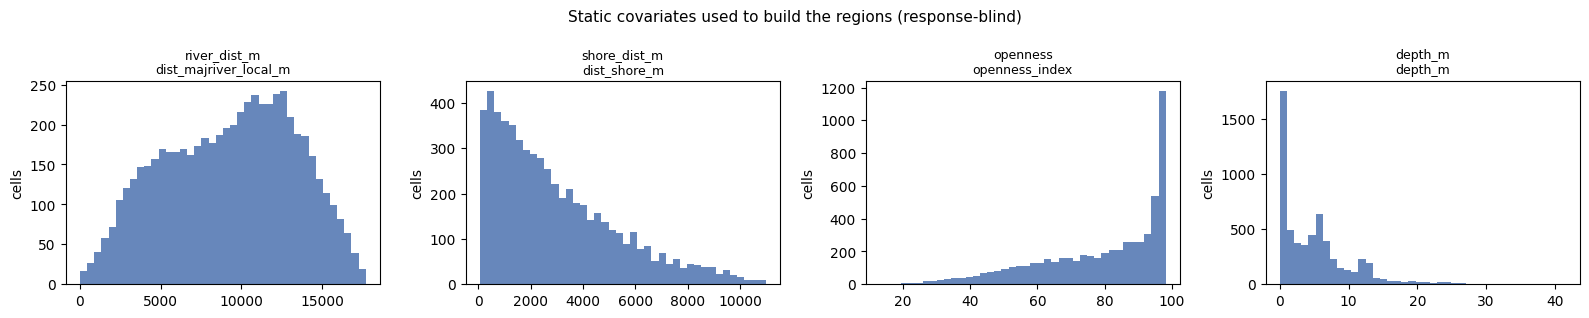

In [14]:
# =====================================================================
# 7b. Threshold provenance: what the repository already justifies
# =====================================================================
# Searched for existing, justified thresholds before inventing any. What exists,
# and what does not, is printed rather than asserted in prose.
REPO_THRESHOLD_SEARCH = pd.DataFrame([
    {"quantity": "what counts as a MAJOR river",
     "repository_precedent": "EE_RIVER_MAJOR_MAX_ORD = 7 (HydroSHEDS RIV_ORD; lower = larger river)",
     "found": True,
     "used_here": (
         "SUPERSEDED for this AOI. RIV_ORD <= 7 places every eligible Winam "
         "Gulf cell within 3,746 m of a 'major river', so dist_majriver_m spans "
         "a factor of ~50 and cannot separate a river-influenced bay from open "
         "water. §7a-ii instead measures dist_majriver_local_m against a mapped "
         "river network (KEN_Rivers, ILRI/OCHA Kenya, 1:250,000), selecting "
         f"named watercourses with a mapped course >= "
         f"{RIVER_MAJOR_MIN_LENGTH_KM:g} km that come within "
         f"{RIVER_MAJOR_MAX_GULF_DIST_KM:g} km of the analysed water body. The "
         "panel column remains the documented fallback")},
    {"quantity": "river-influence distance",
     "repository_precedent": "openness_index is built on a 5 km circular kernel "
                             "(ee.Kernel.circle(5000, 'meters')) - the project's "
                             "established local-influence length scale",
     "found": True,
     "used_here": ("REGION_THRESHOLDS['river_dist_m'] = 5000 m, reusing that "
                   "scale — but §7c checks it against this AOI's own "
                   "distribution before it is allowed to define a class")},
    {"quantity": "littoral / shoreline distance",
     "repository_precedent": "EE_CATCHMENT_BUFFER_M = 2000 m, the local "
                             "catchment-influence buffer used for the land-cover, "
                             "population and built-up layers",
     "found": True,
     "used_here": "REGION_THRESHOLDS['shore_dist_m'] = 2000 m, reusing that buffer"},
    {"quantity": "shelter / openness cut",
     "repository_precedent": "none - openness_index exists as a covariate but no "
                             "sheltered/exposed threshold is defined anywhere",
     "found": False,
     "used_here": "OPERATIONAL DEFINITION: the response-blind median of "
                  "openness_index among littoral cells"},
    {"quantity": "depth cut for open water",
     "repository_precedent": "none (MIN_WATER_FRACTION = 0.5 is a water MASK, not a "
                             "depth class)",
     "found": False,
     "used_here": "left None; depth enters only through the merge-similarity space"},
    {"quantity": "water/habitat mask",
     "repository_precedent": "WATER_MASK_SOURCE / MIN_WATER_FRACTION = 0.5",
     "found": True,
     "used_here": "inherited: the panel is already masked, and the eligible-area "
                  "weight reuses the same water fraction"},
])
display(REPO_THRESHOLD_SEARCH)
register("threshold_repository_search", REPO_THRESHOLD_SEARCH, "provenance")

# --- distributions of the covariates the thresholds act on -------------------
_dist_rows = []
for _role, _col in REGION_COVARIATES.items():
    if not _col:
        continue
    _s = _fmt_stats(CELL_STATIC[_col])
    _s.update({"role": _role, "column": _col})
    _dist_rows.append(_s)
STATIC_DISTRIBUTIONS = pd.DataFrame(_dist_rows)
STATIC_DISTRIBUTIONS = STATIC_DISTRIBUTIONS[
    ["role", "column", "n", "min", "p05", "p25", "median", "p75", "p95", "max",
     "mean", "sd"]]
print("Distributions of the static covariates the thresholds act on:")
display(STATIC_DISTRIBUTIONS)
register("static_covariate_distributions", STATIC_DISTRIBUTIONS, "diagnostic")

fig, axes = plt.subplots(1, max(len(_dist_rows), 1),
                         figsize=(4.0 * max(len(_dist_rows), 1), 3.2))
axes = np.atleast_1d(axes)
for ax, row in zip(axes, _dist_rows):
    v = pd.to_numeric(CELL_STATIC[row["column"]], errors="coerce").dropna()
    ax.hist(v, bins=40, color="#4C72B0", alpha=0.85)
    ax.set_title(f"{row['role']}\n{row['column']}", fontsize=9)
    ax.set_ylabel("cells")
fig.suptitle("Static covariates used to build the regions (response-blind)",
             fontsize=11)
fig.tight_layout()
save_fig(fig, "static_covariate_distributions")
plt.show()


In [15]:
# =====================================================================
# 7c. Resolve the thresholds (and say what kind of number each one is)
# =====================================================================


def threshold_capture_share(values, role, thr):
    """Share of eligible cells a candidate cut would place INSIDE its class.

    The comparison mirrors `assign_ecological_class` exactly — `<=` for the
    distance and depth rules, `<` for openness — so this is the share the class
    rule will actually produce, not an approximation of it. Response-blind by
    construction: one static covariate and one number.
    """
    x = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if not len(x) or thr is None or not np.isfinite(float(thr)):
        return np.nan
    inside = x < float(thr) if role == "openness" else x <= float(thr)
    return float(np.mean(inside))


def resolve_thresholds(cells, covariates, configured, openness_quantile,
                       fallback_quantiles=None, band=None, verbose=True):
    """Fill in any unset threshold response-blind, and record its provenance.

    Also CHECKS every configured threshold against this AOI's own covariate
    distribution. A cut that places nearly all or nearly none of the eligible
    cells inside its class does not partition the AOI: it silently collapses the
    class hierarchy. Such a cut is replaced by the pre-declared response-blind
    quantile for that role and the substitution is recorded, so the write-up can
    state exactly which cut was inherited, which was replaced, and why.
    """
    fallback_quantiles = dict(fallback_quantiles or {})
    # The explicit positional argument is authoritative for openness, so §19 can
    # vary it without having to rebuild the whole fallback table.
    if openness_quantile is not None:
        fallback_quantiles["openness"] = openness_quantile
    lo_share, hi_share = band or (0.0, 1.0)
    resolved = dict(configured)
    rows = []

    used_cols = [c for c in covariates.values() if c]
    assert_response_blind(used_cols, "resolve_thresholds")

    def _row(role, value, kind, basis, **extra):
        r = {"threshold": role,
             "value": None if value is None else float(value),
             "kind": kind, "basis": basis, "response_blind": True,
             "configured_value": None, "captured_share": np.nan,
             "fallback_quantile": np.nan, "discriminates": True}
        r.update(extra)
        rows.append(r)

    def _quantile_for(role, col, q):
        """The response-blind quantile for a role, plus the scope it was taken over."""
        base, scope = cells, "all eligible cells"
        if role == "openness":
            sho_col = covariates.get("shore_dist_m")
            t_sho = resolved.get("shore_dist_m")
            if sho_col and t_sho is not None:
                m = pd.to_numeric(cells[sho_col], errors="coerce") <= float(t_sho)
                if int(m.sum()) >= 20:
                    base, scope = cells[m], (f"littoral cells ({sho_col} <= "
                                             f"{float(t_sho):.0f} m)")
        return float(pd.to_numeric(base[col], errors="coerce")
                     .quantile(float(q))), scope

    for role in ["river_dist_m", "shore_dist_m", "openness", "depth_m"]:
        col = covariates.get(role)
        val = resolved.get(role)
        q = fallback_quantiles.get(role)

        if col is None:
            resolved[role] = None
            _row(role, None, "unavailable", "no covariate column in the panel")
            continue

        if val is not None:
            share = threshold_capture_share(cells[col], role, val)
            if not np.isfinite(share) or lo_share <= share <= hi_share:
                _row(role, val, "configured (repository precedent)",
                     f"see §7b REPO_THRESHOLD_SEARCH; this cut places "
                     f"{share:.1%} of eligible cells inside the class, inside "
                     f"the {lo_share:.0%}-{hi_share:.0%} discrimination band",
                     captured_share=share)
                continue
            # The cut does not partition THIS AOI.
            if q is None:
                _row(role, val, "configured but NON-DISCRIMINATING",
                     f"this cut places {share:.1%} of eligible cells inside the "
                     f"class, outside the {lo_share:.0%}-{hi_share:.0%} band, and "
                     "no fallback quantile is declared for this role; the class "
                     "hierarchy below it cannot fire",
                     captured_share=share, discriminates=False)
                continue
            newv, scope = _quantile_for(role, col, q)
            new_share = threshold_capture_share(cells[col], role, newv)
            resolved[role] = newv
            _row(role, newv,
                 "REPLACED (configured cut does not partition this AOI)",
                 f"configured {float(val):.4g} placed {share:.1%} of eligible "
                 f"cells inside the class, outside the {lo_share:.0%}-"
                 f"{hi_share:.0%} band, so the class hierarchy below it could "
                 f"never fire; replaced by the PRE-DECLARED response-blind "
                 f"quantile {float(q):g} of {col} over {scope} "
                 f"(= {newv:.4g}, {new_share:.1%} inside)",
                 configured_value=float(val), captured_share=new_share,
                 fallback_quantile=float(q), discriminates=True)
            continue

        if q is not None:
            newv, scope = _quantile_for(role, col, q)
            resolved[role] = newv
            _row(role, newv,
                 "OPERATIONAL DEFINITION (response-blind quantile)",
                 f"quantile {float(q):g} of {col} over {scope}; no repository "
                 f"precedent exists",
                 captured_share=threshold_capture_share(cells[col], role, newv),
                 fallback_quantile=float(q))
        else:
            _row(role, None, "not applied",
                 "left unset; the class collapses into its parent rather than "
                 "being invented")

    table = pd.DataFrame(rows)
    if verbose:
        display(table)
        rep = table[table["kind"].str.startswith("REPLACED")]
        if len(rep):
            print("*** THRESHOLD REPLACED — a configured cut did not partition "
                  "this AOI: ***")
            for r in rep.itertuples():
                print(f"  {r.threshold}: {r.configured_value:.4g} -> {r.value:.4g} "
                      f"(now {r.captured_share:.1%} of cells inside the class)")
                print(f"    {r.basis}")
            print("  The replacement is a PRE-DECLARED quantile "
                  "(THRESHOLD_FALLBACK_QUANTILES in §3c), fixed before any "
                  "threshold was resolved and never chosen by looking at a "
                  "result. §19 varies it as a sensitivity check.")
        nd = table[~table["discriminates"].astype(bool)]
        if len(nd):
            print("*** NON-DISCRIMINATING THRESHOLD LEFT IN PLACE: "
                  f"{nd['threshold'].tolist()} — the classes below it cannot "
                  "fire, and §8a will stop the run if the regionalisation "
                  "collapses. ***")
        op = table[table["kind"].str.startswith("OPERATIONAL")]
        if len(op):
            print("OPERATIONAL DEFINITIONS in force (no repository precedent; "
                  "sensitivity variants in §19):")
            for r in op.itertuples():
                print(f"  {r.threshold} = {r.value:.4g}  -- {r.basis}")
    return resolved, table


THRESHOLDS, THRESHOLD_PROVENANCE = resolve_thresholds(
    CELL_STATIC, REGION_COVARIATES, REGION_THRESHOLDS, OPENNESS_FALLBACK_QUANTILE,
    fallback_quantiles=THRESHOLD_FALLBACK_QUANTILES,
    band=THRESHOLD_DISCRIMINATION_BAND)
register("threshold_provenance", THRESHOLD_PROVENANCE, "provenance")
print()
print("None of these thresholds was chosen by looking at WH cover, WH prevalence, "
      "residuals or model performance, and none may be.")


,threshold,value,kind,basis,response_blind,configured_value,captured_share,fallback_quantile,discriminates
0,river_dist_m,5000.000000,configured (repository precedent),see §7b REPO_THRESHOLD_SEARCH; this cut places...,True,None,0.181493,NaN,True
1,shore_dist_m,2000.000000,configured (repository precedent),see §7b REPO_THRESHOLD_SEARCH; this cut places...,True,None,0.434428,NaN,True
2,openness,63.811215,OPERATIONAL DEFINITION (response-blind quantile),quantile 0.5 of openness_index over littoral c...,True,None,0.226909,0.5,True
3,depth_m,NaN,not applied,left unset; the class collapses into its paren...,True,None,NaN,NaN,True


OPERATIONAL DEFINITIONS in force (no repository precedent; sensitivity variants in §19):
  openness = 63.81  -- quantile 0.5 of openness_index over littoral cells (dist_shore_m <= 2000 m); no repository precedent exists

None of these thresholds was chosen by looking at WH cover, WH prevalence, residuals or model performance, and none may be.


## 8. Build the regions

Class → contiguous components → merge the under-sized → name and number. Nothing
in this section reads the response.

The audit that follows answers the three questions a reader will actually ask:
**how many regions**, **how big are they**, and **what was merged into what**.


In [16]:
# =====================================================================
# 8a. Regionalise
# =====================================================================
_SIM_COLS = [c for c in [REGION_COVARIATES.get("river_dist_m"),
                         REGION_COVARIATES.get("shore_dist_m"),
                         REGION_COVARIATES.get("openness"),
                         REGION_COVARIATES.get("depth_m")] if c]

ASSIGNMENTS, REGIONS, MERGE_LOG, CLASS_AUDIT = build_regions(
    CELL_STATIC, REGION_COVARIATES, THRESHOLDS,
    cell_size_m=EXPECTED_CELL_SIZE_M, contiguity=REGION_CONTIGUITY,
    min_cells=MIN_REGION_CELLS, min_area_ha=MIN_REGION_ELIGIBLE_AREA_HA,
    sim_cols=_SIM_COLS, area_col="eligible_area_ha")

print(f"{len(REGIONS)} region(s) from {len(ASSIGNMENTS):,} eligible cells "
      f"({ASSIGNMENTS['eligible_area_ha'].sum():,.0f} ha).")
display(REGIONS)
print("\nEcological class before and after merging (a merged unit takes the class "
      "of its majority area):")
display(CLASS_AUDIT)
if len(MERGE_LOG):
    print("\nMerge / drop log:")
    display(MERGE_LOG)
else:
    print("\nNo component needed merging.")

if "action" in MERGE_LOG.columns and (MERGE_LOG["action"] == "merge_incomplete").any():
    _inc = MERGE_LOG[MERGE_LOG["action"] == "merge_incomplete"].iloc[0]
    raise RuntimeError(
        "REGIONALISATION DID NOT CONVERGE: " + str(_inc["reason"]) + ".\n"
        "  Merging disposes of one component per iteration, so a partition that "
        "shatters into many small components needs a proportionally larger "
        "budget. The units left behind are single cells and slivers, not "
        "regions, and §9's size gates would drop them along with their area.\n"
        "  Raise max_iter in merge_small_components, or coarsen the partition "
        "(a larger MIN_REGION_CELLS, or fewer classes).")

CLASS_SHARES = (ASSIGNMENTS.groupby("region_type")
                .agg(n_cells=("grid_id", "size"),
                     eligible_area_ha=("eligible_area_ha", "sum"))
                .reset_index())
CLASS_SHARES["cell_share"] = CLASS_SHARES["n_cells"] / max(len(ASSIGNMENTS), 1)
CLASS_SHARES["area_share"] = (CLASS_SHARES["eligible_area_ha"]
                              / max(CLASS_SHARES["eligible_area_ha"].sum(), 1e-9))
CLASS_SHARES = CLASS_SHARES.sort_values("cell_share", ascending=False)
print("\nShare of the eligible cell set held by each ecological class "
      "(a class holding ~everything means its rule did not partition the AOI):")
display(CLASS_SHARES)
register("region_class_shares", CLASS_SHARES, "regionalisation")

if len(REGIONS) < REGION_COUNT_HARD_MIN:
    _dom = CLASS_SHARES.iloc[0]
    _msg = (
        f"REGIONALISATION COLLAPSED: {len(REGIONS)} region(s), below "
        f"REGION_COUNT_HARD_MIN={REGION_COUNT_HARD_MIN}.\n"
        f"  '{_dom['region_type']}' holds {_dom['cell_share']:.1%} of eligible "
        f"cells and {_dom['area_share']:.1%} of eligible area.\n"
        "  A single region is not a regional design. With R = 1:\n"
        "    - there is no between-region variation at all, so the regional "
        "design cannot answer the question it exists to ask;\n"
        "    - there is no cross-region variation for the month-clustered "
        "covariance to measure, so every cluster holds exactly one "
        "observation and the standard errors lose the very correction they "
        "exist to make;\n"
        "    - §10's between-region variance shares are 0 by ARITHMETIC, not by "
        "measurement, and would read as 'no driver varies regionally' when "
        "nothing was tested.\n"
        "  WHAT TO CHANGE: look at the §7c threshold provenance table above. It "
        "prints, for every configured cut, the share of cells its class rule "
        "captures. The cut that captured the AOI is the one to change — either "
        "adjust REGION_THRESHOLDS, or set it to None so the pre-declared "
        "THRESHOLD_FALLBACK_QUANTILES value resolves it from this AOI's own "
        "distribution.\n"
        "  This stop is deliberate: continuing produces tables that look like "
        "results and are not. Set ALLOW_DEGENERATE_REGIONALISATION = True in §3c "
        "only to inspect a collapsed run.")
    if ALLOW_DEGENERATE_REGIONALISATION:
        print(f"\n*** {_msg}\n*** PROCEEDING ANYWAY because "
              "ALLOW_DEGENERATE_REGIONALISATION = True. Nothing below this point "
              "is reportable. ***")
    else:
        raise RuntimeError(_msg)

_lo, _hi = REGION_COUNT_TARGET
if len(REGIONS) < _lo:
    print(f"\n*** {len(REGIONS)} regions is below the {_lo}-{_hi} target band. "
          "Consequence for hierarchical estimation: the between-region variances "
          "are described by very few groups, so the spread of the region "
          "intercepts is a statement about those few regions and nothing wider. "
          "§12 therefore drops random slopes below "
          f"RANDOM_SLOPE_MIN_REGIONS={RANDOM_SLOPE_MIN_REGIONS} regions, and §16 "
          "reports the spread of the region intercepts descriptively rather "
          "than as a variance component. ***")
elif len(REGIONS) > _hi:
    print(f"\nNote: {len(REGIONS)} regions exceeds the {_lo}-{_hi} target band. "
          "More regions means shorter, noisier individual series; the minimum-size "
          "requirements in §3c are the lever, and §19 varies them.")
else:
    print(f"\n{len(REGIONS)} regions is inside the {_lo}-{_hi} target band.")

register("region_cell_assignments", ASSIGNMENTS, "regionalisation")
register("region_definitions", REGIONS, "regionalisation")
register("region_merge_log", MERGE_LOG, "regionalisation")
register("region_class_audit", CLASS_AUDIT, "regionalisation")


17 region(s) from 5,879 eligible cells (144,935 ha).


,region_id,region_name,region_type,n_cells,eligible_area_ha,x_km,y_km,median_dist_majriver_local_m,median_dist_shore_m,median_openness_index,median_depth_m
0,R01,River-influenced bay (E),river_influenced_bay,792,19402.159686,693.946338,9967.881313,3282.755346,1699.474135,64.561255,0.325655
1,R02,River-influenced bay (SW),river_influenced_bay,168,3998.851845,646.127976,9949.577381,4151.564146,842.403696,62.442682,2.005584
2,R03,River-influenced bay (N),river_influenced_bay,148,3630.670821,661.895270,9978.506757,4347.232949,1034.179182,64.388058,0.059350
3,R04,River-influenced bay (W),river_influenced_bay,76,1856.690924,637.657895,9971.677632,4826.509322,840.527176,53.645203,1.305176
4,R05,Sheltered littoral (S),sheltered_littoral,190,4540.034579,662.468421,9946.336842,11133.470836,687.748269,48.620410,0.012881
5,R06,Sheltered littoral (NE),sheltered_littoral,180,4318.698989,689.602778,9986.052778,12335.408423,911.938689,53.490120,1.335219
6,R07,Sheltered littoral (NW),sheltered_littoral,84,2022.491194,652.625000,9976.857143,6729.419724,816.376440,45.107661,0.012864
7,R08,Sheltered littoral (N),sheltered_littoral,81,1856.625399,673.725309,9981.787037,5911.212644,486.690862,53.930647,0.027989
8,R09,Sheltered littoral (W),sheltered_littoral,59,1418.071169,651.292373,9962.368644,11075.287666,501.630031,56.119464,1.557551
9,R10,Sheltered littoral (central),sheltered_littoral,48,1133.463078,669.312500,9963.312500,10214.903247,536.016394,59.869035,0.791613



Ecological class before and after merging (a merged unit takes the class of its majority area):


,region_type_raw,region_type,n_cells,eligible_area_ha
0,exposed_littoral,exposed_littoral,969,23890.438884
1,exposed_littoral,river_influenced_bay,49,1216.363992
2,exposed_littoral,sheltered_littoral,43,1067.250000
3,open_gulf,open_gulf,2972,74300.000000
4,river_influenced_bay,river_influenced_bay,1033,25229.954974
5,river_influenced_bay,sheltered_littoral,34,759.345060
6,sheltered_littoral,exposed_littoral,112,2567.232452
7,sheltered_littoral,river_influenced_bay,102,2442.054310
8,sheltered_littoral,sheltered_littoral,565,13462.789348



Merge / drop log:


,component,action,n_cells,area_ha,merged_into,covariate_distance,reason
0,25,merged,1,19.000000,18,1.877298,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...
1,7,merged,2,42.096837,10,1.470715,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...
2,35,merged,2,50.000000,28,0.528812,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...
3,36,merged,2,50.000000,28,0.536004,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...
4,30,merged,3,61.678143,29,1.157455,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...
5,32,merged,5,125.000000,31,1.452627,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...
6,14,merged,8,177.562500,15,1.123188,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...
7,22,merged,9,203.852268,20,1.070078,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...
8,8,merged,11,240.326251,1,2.128812,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...
9,3,merged,14,350.000000,4,1.718008,below MIN_REGION_CELLS=40 / MIN_REGION_ELIGIBL...



Share of the eligible cell set held by each ecological class (a class holding ~everything means its rule did not partition the AOI):


,region_type,n_cells,eligible_area_ha,cell_share,area_share
1,open_gulf,2972,74300.000000,0.505528,0.512642
2,river_influenced_bay,1184,28888.373276,0.201395,0.199319
0,exposed_littoral,1081,26457.671336,0.183875,0.182548
3,sheltered_littoral,642,15289.384409,0.109202,0.105491



Note: 17 regions exceeds the 6-12 target band. More regions means shorter, noisier individual series; the minimum-size requirements in §3c are the lever, and §19 varies them.


,region_type_raw,region_type,n_cells,eligible_area_ha
0,exposed_littoral,exposed_littoral,969,23890.438884
1,exposed_littoral,river_influenced_bay,49,1216.363992
2,exposed_littoral,sheltered_littoral,43,1067.250000
3,open_gulf,open_gulf,2972,74300.000000
4,river_influenced_bay,river_influenced_bay,1033,25229.954974
5,river_influenced_bay,sheltered_littoral,34,759.345060
6,sheltered_littoral,exposed_littoral,112,2567.232452
7,sheltered_littoral,river_influenced_bay,102,2442.054310
8,sheltered_littoral,sheltered_littoral,565,13462.789348


Shoreline drawn as the outline of the analysed cell mask (geopandas=True, polygon=not found).


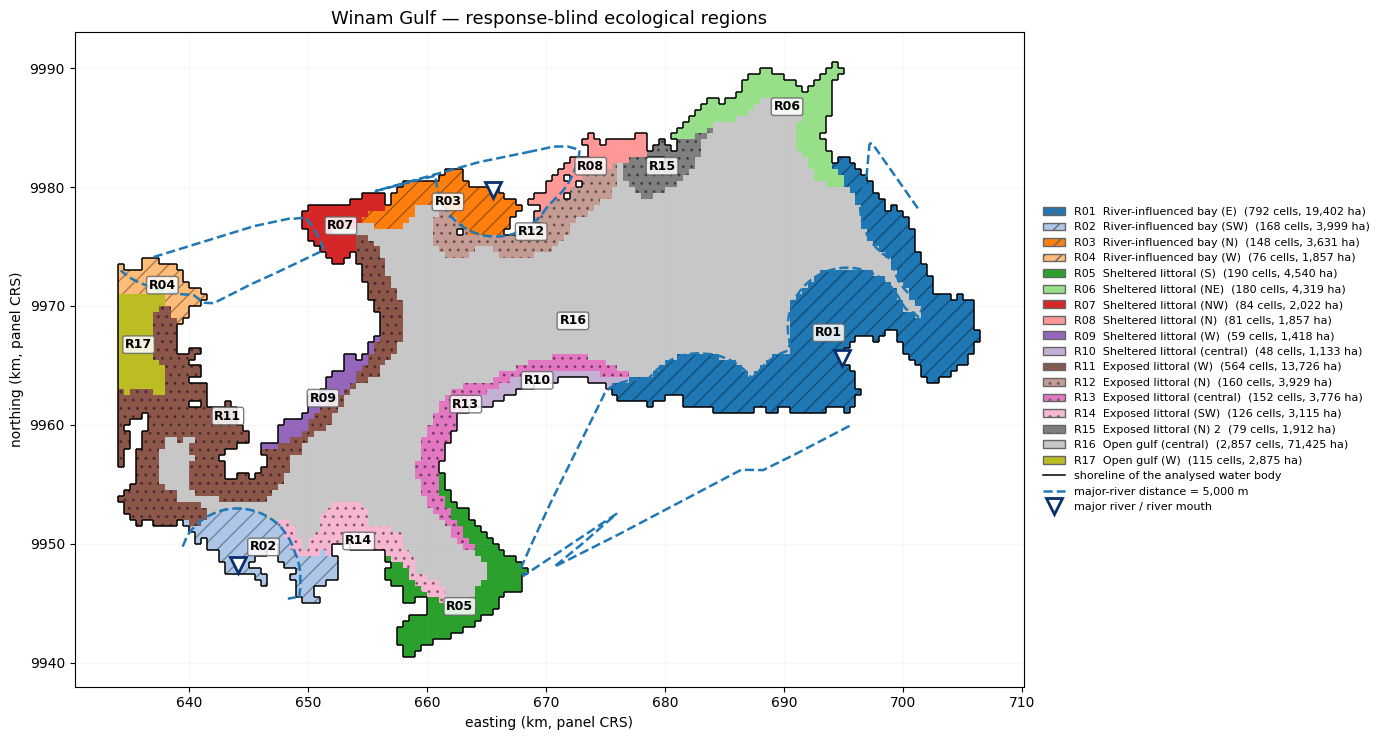

In [17]:
# =====================================================================
# 8b. The map
# =====================================================================


def mask_outline_segments(cells, cell_size_m):
    """Exact outline of the analysed water body: every cell edge with no neighbour.

    Dependency-free and honest - it is the boundary of the cells actually in the
    analysis, not a shoreline drawn from somewhere else.
    """
    cs_km = float(cell_size_m) / 1000.0
    ix, iy = grid_cell_indices(cells, cell_size_m)
    have = set(zip(ix.tolist(), iy.tolist()))
    segs = []
    for a, b, x, y in zip(ix, iy, cells["x_km"].to_numpy(), cells["y_km"].to_numpy()):
        x0, y0 = x - cs_km / 2, y - cs_km / 2
        x1, y1 = x + cs_km / 2, y + cs_km / 2
        if (a - 1, b) not in have:
            segs.append([(x0, y0), (x0, y1)])
        if (a + 1, b) not in have:
            segs.append([(x1, y0), (x1, y1)])
        if (a, b - 1) not in have:
            segs.append([(x0, y0), (x1, y0)])
        if (a, b + 1) not in have:
            segs.append([(x0, y1), (x1, y1)])
    return segs


def plot_regions(assignments, regions, thresholds, covariates, cell_size_m,
                 title="Winam Gulf — response-blind ecological regions"):
    from matplotlib.collections import LineCollection
    cs_km = float(cell_size_m) / 1000.0
    ids = regions["region_id"].tolist()
    cmap = plt.get_cmap("tab20")
    colour = {rid: cmap(i % 20) for i, rid in enumerate(ids)}
    hatch = {"river_influenced_bay": "//", "sheltered_littoral": "",
             "exposed_littoral": "..", "open_gulf": ""}
    type_of = dict(zip(regions["region_id"], regions["region_type"]))

    fig, ax = plt.subplots(figsize=(13, 7.5))
    patches, colours = [], []
    for r in assignments.itertuples():
        patches.append(Rectangle((r.x_km - cs_km / 2, r.y_km - cs_km / 2),
                                 cs_km, cs_km))
        colours.append(colour.get(r.region_id, (0.8, 0.8, 0.8, 1.0)))
    ax.add_collection(PatchCollection(patches, facecolors=colours,
                                      edgecolors="none", linewidths=0))
    # Hatch the two classes whose definition is a rule rather than a location.
    for rid, hh in [(k, hatch.get(v, "")) for k, v in type_of.items()]:
        if not hh:
            continue
        sub = assignments[assignments["region_id"] == rid]
        ax.add_collection(PatchCollection(
            [Rectangle((r.x_km - cs_km / 2, r.y_km - cs_km / 2), cs_km, cs_km)
             for r in sub.itertuples()],
            facecolors="none", edgecolors=(0, 0, 0, 0.35), hatch=hh, linewidths=0))

    ax.add_collection(LineCollection(
        mask_outline_segments(assignments, cell_size_m),
        colors="black", linewidths=1.1, zorder=4,
        label="shoreline of the analysed water body"))

    riv_col = covariates.get("river_dist_m")
    t_riv = thresholds.get("river_dist_m")
    if riv_col and riv_col in assignments.columns and t_riv is not None:
        try:
            ax.tricontour(assignments["x_km"].to_numpy(),
                          assignments["y_km"].to_numpy(),
                          pd.to_numeric(assignments[riv_col], errors="coerce")
                          .fillna(1e9).to_numpy(),
                          levels=[float(t_riv)], colors="#1f78b4",
                          linewidths=1.8, linestyles="--", zorder=5)
        except Exception as exc:
            print(f"  river-distance contour skipped: {exc}")
        near = assignments.nsmallest(1, riv_col)
        _grp = assignments[pd.to_numeric(assignments[riv_col], errors="coerce")
                           <= float(t_riv) * 0.25]
        if len(_grp):
            for rid, sub in _grp.groupby("region_id"):
                ax.plot(sub["x_km"].mean(), sub["y_km"].mean(), marker="v",
                        ms=12, mfc="white", mec="#08306b", mew=2.0, zorder=6)
        elif len(near):
            ax.plot(near["x_km"].iloc[0], near["y_km"].iloc[0], marker="v",
                    ms=12, mfc="white", mec="#08306b", mew=2.0, zorder=6)

    for r in regions.itertuples():
        # Anchor the label on a cell that really belongs to the region: a
        # horseshoe-shaped region's centroid can fall outside it entirely.
        sub = assignments[assignments["region_id"] == r.region_id]
        j = int(np.argmin(np.hypot(sub["x_km"].to_numpy() - r.x_km,
                                   sub["y_km"].to_numpy() - r.y_km)))
        lx = float(sub["x_km"].to_numpy()[j])
        ly = float(sub["y_km"].to_numpy()[j])
        ax.annotate(r.region_id, (lx, ly), ha="center", va="center",
                    fontsize=9, fontweight="bold", color="black", zorder=7,
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.4",
                              alpha=0.85))

    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=colour[r.region_id], edgecolor="0.4",
                     hatch=hatch.get(r.region_type, ""),
                     label=f"{r.region_id}  {r.region_name}  "
                           f"({r.n_cells:,} cells, {r.eligible_area_ha:,.0f} ha)")
               for r in regions.itertuples()]
    handles.append(Line2D([0], [0], color="black", lw=1.1,
                          label="shoreline of the analysed water body"))
    if riv_col and t_riv is not None:
        handles.append(Line2D([0], [0], color="#1f78b4", lw=1.8, ls="--",
                              label=f"major-river distance = {t_riv:,.0f} m"))
        handles.append(Line2D([0], [0], marker="v", lw=0, ms=11, mfc="white",
                              mec="#08306b", mew=2.0,
                              label="major river / river mouth"))
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5),
              fontsize=8, frameon=False)
    ax.set_aspect("equal")
    ax.autoscale_view()
    ax.set_xlabel("easting (km, panel CRS)")
    ax.set_ylabel("northing (km, panel CRS)")
    ax.set_title(title, fontsize=13)
    ax.grid(alpha=0.15, linewidth=0.4)
    fig.tight_layout()
    return fig, ax


REGION_MAP_FIG, _ax = plot_regions(
    ASSIGNMENTS, REGIONS, THRESHOLDS, REGION_COVARIATES, EXPECTED_CELL_SIZE_M,
    title=("Winam Gulf — response-blind ecological regions"
           + (" (SYNTHETIC)" if SOURCE["is_synthetic"] else "")))

# Real shoreline overlay, when geopandas and a polygon are both available.
_shore_path = next((p for p in SHORELINE_GEOJSON_CANDIDATES if Path(p).exists()), None)
if HAVE_GEOPANDAS and _shore_path is not None and not SOURCE["is_synthetic"]:
    try:
        _sh = gpd.read_file(_shore_path).to_crs(PANEL_CRS)
        for geom in _sh.geometry:
            for poly in (geom.geoms if geom.geom_type.startswith("Multi") else [geom]):
                xs, ys = poly.exterior.xy
                _ax.plot(np.asarray(xs) / 1000.0, np.asarray(ys) / 1000.0,
                         color="#444444", lw=0.8, alpha=0.8, zorder=3)
        print(f"Shoreline overlay: {_shore_path}")
    except Exception as exc:
        print(f"Shoreline overlay skipped ({exc}); the cell-mask outline is drawn "
              "instead.")
else:
    print("Shoreline drawn as the outline of the analysed cell mask "
          f"(geopandas={HAVE_GEOPANDAS}, polygon={'found' if _shore_path else 'not found'}).")

save_fig(REGION_MAP_FIG, "01_ecological_regions")
plt.show()


In [18]:
# =====================================================================
# 8c. Export the region geometries
# =====================================================================
REGION_GEOMETRY_PATH = None
REGION_GEOMETRIES = None
if HAVE_GEOPANDAS:
    _cs = float(EXPECTED_CELL_SIZE_M)
    _sq = [shapely_box(r.x_km * 1000 - _cs / 2, r.y_km * 1000 - _cs / 2,
                       r.x_km * 1000 + _cs / 2, r.y_km * 1000 + _cs / 2)
           for r in ASSIGNMENTS.itertuples()]
    _cells_gdf = gpd.GeoDataFrame(ASSIGNMENTS.copy(), geometry=_sq, crs=PANEL_CRS)
    REGION_GEOMETRIES = (_cells_gdf.dissolve(by="region_id",
                                             aggfunc={"eligible_area_ha": "sum"})
                         .reset_index()
                         .merge(REGIONS[["region_id", "region_name", "region_type",
                                         "n_cells"]], on="region_id", how="left"))
    print(f"Dissolved {len(ASSIGNMENTS):,} cells into {len(REGION_GEOMETRIES)} region "
          f"polygons in {PANEL_CRS}.")
    display(REGION_GEOMETRIES.drop(columns="geometry"))
else:
    print("geopandas unavailable: the GeoPackage is skipped. The cell assignment "
          "CSV (grid_id + x_km + y_km + region_id) carries the same information "
          "and can be re-dissolved anywhere.")


Dissolved 5,879 cells into 17 region polygons in EPSG:32736.


,region_id,eligible_area_ha,region_name,region_type,n_cells
0,R01,19402.159686,River-influenced bay (E),river_influenced_bay,792
1,R02,3998.851845,River-influenced bay (SW),river_influenced_bay,168
2,R03,3630.670821,River-influenced bay (N),river_influenced_bay,148
3,R04,1856.690924,River-influenced bay (W),river_influenced_bay,76
4,R05,4540.034579,Sheltered littoral (S),sheltered_littoral,190
5,R06,4318.698989,Sheltered littoral (NE),sheltered_littoral,180
6,R07,2022.491194,Sheltered littoral (NW),sheltered_littoral,84
7,R08,1856.625399,Sheltered littoral (N),sheltered_littoral,81
8,R09,1418.071169,Sheltered littoral (W),sheltered_littoral,59
9,R10,1133.463078,Sheltered littoral (central),sheltered_littoral,48


## 9. The region-month panel — **the inferential dataset**

$$\text{wh\_cover}_{r,t}=
\frac{\sum_{i \in C_r}\text{WH area}_{i,t}}
     {\sum_{i \in C_r}\text{valid classified area}_{i,t}}$$

with the **same** fixed membership $C_r$ in every month. Alongside the response,
each region-month carries the quantities a reader needs to judge whether it is a
real observation: WH area, valid classified area, how many of the region's cells
were eligible and how many were actually observed, both coverage fractions, the
regional WH occurrence rate, and the area-weighted environmental predictors.

**Two gates, both required.** A region-month becomes an observation only if it
clears `MIN_REGION_MONTH_CELL_COVERAGE` *and*
`MIN_REGION_MONTH_VALID_AREA_COVERAGE`. Failing either leaves the response
missing — it never leaves a partially-observed value in place.

**Composition drift is reported, not assumed away.** Membership is fixed, but
*which* member cells were cloud-free varies. §9c measures that drift for every
region and prints the worst offenders, because a region whose observed
composition swings month to month is measuring a moving target even with a fixed
$C_r$.


In [19]:
# =====================================================================
# 9a. Build the region-month panel
# =====================================================================


def regional_monthly_panel(panel, assignments, driver_cols, months_grid=None,
                           min_cell_coverage=0.70, min_area_coverage=0.70):
    """Collapse the cell-month panel to ONE row per region per calendar month.

    The response is the AREA-WEIGHTED regional cover; the drivers are weighted by
    the same classified area, so a driver and the response describe the same
    piece of lake in the same month.
    """
    wh_col, valid_col = _area_columns(panel)
    memb = assignments[["grid_id", "region_id", "eligible_area_ha"]]
    sub = panel.merge(memb, on="grid_id", how="inner").copy()
    sub["_w"] = pd.to_numeric(sub[valid_col], errors="coerce").fillna(0.0)

    elig = (memb.groupby("region_id")
            .agg(n_cells_eligible=("grid_id", "nunique"),
                 eligible_area_ha=("eligible_area_ha", "sum")).reset_index())

    agg = {"wh_area_ha": (wh_col, "sum"),
           "valid_area_ha": (valid_col, "sum"),
           "n_cells_observed": ("grid_id", "nunique")}
    if "wh_present" in sub.columns:
        agg["wh_occurrence"] = ("wh_present", "mean")
    out = sub.groupby(["region_id", "month"], as_index=False).agg(**agg)

    for col in driver_cols:
        if col not in sub.columns:
            continue
        vals = pd.to_numeric(sub[col], errors="coerce")
        w = sub["_w"].where(vals.notna(), 0.0)
        keys = [sub["region_id"], sub["month"]]
        num = (vals.fillna(0.0) * w).groupby(keys).sum()
        den = w.groupby(keys).sum().replace(0, np.nan)
        out = out.merge((num / den).rename(col).reset_index()
                        .rename(columns={"level_0": "region_id", "level_1": "month"}),
                        on=["region_id", "month"], how="left")

    out = out.merge(elig, on="region_id", how="left")
    out["cell_coverage_fraction"] = (out["n_cells_observed"]
                                     / out["n_cells_eligible"].replace(0, np.nan))
    best = out.groupby("region_id")["valid_area_ha"].transform("max")
    out["valid_area_coverage_fraction"] = out["valid_area_ha"] / best.replace(0, np.nan)
    out["wh_cover"] = out["wh_area_ha"] / out["valid_area_ha"].replace(0, np.nan)

    ok = ((out["cell_coverage_fraction"] >= float(min_cell_coverage))
          & (out["valid_area_coverage_fraction"] >= float(min_area_coverage)))
    out["region_month_usable"] = ok
    out["exclusion_reason"] = np.where(
        ok, "",
        np.where(out["cell_coverage_fraction"] < float(min_cell_coverage),
                 f"cell coverage < {float(min_cell_coverage):g}",
                 f"valid-area coverage < {float(min_area_coverage):g}"))
    # A failing region-month is MISSING, never a partially-observed value.
    out.loc[~ok, ["wh_cover", "wh_area_ha", "wh_occurrence"]] = np.nan
    return out.sort_values(["region_id", "month"]).reset_index(drop=True)


# Candidate time-varying columns: everything numeric that is not a key, a
# response, a static covariate or a known degenerate.
_reserved = {"month", "grid_id", "year", "month_num", "time_index",
             "n_cells", "valid_area_ha", "valid_area_m2", "wh_area_ha",
             "wh_area_m2", "wh_area_ha_hard", "wh_pixels", "valid_pixels",
             "valid_fraction", "coverage_fraction", "eligible_area_ha",
             "n_cells_eligible", "n_cells_observed", "retained"}
_response_like = (lambda c: (c.startswith("wh_") or c.startswith("mean_cover")
                             or c.startswith("occurrence") or c.endswith("_neigh_lag1")))
CANDIDATE_DRIVER_COLS = [
    c for c in PANEL_FIXED.columns
    if c not in _reserved and not _response_like(c)
    and c not in KNOWN_STATIC_COLS and c not in REGIONAL_DEGENERATE_COLS
    and not str(c).endswith("_lag1")
    and pd.api.types.is_numeric_dtype(PANEL_FIXED[c])]

print(f"Candidate time-varying driver columns ({len(CANDIDATE_DRIVER_COLS)}):")
print("  " + ", ".join(CANDIDATE_DRIVER_COLS))
_static_dropped = [c for c in PANEL_FIXED.columns if c in KNOWN_STATIC_COLS]
_degen_dropped = [c for c in PANEL_FIXED.columns if c in REGIONAL_DEGENERATE_COLS]
print(f"\nDropped as STATIC within a fixed region (cannot explain temporal "
      f"variation; they act through the regionalisation and the regional "
      f"intercept instead): {_static_dropped or 'none'}")
for c in _degen_dropped:
    print(f"Dropped as DEGENERATE at regional scale: {c} "
          f"({REGIONAL_DEGENERATE_COLS[c]})")

REGION_MONTH_RAW = regional_monthly_panel(
    PANEL_FIXED, ASSIGNMENTS, CANDIDATE_DRIVER_COLS,
    min_cell_coverage=MIN_REGION_MONTH_CELL_COVERAGE,
    min_area_coverage=MIN_REGION_MONTH_VALID_AREA_COVERAGE)
print(f"\nRegion-months built: {len(REGION_MONTH_RAW):,} "
      f"({int(REGION_MONTH_RAW['region_month_usable'].sum()):,} usable, "
      f"{int((~REGION_MONTH_RAW['region_month_usable']).sum()):,} below a coverage "
      "gate and therefore MISSING).")


# ---------------------------------------------------------------------
# 9a-ii. Drivers from the COMPLETE environmental tables
# ---------------------------------------------------------------------
# The response is filtered by coverage; the environment is not. A month whose WH
# map failed the coverage filter contributes no panel row, so without this step
# its drivers would be missing too — and then every observed month whose LAG
# lands on it would be withheld from the likelihood. That is a large, avoidable
# loss, and the spatial workflow already exported the environmental tables for
# every month it queried.
#
# The two weightings differ and the difference is measured, not glossed: the
# panel-derived value is weighted by the classified area actually observed that
# month, while the complete-table value can only be weighted by each cell's
# STATIC eligible water area. The panel value always wins where it exists.


def regional_env_from_complete_tables(assignments, driver_cols,
                                      env_monthly=None, env_cellmonth=None):
    """Area-weighted regional driver values for EVERY calendar month."""
    frames = []
    memb = assignments[["grid_id", "region_id", "eligible_area_ha"]]
    if env_cellmonth is not None and len(env_cellmonth):
        cm = env_cellmonth.merge(memb, on="grid_id", how="inner")
        cols = [c for c in driver_cols if c in cm.columns]
        if cols:
            out = cm.groupby(["region_id", "month"], as_index=False).size()[
                ["region_id", "month"]]
            for c in cols:
                v = pd.to_numeric(cm[c], errors="coerce")
                w = cm["eligible_area_ha"].where(v.notna(), 0.0)
                keys = [cm["region_id"], cm["month"]]
                num = (v.fillna(0.0) * w).groupby(keys).sum()
                den = w.groupby(keys).sum().replace(0, np.nan)
                out = out.merge((num / den).rename(c).reset_index(),
                                on=["region_id", "month"], how="left")
            frames.append(out)
    if env_monthly is not None and len(env_monthly):
        cols = [c for c in driver_cols if c in env_monthly.columns]
        if cols:
            grid = pd.MultiIndex.from_product(
                [sorted(memb["region_id"].unique()),
                 pd.to_datetime(env_monthly["month"].unique())],
                names=["region_id", "month"]).to_frame(index=False)
            frames.append(grid.merge(env_monthly[["month"] + cols], on="month",
                                     how="left"))
    if not frames:
        return pd.DataFrame(columns=["region_id", "month"])
    base = frames[0]
    for extra in frames[1:]:
        new = [c for c in extra.columns if c not in base.columns]
        base = base.merge(extra[["region_id", "month"] + new],
                          on=["region_id", "month"], how="outer")
    return base


ENV_FILL_AUDIT = pd.DataFrame()
_env_reg = regional_env_from_complete_tables(
    ASSIGNMENTS, CANDIDATE_DRIVER_COLS,
    env_monthly=ENV_MONTHLY_COMPLETE, env_cellmonth=ENV_CELLMONTH_COMPLETE)
if len(_env_reg):
    _env_reg["month"] = to_month_start(_env_reg["month"])
    _fill_cols = [c for c in CANDIDATE_DRIVER_COLS if c in _env_reg.columns]
    _all = (REGION_MONTH_RAW.merge(
        _env_reg[["region_id", "month"] + _fill_cols], on=["region_id", "month"],
        how="outer", suffixes=("", "_envfill")))
    _rows = []
    for c in _fill_cols:
        ec = f"{c}_envfill"
        if ec not in _all.columns:
            continue
        both = _all[c].notna() & _all[ec].notna()
        _rows.append({
            "driver": c,
            "n_from_panel": int(_all[c].notna().sum()),
            "n_filled_from_complete_tables": int((_all[c].isna()
                                                  & _all[ec].notna()).sum()),
            "n_overlap": int(both.sum()),
            "overlap_pearson_r": (float(np.corrcoef(_all.loc[both, c],
                                                    _all.loc[both, ec])[0, 1])
                                  if int(both.sum()) > 3 else np.nan),
            "overlap_mean_abs_diff": (float((_all.loc[both, c]
                                             - _all.loc[both, ec]).abs().mean())
                                      if both.any() else np.nan),
            "note": "panel value (classified-area weighted) wins where it exists; "
                    "the fill is eligible-area weighted",
        })
        _all[c] = _all[c].where(_all[c].notna(), _all[ec])
        _all = _all.drop(columns=[ec])
    ENV_FILL_AUDIT = pd.DataFrame(_rows)
    # Rows that exist only in the environmental tables carry drivers but no
    # response: exactly what the state process needs, and never an observation.
    _all["region_month_usable"] = _all["region_month_usable"].fillna(False)
    _all["exclusion_reason"] = _all["exclusion_reason"].fillna(
        "no WH map for this month (below the gulf-wide coverage filter); the "
        "environmental drivers come from the complete monthly tables")
    REGION_MONTH_RAW = (_all.sort_values(["region_id", "month"])
                        .reset_index(drop=True))
    display(ENV_FILL_AUDIT)
    register("environmental_fill_audit", ENV_FILL_AUDIT, "provenance")
    print(f"Driver rows after using the complete environmental tables: "
          f"{len(REGION_MONTH_RAW):,} region-months "
          f"({int(REGION_MONTH_RAW['region_month_usable'].sum()):,} with a usable "
          "response).")
    print("Where the two weightings overlap, the correlation above says how "
          "comparable the fill is. A low correlation means the fill is a "
          "different measurement and should be treated as such.")
else:
    print("No complete environmental table was available, so drivers exist only "
          "in months that produced a WH map. Every observed month whose lag lands "
          "on an excluded month is therefore withheld from the likelihood; the "
          "count is in the §11b audit.")


Candidate time-varying driver columns (31):
  source_from_directory_scan, sensor_is_s1, air_temp_c, wind_speed_ms, wind_u_ms, wind_v_ms, wind_dir_to_deg, wind_axis_comp_ms, wind_cross_comp_ms, ghsl_built_m2, red_reflectance_s2, turb_ndti_s2, chl_mci_s3, chl_mph_s3, water_temp_c, rain_chirps_30d_mm, rain_chirps_90d_mm, rain_chirps_mm, rain_max_1d_mm, rain_spikes_20mm_cnt, rain_spikes_40mm_cnt, rain_wet_days, rain_sdii_mm, lake_level_m, wave_exposure_idx, nutrient_pulse_idx, month_sin, month_cos, wind_onshore_ms, wind_onshore_x_openness_index, wind_onshore_x_wave_exposure_idx

Dropped as STATIC within a fixed region (cannot explain temporal variation; they act through the regionalisation and the regional intercept instead): ['x_km', 'y_km', 'cell_area_m2', 'depth_m', 'bathy_water_fraction', 'dist_majriver_m', 'dist_river_m', 'dist_shore_m', 'openness_index', 'gsw_water_fraction', 'frac_cropland', 'frac_urban', 'frac_wetland', 'pop_count', 'shore_gx', 'shore_gy']
Dropped as DEGENERATE at 

,driver,n_from_panel,n_filled_from_complete_tables,n_overlap,overlap_pearson_r,overlap_mean_abs_diff,note
0,air_temp_c,1360,272,1360,0.938889,7.904069e-01,panel value (classified-area weighted) wins wh...
1,wind_speed_ms,1360,272,1360,0.612431,5.286110e-01,panel value (classified-area weighted) wins wh...
2,wind_u_ms,1360,272,1360,0.918989,1.978066e-01,panel value (classified-area weighted) wins wh...
3,wind_v_ms,1360,272,1360,0.900948,2.815173e-01,panel value (classified-area weighted) wins wh...
4,wind_dir_to_deg,1360,272,1360,0.842029,2.646361e+01,panel value (classified-area weighted) wins wh...
5,wind_axis_comp_ms,1360,272,1360,0.918989,1.978066e-01,panel value (classified-area weighted) wins wh...
6,wind_cross_comp_ms,1360,272,1360,0.900948,2.815173e-01,panel value (classified-area weighted) wins wh...
7,red_reflectance_s2,1360,266,1360,0.411099,2.322913e-02,panel value (classified-area weighted) wins wh...
8,turb_ndti_s2,1360,266,1360,0.411519,6.548672e-02,panel value (classified-area weighted) wins wh...
9,chl_mci_s3,1360,272,1360,1.000000,1.243450e-15,panel value (classified-area weighted) wins wh...


Driver rows after using the complete environmental tables: 1,632 region-months (1,347 with a usable response).
Where the two weightings overlap, the correlation above says how comparable the fill is. A low correlation means the fill is a different measurement and should be treated as such.


In [20]:
# =====================================================================
# 9b. Regions that do not meet the minimum requirements are dropped
# =====================================================================
_usable = REGION_MONTH_RAW[REGION_MONTH_RAW["region_month_usable"]]
_req = (_usable.groupby("region_id")
        .agg(n_months_usable=("month", "nunique"),
             median_cell_coverage=("cell_coverage_fraction", "median"),
             median_valid_area_coverage=("valid_area_coverage_fraction", "median"))
        .reset_index())
REGION_REQUIREMENTS = (REGIONS.merge(_req, on="region_id", how="left")
                       .fillna({"n_months_usable": 0, "median_cell_coverage": 0.0,
                                "median_valid_area_coverage": 0.0}))
REGION_REQUIREMENTS["meets_min_cells"] = (
    REGION_REQUIREMENTS["n_cells"] >= MIN_REGION_CELLS)
REGION_REQUIREMENTS["meets_min_area"] = (
    REGION_REQUIREMENTS["eligible_area_ha"] >= MIN_REGION_ELIGIBLE_AREA_HA)
REGION_REQUIREMENTS["meets_min_months"] = (
    REGION_REQUIREMENTS["n_months_usable"] >= MIN_REGION_MONTHS)
REGION_REQUIREMENTS["meets_min_coverage"] = (
    REGION_REQUIREMENTS["median_cell_coverage"] >= MIN_REGION_MEDIAN_COVERAGE)
REGION_REQUIREMENTS["usable"] = (
    REGION_REQUIREMENTS[["meets_min_cells", "meets_min_area",
                         "meets_min_months", "meets_min_coverage"]].all(axis=1))
REGION_REQUIREMENTS["drop_reason"] = [
    "" if r.usable else "; ".join(
        [n for n, ok in [(f"n_cells < {MIN_REGION_CELLS}", r.meets_min_cells),
                         (f"eligible area < {MIN_REGION_ELIGIBLE_AREA_HA:g} ha",
                          r.meets_min_area),
                         (f"usable months < {MIN_REGION_MONTHS}", r.meets_min_months),
                         (f"median coverage < {MIN_REGION_MEDIAN_COVERAGE:g}",
                          r.meets_min_coverage)] if not ok])
    for r in REGION_REQUIREMENTS.itertuples()]
display(REGION_REQUIREMENTS)
register("region_requirements", REGION_REQUIREMENTS, "regionalisation")

USABLE_REGION_IDS = REGION_REQUIREMENTS.loc[REGION_REQUIREMENTS["usable"],
                                            "region_id"].tolist()
_dropped = REGION_REQUIREMENTS.loc[~REGION_REQUIREMENTS["usable"]]
if len(_dropped):
    print("\nDropped regions (kept in the map and the assignment export, excluded "
          "from the model):")
    for r in _dropped.itertuples():
        print(f"  {r.region_id} {r.region_name}: {r.drop_reason}")
if not USABLE_REGION_IDS:
    raise RuntimeError("No region meets the minimum requirements in §3c. Relax "
                       "them deliberately, or accept that the record cannot "
                       "support a regional analysis.")
N_REGIONS = len(USABLE_REGION_IDS)
print(f"\n{N_REGIONS} usable region(s) enter the model.")
if N_REGIONS < REGION_COUNT_TARGET[0]:
    print(f"*** Fewer than {REGION_COUNT_TARGET[0]} usable regions. The "
          "hierarchical variances are then estimated from very few groups: "
          "the region intercepts are still estimated, but their spread "
          "describes THESE regions and is not an estimate of between-region "
          "heterogeneity in any wider population. §12 estimates them as fixed "
          "effects and §16b reports them descriptively. ***")
if N_REGIONS < 4:
    print(f"*** With {N_REGIONS} region(s) each calendar-month cluster holds at "
          f"most {N_REGIONS} observation(s). Clustering on month is what makes "
          "the effective sample size the number of months rather than the "
          "number of region-months, but with this few regions per month there "
          "is very little cross-region dependence for it to absorb, and §15b "
          "checks the cluster count directly. ***")


,region_id,region_name,region_type,n_cells,eligible_area_ha,x_km,y_km,median_dist_majriver_local_m,median_dist_shore_m,median_openness_index,median_depth_m,n_months_usable,median_cell_coverage,median_valid_area_coverage,meets_min_cells,meets_min_area,meets_min_months,meets_min_coverage,usable,drop_reason
0,R01,River-influenced bay (E),river_influenced_bay,792,19402.159686,693.946338,9967.881313,3282.755346,1699.474135,64.561255,0.325655,79,1.000000,0.961446,True,True,True,True,True,
1,R02,River-influenced bay (SW),river_influenced_bay,168,3998.851845,646.127976,9949.577381,4151.564146,842.403696,62.442682,2.005584,78,1.000000,0.944735,True,True,True,True,True,
2,R03,River-influenced bay (N),river_influenced_bay,148,3630.670821,661.895270,9978.506757,4347.232949,1034.179182,64.388058,0.059350,79,1.000000,0.967964,True,True,True,True,True,
3,R04,River-influenced bay (W),river_influenced_bay,76,1856.690924,637.657895,9971.677632,4826.509322,840.527176,53.645203,1.305176,78,1.000000,0.954387,True,True,True,True,True,
4,R05,Sheltered littoral (S),sheltered_littoral,190,4540.034579,662.468421,9946.336842,11133.470836,687.748269,48.620410,0.012881,80,1.000000,0.951556,True,True,True,True,True,
5,R06,Sheltered littoral (NE),sheltered_littoral,180,4318.698989,689.602778,9986.052778,12335.408423,911.938689,53.490120,1.335219,78,1.000000,0.970088,True,True,True,True,True,
6,R07,Sheltered littoral (NW),sheltered_littoral,84,2022.491194,652.625000,9976.857143,6729.419724,816.376440,45.107661,0.012864,80,1.000000,0.955023,True,True,True,True,True,
7,R08,Sheltered littoral (N),sheltered_littoral,81,1856.625399,673.725309,9981.787037,5911.212644,486.690862,53.930647,0.027989,80,1.000000,0.987051,True,True,True,True,True,
8,R09,Sheltered littoral (W),sheltered_littoral,59,1418.071169,651.292373,9962.368644,11075.287666,501.630031,56.119464,1.557551,80,1.000000,0.959595,True,True,True,True,True,
9,R10,Sheltered littoral (central),sheltered_littoral,48,1133.463078,669.312500,9963.312500,10214.903247,536.016394,59.869035,0.791613,80,1.000000,0.969766,True,True,True,True,True,



17 usable region(s) enter the model.


In [21]:
# =====================================================================
# 9c. Does a region's observed composition drift through time?
# =====================================================================
# Membership is FIXED. What is not fixed is which member cells were cloud-free.
# A region whose observed composition swings month to month is measuring a
# moving target even with a fixed C_r, so it is measured and reported.
_memb = ASSIGNMENTS[["grid_id", "region_id", "eligible_area_ha"]]
_obs = (PANEL_FIXED[["grid_id", "month"]].merge(_memb, on="grid_id", how="inner"))
_usable_keys = set(map(tuple, _usable[["region_id", "month"]].to_numpy()))
_obs = _obs[[ (r, m) in _usable_keys for r, m in
              zip(_obs["region_id"], _obs["month"]) ]]

_rows = []
for rid, grp in _obs.groupby("region_id"):
    n_months = grp["month"].nunique()
    if n_months == 0:
        continue
    rate = grp.groupby("grid_id")["month"].nunique() / n_months
    core = set(rate[rate >= 0.90].index.tolist())
    elig_area = float(_memb.loc[_memb["region_id"] == rid, "eligible_area_ha"].sum())
    core_area = float(_memb.loc[(_memb["region_id"] == rid)
                                & (_memb["grid_id"].isin(core)),
                                "eligible_area_ha"].sum())
    jac = []
    for m, g in grp.groupby("month"):
        s = set(g["grid_id"].tolist())
        union = len(s | core)
        jac.append(len(s & core) / union if union else np.nan)
    _rows.append({"region_id": rid, "n_months_usable": int(n_months),
                  "n_cells_eligible": int(rate.size),
                  "n_cells_core_90pct": int(len(core)),
                  "core_area_share": (core_area / elig_area) if elig_area else np.nan,
                  "mean_jaccard_vs_core": float(np.nanmean(jac)) if jac else np.nan,
                  "min_jaccard_vs_core": float(np.nanmin(jac)) if jac else np.nan})
COMPOSITION_DRIFT = (pd.DataFrame(_rows)
                     .merge(REGIONS[["region_id", "region_name", "region_type"]],
                            on="region_id", how="left")
                     .sort_values("min_jaccard_vs_core"))
display(COMPOSITION_DRIFT)
register("region_composition_drift", COMPOSITION_DRIFT, "diagnostic")
_worst = COMPOSITION_DRIFT.head(3)
print("Composition stability, worst three regions "
      "(1.0 = the same cells observed every month):")
for r in _worst.itertuples():
    print(f"  {r.region_id} {r.region_name}: mean Jaccard "
          f"{r.mean_jaccard_vs_core:.3f}, worst month {r.min_jaccard_vs_core:.3f}, "
          f"{r.core_area_share:.1%} of the eligible area in cells seen in >=90% of "
          "months")
if (COMPOSITION_DRIFT["min_jaccard_vs_core"] < 0.6).any():
    print("\n*** At least one region has a month whose observed cell set overlaps "
          "its stable core by less than 60%. That month's value describes a "
          "materially different piece of that region. The coverage gates in §3d "
          "are the lever; this is reported rather than silently accepted. ***")


,region_id,n_months_usable,n_cells_eligible,n_cells_core_90pct,core_area_share,mean_jaccard_vs_core,min_jaccard_vs_core,region_name,region_type
4,R05,80,190,187,0.990171,0.979018,0.809524,Sheltered littoral (S),sheltered_littoral
10,R11,80,564,557,0.992602,0.982957,0.845196,Exposed littoral (W),exposed_littoral
7,R08,80,81,77,0.971564,0.953397,0.851852,Sheltered littoral (N),sheltered_littoral
13,R14,79,126,126,1.000000,0.994876,0.865079,Exposed littoral (SW),exposed_littoral
3,R04,78,76,75,0.990597,0.982785,0.881579,River-influenced bay (W),river_influenced_bay
15,R16,80,2857,2857,1.000000,0.996863,0.889044,Open gulf (central),open_gulf
8,R09,80,59,58,0.988095,0.979405,0.898305,Sheltered littoral (W),sheltered_littoral
1,R02,78,168,164,0.985818,0.976348,0.916168,River-influenced bay (SW),river_influenced_bay
0,R01,79,792,791,0.999291,0.996052,0.917929,River-influenced bay (E),river_influenced_bay
16,R17,77,115,115,1.000000,0.995596,0.930435,Open gulf (W),open_gulf


Composition stability, worst three regions (1.0 = the same cells observed every month):
  R05 Sheltered littoral (S): mean Jaccard 0.979, worst month 0.810, 99.0% of the eligible area in cells seen in >=90% of months
  R11 Exposed littoral (W): mean Jaccard 0.983, worst month 0.845, 99.3% of the eligible area in cells seen in >=90% of months
  R08 Sheltered littoral (N): mean Jaccard 0.953, worst month 0.852, 97.2% of the eligible area in cells seen in >=90% of months


In [22]:
# =====================================================================
# 9d. Calendar-complete grid, response transform, audit
# =====================================================================
RM = REGION_MONTH_RAW[REGION_MONTH_RAW["region_id"].isin(USABLE_REGION_IDS)].copy()

# Every region on the SAME complete monthly calendar, spanning the whole record
# (not just its own observed months), so a lag means the same thing everywhere.
_span_lo = min(REGION_MONTH_RAW["month"].min(), COVERAGE["month"].min())
_span_hi = max(REGION_MONTH_RAW["month"].max(), COVERAGE["month"].max())
_grid = pd.date_range(_span_lo, _span_hi, freq="MS")
_full = pd.MultiIndex.from_product([sorted(USABLE_REGION_IDS), _grid],
                                   names=["region_id", "month"]).to_frame(index=False)
REGION_MONTH = _full.merge(RM, on=["region_id", "month"], how="left")
REGION_MONTH["year"] = REGION_MONTH["month"].dt.year
REGION_MONTH["month_num"] = REGION_MONTH["month"].dt.month
_mi = month_index(REGION_MONTH["month"])
REGION_MONTH["time_index"] = (_mi - _mi.min()).astype(float)
REGION_MONTH = REGION_MONTH.merge(
    REGIONS[["region_id", "region_name", "region_type"]], on="region_id", how="left")
REGION_MONTH["observed"] = REGION_MONTH["wh_cover"].notna()

y_logit, RESPONSE_INFO = transform_response(
    REGION_MONTH["wh_cover"], RESPONSE_TRANSFORM, RESPONSE_EPS)
REGION_MONTH["y"] = y_logit.to_numpy()

MONTH_GRID = pd.DatetimeIndex(_grid)
N_MONTHS_GRID = len(MONTH_GRID)

print(f"Region-month panel: {N_REGIONS} regions x {N_MONTHS_GRID} calendar months "
      f"= {len(REGION_MONTH):,} rows, of which "
      f"{int(REGION_MONTH['observed'].sum()):,} carry an observed response.")
print(f"Calendar span: {MONTH_GRID.min():%Y-%m} .. {MONTH_GRID.max():%Y-%m} "
      f"(complete; excluded months are present as MISSING rows and are never "
      "interpolated for inference).")
print(f"Response: logit(wh_cover), {RESPONSE_INFO['n_clipped_low']} value(s) "
      f"clipped at 0 and {RESPONSE_INFO['n_clipped_high']} at 1 with eps="
      f"{RESPONSE_INFO['eps']:g}.")
if RESPONSE_INFO["n_clipped_low"] or RESPONSE_INFO["n_clipped_high"]:
    print("  Clipping is a real distortion at the boundary; the count above is the "
          "number of region-months affected and is exported with the run manifest.")
print()
print(f"INFERENTIAL n = {int(REGION_MONTH['observed'].sum()):,} region-months.")
print(f"The panel behind it holds {len(panel):,} cell-month rows. Those are the "
      "measurement, not the sample.")

# --- the audit table --------------------------------------------------------
_a = (REGION_MONTH[REGION_MONTH["observed"]]
      .groupby(["region_type", "region_id", "region_name"], as_index=False)
      .agg(n_months_observed=("month", "nunique"),
           first_month=("month", "min"), last_month=("month", "max"),
           median_wh_cover=("wh_cover", "median"),
           median_wh_area_ha=("wh_area_ha", "median"),
           median_cell_coverage=("cell_coverage_fraction", "median"),
           median_valid_area_coverage=("valid_area_coverage_fraction", "median")))
REGION_AUDIT = (REGIONS[["region_id", "region_name", "region_type", "n_cells",
                         "eligible_area_ha"]]
                .merge(_a.drop(columns=["region_type", "region_name"]),
                       on="region_id", how="left")
                .sort_values(["region_type", "region_id"]))
REGION_AUDIT["calendar_span_months"] = N_MONTHS_GRID
REGION_AUDIT["months_missing"] = (REGION_AUDIT["calendar_span_months"]
                                  - REGION_AUDIT["n_months_observed"].fillna(0))
REGION_AUDIT["in_model"] = REGION_AUDIT["region_id"].isin(USABLE_REGION_IDS)
display(REGION_AUDIT)

CLASS_SUMMARY = (REGION_AUDIT[REGION_AUDIT["in_model"]]
                 .groupby("region_type", as_index=False)
                 .agg(n_regions=("region_id", "nunique"),
                      n_cells=("n_cells", "sum"),
                      eligible_area_ha=("eligible_area_ha", "sum"),
                      median_months_observed=("n_months_observed", "median")))
print("\nBy ecological class:")
display(CLASS_SUMMARY)

register("region_month_panel", REGION_MONTH, "input series")
register("region_coverage_audit", REGION_AUDIT, "diagnostic")
register("region_class_summary", CLASS_SUMMARY, "diagnostic")
register("region_month_raw_with_gates", REGION_MONTH_RAW, "diagnostic")


Region-month panel: 17 regions x 112 calendar months = 1,904 rows, of which 1,347 carry an observed response.
Calendar span: 2017-04 .. 2026-07 (complete; excluded months are present as MISSING rows and are never interpolated for inference).
Response: logit(wh_cover), 55 value(s) clipped at 0 and 0 at 1 with eps=0.0001.
  Clipping is a real distortion at the boundary; the count above is the number of region-months affected and is exported with the run manifest.

INFERENTIAL n = 1,347 region-months.
The panel behind it holds 469,559 cell-month rows. Those are the measurement, not the sample.


,region_id,region_name,region_type,n_cells,eligible_area_ha,n_months_observed,first_month,last_month,median_wh_cover,median_wh_area_ha,median_cell_coverage,median_valid_area_coverage,calendar_span_months,months_missing,in_model
10,R11,Exposed littoral (W),exposed_littoral,564,13725.863756,80,2017-06-01,2026-07-01,0.000569,6.991417,0.998227,0.952421,112,32,True
11,R12,Exposed littoral (N),exposed_littoral,160,3929.147803,79,2018-12-01,2026-07-01,0.000113,0.442500,1.000000,0.976173,112,33,True
12,R13,Exposed littoral (central),exposed_littoral,152,3776.352268,80,2017-06-01,2026-07-01,0.000172,0.639750,1.000000,0.966033,112,32,True
13,R14,Exposed littoral (SW),exposed_littoral,126,3114.727293,79,2017-06-01,2026-07-01,0.000210,0.626500,1.000000,0.971614,112,33,True
14,R15,Exposed littoral (N) 2,exposed_littoral,79,1911.580216,80,2017-06-01,2026-07-01,0.000095,0.181250,1.000000,0.973025,112,32,True
15,R16,Open gulf (central),open_gulf,2857,71425.000000,80,2017-06-01,2026-07-01,0.000658,44.743750,1.000000,0.960369,112,32,True
16,R17,Open gulf (W),open_gulf,115,2875.000000,77,2017-06-01,2026-07-01,0.000028,0.074000,1.000000,0.965217,112,35,True
0,R01,River-influenced bay (E),river_influenced_bay,792,19402.159686,79,2017-06-01,2026-07-01,0.020707,370.752500,1.000000,0.961446,112,33,True
1,R02,River-influenced bay (SW),river_influenced_bay,168,3998.851845,78,2017-06-01,2026-07-01,0.000643,2.494167,1.000000,0.944735,112,34,True
2,R03,River-influenced bay (N),river_influenced_bay,148,3630.670821,79,2018-12-01,2026-07-01,0.000296,1.076000,1.000000,0.967964,112,33,True



By ecological class:


,region_type,n_regions,n_cells,eligible_area_ha,median_months_observed
0,exposed_littoral,5,1081,26457.671336,80.0
1,open_gulf,2,2972,74300.000000,78.5
2,river_influenced_bay,4,1184,28888.373276,78.5
3,sheltered_littoral,6,642,15289.384409,80.0


,region_id,month,wh_area_ha,valid_area_ha,n_cells_observed,wh_occurrence,source_from_directory_scan,sensor_is_s1,air_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms,ghsl_built_m2,red_reflectance_s2,turb_ndti_s2,chl_mci_s3,chl_mph_s3,water_temp_c,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,rain_max_1d_mm,rain_spikes_20mm_cnt,rain_spikes_40mm_cnt,rain_wet_days,rain_sdii_mm,lake_level_m,wave_exposure_idx,nutrient_pulse_idx,month_sin,month_cos,wind_onshore_ms,wind_onshore_x_openness_index,wind_onshore_x_wave_exposure_idx,n_cells_eligible,eligible_area_ha,cell_coverage_fraction,valid_area_coverage_fraction,wh_cover,region_month_usable,exclusion_reason
0,R01,2017-04-01,NaN,NaN,NaN,NaN,NaN,NaN,24.161903,1.997613,0.608338,0.271101,65.948289,0.608338,-0.271101,NaN,0.075507,-0.122102,14.855243,14.805914,25.358912,205.696336,492.032588,205.696336,21.995821,1.559414,0.0,18.561316,7.975502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,no WH map for this month (below the gulf-wide ...
1,R01,2017-05-01,NaN,NaN,NaN,NaN,NaN,NaN,23.491168,1.769954,0.025557,0.330999,31.217192,0.025557,-0.330999,NaN,0.076205,-0.108543,14.170790,19.134362,24.955364,224.630026,548.491508,235.284931,28.741618,2.149683,0.0,18.064527,9.404724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,no WH map for this month (below the gulf-wide ...
2,R01,2017-06-01,429.940000,17744.480000,728.0,0.068681,0.0,0.0,23.259647,1.695512,0.060405,0.093269,32.928943,0.060405,-0.093269,81580.699394,0.095132,0.002864,14.395315,16.067863,24.485294,97.536182,560.513025,97.536182,20.990749,0.858648,0.0,9.030197,8.024640,1135.3447,190.769105,0.180746,1.224647e-16,-1.000000e+00,-0.027372,-2.024946,-5.821238,792.0,19402.159686,0.919192,0.901488,0.024230,True,
3,R01,2017-10-01,NaN,NaN,NaN,NaN,NaN,NaN,23.769385,1.808703,0.281267,-0.117911,110.794656,0.281267,0.117911,NaN,0.088446,-0.095864,14.787510,9.935841,25.297140,123.385716,384.524347,123.572692,23.515114,0.809226,0.0,13.548411,6.598843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,no WH map for this month (below the gulf-wide ...
4,R01,2018-05-01,NaN,NaN,NaN,NaN,NaN,NaN,22.591680,1.622876,0.087669,0.221485,21.475137,0.087669,-0.221485,NaN,0.078792,-0.099026,18.238931,14.599080,24.432105,258.891279,720.974498,266.120642,25.700848,2.261021,0.0,22.115903,8.667215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,no WH map for this month (below the gulf-wide ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1627,R17,2026-03-01,0.005000,2771.586667,115.0,0.000000,0.0,0.0,22.203817,1.745048,0.137527,0.246327,29.175065,0.137527,-0.246327,194.695752,0.018233,-0.310639,19.119845,6.295576,23.749047,228.557608,539.627561,228.557608,26.387091,1.000000,0.0,22.506823,7.404780,1136.1875,271.424120,0.008346,1.000000e+00,6.123234e-17,0.081276,6.947586,21.156740,115.0,2875.000000,1.000000,0.989782,0.000002,True,
1628,R17,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,23.938792,2.213034,0.567991,0.792587,35.626459,0.567991,-0.792587,NaN,0.013959,-0.210624,19.483472,4.980617,23.273320,174.330241,626.974210,174.330241,19.824422,0.452381,0.0,18.071429,7.046202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,no WH map for this month (below the gulf-wide ...
1629,R17,2026-05-01,19.580000,2696.646429,115.0,0.113043,0.0,0.0,22.678524,1.481468,-0.105135,0.127902,320.580081,-0.105135,-0.127902,210.961438,0.023870,-0.275045,18.684687,5.231739,22.919478,117.561733,543.318409,125.685867,14.836175,0.000000,0.0,15.499081,5.985571,1136.4510,195.228304,0.005112,5.000000e-01,-8.660254e-01,-0.052575,-4.784201,-10.500111,115.0,2875.000000,1.000000,0.963019,0.007261,True,
1630,R17,2026-06-01,0.617401,2673.694722,115.0,0.000000,0.0,0.0,23.072124,1.725739,-0.059280,0.216449,344.683740,-0.059280,-0.216449,208.776418,0.023121,-0.269323,19.013667,6.649089,23.

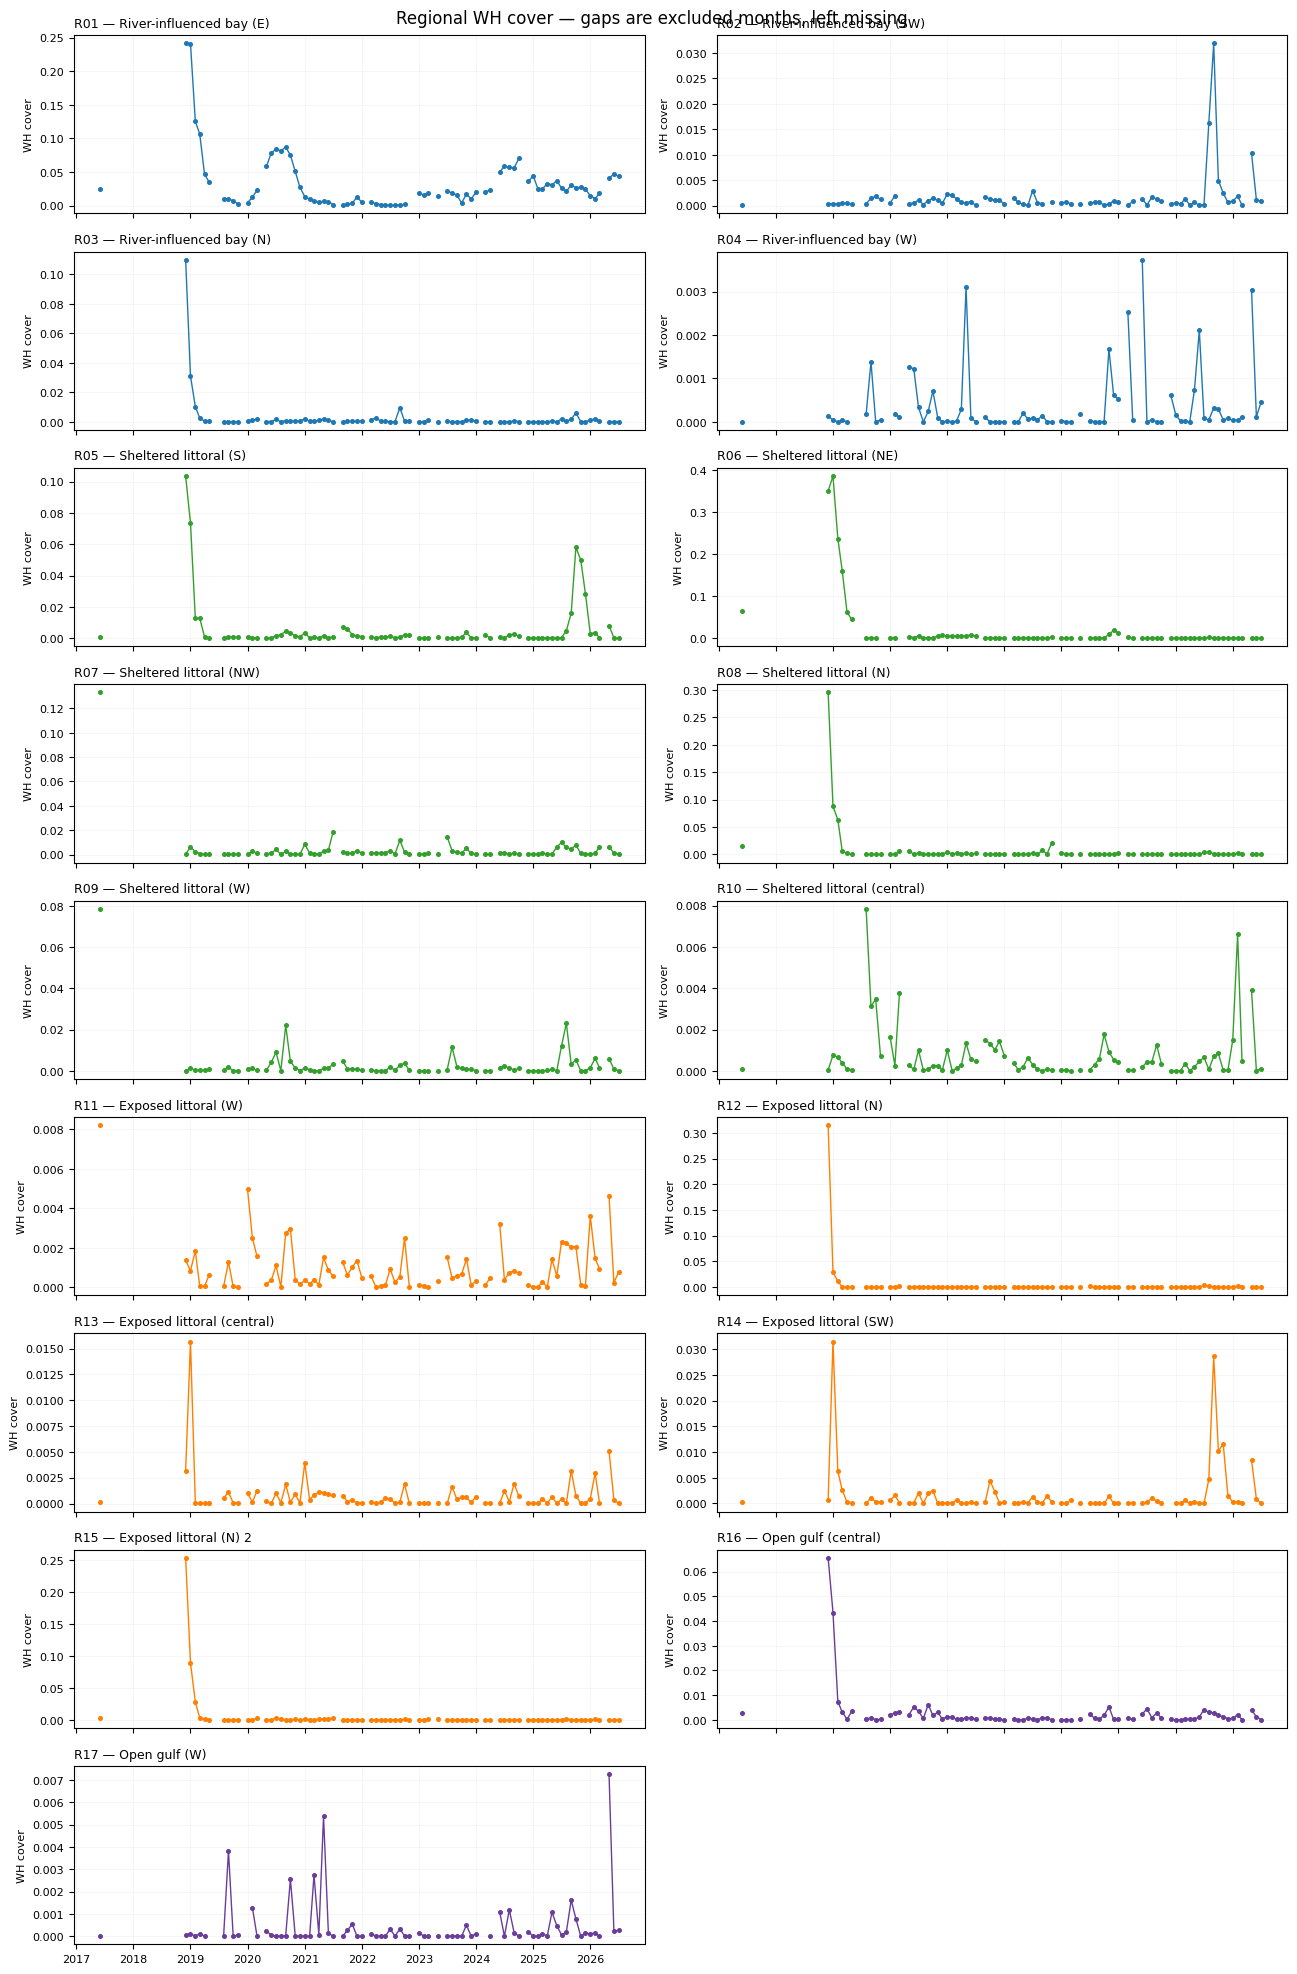

In [23]:
# =====================================================================
# 9e. The regional series
# =====================================================================
_ids = sorted(USABLE_REGION_IDS)
_ncol = 2
_nrow = int(np.ceil(len(_ids) / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(13, 2.1 * _nrow + 1.2),
                         sharex=True)
axes = np.atleast_1d(axes).ravel()
_type_colour = {"river_influenced_bay": "#1f78b4", "sheltered_littoral": "#33a02c",
                "exposed_littoral": "#ff7f00", "open_gulf": "#6a3d9a"}
for ax, rid in zip(axes, _ids):
    g = REGION_MONTH[REGION_MONTH["region_id"] == rid].sort_values("month")
    meta = REGIONS[REGIONS["region_id"] == rid].iloc[0]
    c = _type_colour.get(meta["region_type"], "0.3")
    ax.plot(g["month"], g["wh_cover"], marker="o", ms=2.6, lw=1.0, color=c)
    ax.set_ylabel("WH cover", fontsize=8)
    ax.set_title(f"{rid} — {meta['region_name']}", fontsize=9, loc="left")
    ax.grid(alpha=0.2, lw=0.4)
    ax.tick_params(labelsize=8)
for ax in axes[len(_ids):]:
    ax.axis("off")
axes[min(len(_ids), len(axes)) - 1].xaxis.set_major_locator(mdates.YearLocator())
axes[min(len(_ids), len(axes)) - 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Regional WH cover — gaps are excluded months, left missing"
             + (" (SYNTHETIC)" if SOURCE["is_synthetic"] else ""), fontsize=12)
fig.tight_layout()
save_fig(fig, "02_regional_wh_series")
plt.show()


## 10. Does the regional design add information? — driver variance decomposition

This is the section the whole notebook turns on. Splitting the gulf into $R$
regions multiplies the number of *rows* by $R$. It multiplies the amount of
*information* about a driver only if that driver actually differs between
regions within the same month.

For every driver, on the observed region-months, the total sum of squares is
split **exactly** by month:

$$\underbrace{\sum_{r,t}(x_{r,t}-\bar x)^2}_{\text{total}}=
\underbrace{\sum_{r,t}(\bar x_{\cdot t}-\bar x)^2}_{\text{between months}}+
\underbrace{\sum_{r,t}(x_{r,t}-\bar x_{\cdot t})^2}_{\text{between regions, within month}}$$

and the second term is split again into a **fixed regional offset** (a region is
persistently wetter, more exposed…) and a **region × month interaction** (the
regional pattern itself changes from month to month). The interaction is the part
that is genuinely new relative to a single AOI series.

Also reported per driver: variation within each region through time, the $R^2$
of the annual harmonics, the correlation with the linear trend, and the strongest
correlation with any other driver.

**The label.** A driver with a within-month between-region share below
`DRIVER_REGIONAL_SHARE_MIN`, or with numerically identical values across regions,
is labelled `temporal_only`. It is still estimated — it is still a real
mechanism — but its effective replication is the number of **months**, and the
notebook says so everywhere it appears.


In [24]:
# =====================================================================
# 10a. Resolve the predeclared mechanisms against the columns that exist
# =====================================================================
FORCING = {}
_rows = []
for _base, (_mech, _sign, _lag) in REGIONAL_FORCING_TERMS.items():
    _cands = [_base] + list(REGIONAL_FORCING_FALLBACKS.get(_base, []))
    _pick = next((c for c in _cands if c in REGION_MONTH.columns
                  and pd.to_numeric(REGION_MONTH[c], errors="coerce").notna().any()),
                 None)
    _rows.append({"mechanism_key": _base, "mechanism": _mech,
                  "expected_sign": _sign, "apriori_lag_months": _lag,
                  "preferred_column": _base,
                  "resolved_column": _pick if _pick else "(unavailable)",
                  "used_fallback": bool(_pick and _pick != _base),
                  "usable": _pick is not None})
    if _pick:
        FORCING[_base] = {"mechanism": _mech, "expected_sign": _sign,
                          "apriori_lag": int(_lag), "column": _pick}
FORCING_RESOLUTION = pd.DataFrame(_rows)
display(FORCING_RESOLUTION)
register("forcing_resolution", FORCING_RESOLUTION, "provenance")
_missing = FORCING_RESOLUTION.loc[~FORCING_RESOLUTION["usable"], "mechanism_key"].tolist()
if _missing:
    print(f"Mechanisms with no available column, DROPPED (never silently "
          f"substituted): {_missing}")
if not FORCING:
    raise RuntimeError("No predeclared mechanism resolved to a column in the "
                       "region-month panel.")

PROXY_COLS = [c for c in REGIONAL_PROXY_TERMS if c in REGION_MONTH.columns]
print(f"\nEndogenous optical proxies held out of every driver claim: "
      f"{PROXY_COLS or 'none present'}")
UNUSED_CANDIDATES = [c for c in CANDIDATE_DRIVER_COLS
                     if c not in {v['column'] for v in FORCING.values()}
                     and c not in PROXY_COLS]
print(f"Numeric columns in the panel that belong to no predeclared mechanism "
      f"(not modelled): {UNUSED_CANDIDATES or 'none'}")


,mechanism_key,mechanism,expected_sign,apriori_lag_months,preferred_column,resolved_column,used_fallback,usable
0,rain_chirps_30d_mm,antecedent rainfall -> catchment runoff and nu...,+,1,rain_chirps_30d_mm,rain_chirps_30d_mm,False,True
1,air_temp_c,thermal control on growth rate,+,0,air_temp_c,air_temp_c,False,True
2,wind_speed_ms,wind speed -> mixing and mat drift,?,0,wind_speed_ms,wind_speed_ms,False,True
3,wave_exposure_idx,"openness x wind^2 -> wave disturbance, mat fra...",-,0,wave_exposure_idx,wave_exposure_idx,False,True
4,lake_level_m,lake level -> depth over littoral habitat and ...,-,0,lake_level_m,lake_level_m,False,True



Endogenous optical proxies held out of every driver claim: ['chl_mci_s3', 'chl_mph_s3', 'turb_ndti_s2']
Numeric columns in the panel that belong to no predeclared mechanism (not modelled): ['source_from_directory_scan', 'sensor_is_s1', 'wind_u_ms', 'wind_v_ms', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms', 'ghsl_built_m2', 'red_reflectance_s2', 'water_temp_c', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'rain_max_1d_mm', 'rain_spikes_20mm_cnt', 'rain_spikes_40mm_cnt', 'rain_wet_days', 'rain_sdii_mm', 'nutrient_pulse_idx', 'month_sin', 'month_cos', 'wind_onshore_ms', 'wind_onshore_x_openness_index', 'wind_onshore_x_wave_exposure_idx']


In [25]:
# =====================================================================
# 10b. Variance decomposition
# =====================================================================


def decompose_driver_variance(frame, col, region_col="region_id",
                              month_col="month"):
    """Exact month-orthogonal split of a driver's variance, plus season/trend."""
    d = frame[[region_col, month_col, col, "time_index", "month_num"]].copy()
    d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna(subset=[col])
    n = len(d)
    if n < 4 or d[month_col].nunique() < 2:
        return None
    x = d[col].to_numpy(dtype=float)
    grand = float(np.mean(x))
    month_mean = d.groupby(month_col)[col].transform("mean").to_numpy()
    region_mean = d.groupby(region_col)[col].transform("mean").to_numpy()

    ss_total = float(np.sum((x - grand) ** 2))
    ss_between_month = float(np.sum((month_mean - grand) ** 2))
    ss_within_month = float(np.sum((x - month_mean) ** 2))
    ss_region_main = float(np.sum((region_mean - grand) ** 2))
    resid = x - month_mean - region_mean + grand
    ss_interaction = float(np.sum(resid ** 2))
    ss_within_region = float(np.sum((x - region_mean) ** 2))

    # within-month spread across regions, in the driver's own units
    per_month = d.groupby(month_col)[col].agg(["mean", "std", "count"])
    per_month = per_month[per_month["count"] >= 2]
    cv = (per_month["std"] / per_month["mean"].abs().replace(0, np.nan)).abs()
    med_cv = float(cv.median()) if len(cv) else 0.0
    med_sd = float(per_month["std"].median()) if len(per_month) else 0.0

    # season and trend, on the region-demeaned series so a regional offset is not
    # mistaken for seasonality
    xr = x - region_mean
    S = fourier_terms(d[month_col], SEASON_HARMONICS).to_numpy()
    try:
        r2_season = float(sm.OLS(xr, sm.add_constant(S)).fit().rsquared)
    except Exception:
        r2_season = np.nan
    tt = d["time_index"].to_numpy(dtype=float)
    r_trend = float(np.corrcoef(xr, tt)[0, 1]) if np.std(tt) > 0 else np.nan

    return {
        "driver": col, "n_region_months": int(n),
        "n_months": int(d[month_col].nunique()),
        "n_regions": int(d[region_col].nunique()),
        "share_between_months": ss_between_month / ss_total if ss_total else np.nan,
        "share_within_month_between_regions": (ss_within_month / ss_total
                                               if ss_total else np.nan),
        "share_region_main_effect": ss_region_main / ss_total if ss_total else np.nan,
        "share_region_x_month_interaction": (ss_interaction / ss_total
                                             if ss_total else np.nan),
        "share_within_region_over_time": (ss_within_region / ss_total
                                          if ss_total else np.nan),
        "month_split_sums_to_one": abs((ss_between_month + ss_within_month) / ss_total - 1.0)
        if ss_total else np.nan,
        "median_within_month_sd": med_sd,
        "median_within_month_cv": med_cv,
        "r2_annual_harmonics": r2_season,
        "corr_with_trend": r_trend,
    }


_dr_cols = [v["column"] for v in FORCING.values()] + PROXY_COLS
_obs_rm = REGION_MONTH[REGION_MONTH["observed"]].copy()
_rows = [r for r in (decompose_driver_variance(_obs_rm, c) for c in _dr_cols)
         if r is not None]
DRIVER_VARIANCE = pd.DataFrame(_rows)

# strongest correlation with any other driver, on the region-month rows
_wide = _obs_rm[_dr_cols].apply(pd.to_numeric, errors="coerce")
_corr = _wide.corr()
_carr = np.asarray(_corr, dtype=float).copy()
np.fill_diagonal(_carr, np.nan)
_corr = pd.DataFrame(_carr, index=_corr.index, columns=_corr.columns)
DRIVER_VARIANCE["max_abs_corr_other_driver"] = [
    float(np.nanmax(np.abs(_corr.loc[c].to_numpy()))) if c in _corr.index
    and np.isfinite(_corr.loc[c].to_numpy()).any() else np.nan
    for c in DRIVER_VARIANCE["driver"]]
DRIVER_VARIANCE["most_correlated_driver"] = [
    (_corr.loc[c].abs().idxmax() if c in _corr.index
     and _corr.loc[c].abs().notna().any() else None)
    for c in DRIVER_VARIANCE["driver"]]

DRIVER_VARIANCE["is_proxy"] = DRIVER_VARIANCE["driver"].isin(PROXY_COLS)
# A driver can only be called `temporal_only` if there were at least two regions
# for it to fail to vary between. With one region the within-month between-region
# share is 0 by arithmetic, and labelling that "temporal_only" would report an
# untested claim as a measured one.
DRIVER_VARIANCE["spatial_label"] = np.where(
    DRIVER_VARIANCE["n_regions"] < 2, "undetermined",
    np.where(
        (DRIVER_VARIANCE["share_within_month_between_regions"]
         >= DRIVER_REGIONAL_SHARE_MIN)
        & (DRIVER_VARIANCE["median_within_month_cv"] >= DRIVER_REGIONAL_CV_MIN),
        "spatiotemporal", "temporal_only"))
DRIVER_VARIANCE["season_confounded"] = (
    DRIVER_VARIANCE["r2_annual_harmonics"] >= SEASON_CONFOUND_R2)
DRIVER_VARIANCE["effective_replication"] = np.select(
    [DRIVER_VARIANCE["spatial_label"] == "spatiotemporal",
     DRIVER_VARIANCE["spatial_label"] == "temporal_only"],
    ["region-months (the regional design adds information)",
     "MONTHS ONLY — one gulf-wide value per month copied across regions"],
    default="UNDETERMINED — fewer than 2 regions, so between-region variance is "
            "not defined and nothing about regional variation was tested")

display(DRIVER_VARIANCE[[
    "driver", "spatial_label", "share_between_months",
    "share_within_month_between_regions", "share_region_main_effect",
    "share_region_x_month_interaction", "median_within_month_cv",
    "r2_annual_harmonics", "corr_with_trend", "max_abs_corr_other_driver",
    "season_confounded"]])
register("driver_variance_decomposition", DRIVER_VARIANCE, "diagnostic")

TEMPORAL_ONLY_DRIVERS = DRIVER_VARIANCE.loc[
    (DRIVER_VARIANCE["spatial_label"] == "temporal_only")
    & (~DRIVER_VARIANCE["is_proxy"]), "driver"].tolist()
SPATIOTEMPORAL_DRIVERS = DRIVER_VARIANCE.loc[
    (DRIVER_VARIANCE["spatial_label"] == "spatiotemporal")
    & (~DRIVER_VARIANCE["is_proxy"]), "driver"].tolist()
UNDETERMINED_DRIVERS = DRIVER_VARIANCE.loc[
    (DRIVER_VARIANCE["spatial_label"] == "undetermined")
    & (~DRIVER_VARIANCE["is_proxy"]), "driver"].tolist()

print()
print(f"SPATIOTEMPORAL ({len(SPATIOTEMPORAL_DRIVERS)}): {SPATIOTEMPORAL_DRIVERS}")
print("    These vary between regions within a month. For these, and only these, "
      "the regional design supplies information a single AOI series cannot.")
print(f"TEMPORAL ONLY ({len(TEMPORAL_ONLY_DRIVERS)}): {TEMPORAL_ONLY_DRIVERS}")
print("    One gulf-wide value per month, repeated across regions. The regional "
      "design does NOT increase their effective replication:")
print(f"    n for these drivers is the {int(_obs_rm['month'].nunique())} observed "
      f"MONTHS, not the {len(_obs_rm):,} region-months.")
if UNDETERMINED_DRIVERS:
    print(f"UNDETERMINED ({len(UNDETERMINED_DRIVERS)}): {UNDETERMINED_DRIVERS}")
    print("    Fewer than 2 regions entered the decomposition, so the "
          "within-month between-region share is 0 by ARITHMETIC and not by "
          "measurement. Nothing about regional variation was tested for these "
          "drivers, and this run must not be written up as evidence that they "
          "lack it.")
_sc = DRIVER_VARIANCE.loc[DRIVER_VARIANCE["season_confounded"], "driver"].tolist()
if _sc:
    print(f"\nSeason-confounded (R2 of the annual harmonics >= "
          f"{SEASON_CONFOUND_R2:g}): {_sc}")
    print("    Their coefficients are reported, but they cannot be separated from "
          "the annual cycle and are never called supported on their own.")


,driver,spatial_label,share_between_months,share_within_month_between_regions,share_region_main_effect,share_region_x_month_interaction,median_within_month_cv,r2_annual_harmonics,corr_with_trend,max_abs_corr_other_driver,season_confounded
0,rain_chirps_30d_mm,temporal_only,0.950618,4.938203e-02,0.017376,0.032144,1.009424e-01,0.367213,-0.072079,0.369660,False
1,air_temp_c,temporal_only,1.000000,7.536457e-30,0.000067,0.000067,8.886320e-17,0.334457,0.055051,0.706813,False
2,wind_speed_ms,temporal_only,1.000000,4.792108e-31,0.000025,0.000025,8.425802e-17,0.675391,-0.114352,0.770264,False
3,wave_exposure_idx,spatiotemporal,0.597852,4.021480e-01,0.375731,0.026977,2.175232e-01,0.617385,-0.107547,0.770264,False
4,lake_level_m,temporal_only,1.000000,7.531463e-26,0.000120,0.000120,8.665324e-17,0.106718,0.339140,0.261282,False
5,chl_mci_s3,temporal_only,1.000000,5.809515e-31,0.000279,0.000279,9.388928e-17,0.040729,0.731634,0.855539,False
6,chl_mph_s3,temporal_only,1.000000,4.757584e-32,0.000337,0.000337,8.381657e-17,0.007805,-0.721259,0.855539,False
7,turb_ndti_s2,spatiotemporal,0.369629,6.303706e-01,0.381144,0.256058,2.814112e-01,0.067235,-0.457875,0.433036,False



SPATIOTEMPORAL (1): ['wave_exposure_idx']
    These vary between regions within a month. For these, and only these, the regional design supplies information a single AOI series cannot.
TEMPORAL ONLY (4): ['rain_chirps_30d_mm', 'air_temp_c', 'wind_speed_ms', 'lake_level_m']
    One gulf-wide value per month, repeated across regions. The regional design does NOT increase their effective replication:
    n for these drivers is the 80 observed MONTHS, not the 1,347 region-months.


In [26]:
# =====================================================================
# 10c. Redundant drivers, and the predeclared random-slope set
# =====================================================================
_order = [v["column"] for v in FORCING.values()]
_drop_redundant, _redundant_rows = [], []
for i, a in enumerate(_order):
    for b in _order[i + 1:]:
        if a in _corr.index and b in _corr.columns:
            r = float(_corr.loc[a, b]) if np.isfinite(_corr.loc[a, b]) else np.nan
            if np.isfinite(r) and abs(r) > MAX_ABS_PAIRWISE_R:
                _redundant_rows.append({"kept": a, "dropped": b, "pearson_r": r})
                _drop_redundant.append(b)
REDUNDANT_DRIVERS = pd.DataFrame(_redundant_rows)
if len(REDUNDANT_DRIVERS):
    display(REDUNDANT_DRIVERS)
    print(f"Dropped as redundant (|r| > {MAX_ABS_PAIRWISE_R}): "
          f"{sorted(set(_drop_redundant))}")
    FORCING = {k: v for k, v in FORCING.items() if v["column"] not in _drop_redundant}
else:
    print(f"No driver pair exceeds |r| = {MAX_ABS_PAIRWISE_R}.")
register("redundant_drivers", REDUNDANT_DRIVERS, "diagnostic")

# Random slopes: only PREDECLARED terms that are genuinely spatiotemporal, capped
# by RANDOM_SLOPE_MAX_TERMS, and dropped entirely when there are too few regions
# to estimate a between-region slope variance.
RANDOM_SLOPE_TERMS = []
_rs_rows = []
for _cand in RANDOM_SLOPE_CANDIDATES:
    _col = FORCING.get(_cand, {}).get("column")
    if _col is None:
        _rs_rows.append({"candidate": _cand, "eligible": False,
                         "reason": "mechanism not available in this panel"})
        continue
    if _col not in SPATIOTEMPORAL_DRIVERS:
        _rs_rows.append({"candidate": _cand, "eligible": False,
                         "reason": ("regional variation UNDETERMINED in §10b "
                                    "(fewer than 2 regions) — a random slope has "
                                    "nothing to vary over"
                                    if _col in UNDETERMINED_DRIVERS else
                                    "labelled temporal_only in §10b — a random "
                                    "slope on a driver with no regional variation "
                                    "is not identified")})
        continue
    if N_REGIONS < RANDOM_SLOPE_MIN_REGIONS:
        _rs_rows.append({"candidate": _cand, "eligible": False,
                         "reason": f"only {N_REGIONS} usable regions "
                                   f"(< RANDOM_SLOPE_MIN_REGIONS="
                                   f"{RANDOM_SLOPE_MIN_REGIONS})"})
        continue
    if len(RANDOM_SLOPE_TERMS) >= RANDOM_SLOPE_MAX_TERMS:
        _rs_rows.append({"candidate": _cand, "eligible": False,
                         "reason": f"RANDOM_SLOPE_MAX_TERMS="
                                   f"{RANDOM_SLOPE_MAX_TERMS} already reached"})
        continue
    RANDOM_SLOPE_TERMS.append(_cand)
    _rs_rows.append({"candidate": _cand, "eligible": True,
                     "reason": "predeclared, spatiotemporal, and enough regions"})
RANDOM_SLOPE_DECISION = pd.DataFrame(_rs_rows)
display(RANDOM_SLOPE_DECISION)
register("random_slope_decision", RANDOM_SLOPE_DECISION, "provenance")
if RANDOM_SLOPE_TERMS:
    print(f"Random slopes on: {RANDOM_SLOPE_TERMS}")
else:
    print("Random slopes: NONE — region intercepts and common "
          "driver slopes only. An elaborate random-effects structure is not kept "
          "merely because it runs.")


No driver pair exceeds |r| = 0.9.


,candidate,eligible,reason
0,rain_chirps_30d_mm,False,labelled temporal_only in §10b — a random slop...
1,wave_exposure_idx,True,"predeclared, spatiotemporal, and enough regions"


Random slopes on: ['wave_exposure_idx']


## 11. Model dataset, standardisation and the missing-data audit

Three rules govern this section, and each is asserted rather than described.

1. **Lags are calendar lags.** A driver entering at lag 1 takes the value of the
   *previous calendar month* within the same region. Because every region sits on
   the same complete monthly grid, a lag never reaches across an excluded month
   and calls a three-month-old value "last month".
2. **Nothing is interpolated.** A missing driver at an observed response month
   means that region-month is **withheld from the likelihood** — of *both* the
   null and the full model, so the two are matched — and the withholding is
   recorded with a reason.
3. **Placeholders live only where they cannot matter.** The state-space arrays
   must be finite everywhere, so `0.0` (the centred value on the standardised
   scale) is written into predictor cells that make **no** likelihood
   contribution. §11c asserts that every placeholder sits outside the observation
   index, so no placeholder can ever reach the likelihood.

Standardisation uses the mean and SD of the **estimation rows only**. §17
re-fits its scalers inside every fold; the global scaler here is never reused
there.


In [27]:
# =====================================================================
# 11a. Arrays on the region x calendar-month grid
# =====================================================================
REGION_IDS = sorted(USABLE_REGION_IDS)
R_IDX = {rid: i for i, rid in enumerate(REGION_IDS)}
T_IDX = {m: i for i, m in enumerate(MONTH_GRID)}
R, T = len(REGION_IDS), len(MONTH_GRID)

Y_RAW = np.full((R, T), np.nan)
VALID_AREA = np.full((R, T), np.nan)
for rid, i in R_IDX.items():
    g = REGION_MONTH[REGION_MONTH["region_id"] == rid].set_index("month")
    Y_RAW[i, :] = g.reindex(MONTH_GRID)["y"].to_numpy()
    VALID_AREA[i, :] = g.reindex(MONTH_GRID)["valid_area_ha"].to_numpy()

# --- lagged driver terms, calendar-aware within each region -----------------
DRIVER_TERMS = []
DRIVER_META = []
X_RAW = np.full((R, T, len(FORCING)), np.nan)
for k, (base, meta) in enumerate(FORCING.items()):
    col, lag = meta["column"], int(meta["apriori_lag"])
    name = f"{base}_lag{lag}" if lag else base
    DRIVER_TERMS.append(name)
    DRIVER_META.append({"term": name, "mechanism_key": base, "column": col,
                        "lag_months": lag, "mechanism": meta["mechanism"],
                        "expected_sign": meta["expected_sign"],
                        "spatial_label": ("spatiotemporal"
                                          if col in SPATIOTEMPORAL_DRIVERS
                                          else "undetermined"
                                          if col in UNDETERMINED_DRIVERS
                                          else "temporal_only")})
    for rid, i in R_IDX.items():
        s = (REGION_MONTH[REGION_MONTH["region_id"] == rid]
             .set_index("month").reindex(MONTH_GRID)[col])
        X_RAW[i, :, k] = s.shift(lag).to_numpy()
DRIVER_META = pd.DataFrame(DRIVER_META)
K = len(DRIVER_TERMS)
display(DRIVER_META)
register("driver_terms", DRIVER_META, "provenance")

# --- who is in the likelihood ------------------------------------------------
OBS_MASK_Y = np.isfinite(Y_RAW)
X_COMPLETE = np.all(np.isfinite(X_RAW), axis=2) if K else np.ones((R, T), bool)
OBS_MASK = OBS_MASK_Y & X_COMPLETE       # identical for the null and the full model
OBS_R, OBS_T = np.nonzero(OBS_MASK)
N_OBS = int(OBS_MASK.sum())
print(f"Likelihood rows: {N_OBS:,} region-months "
      f"({R} regions x {T} calendar months = {R * T:,} cells in the grid).")

# --- standardisation on the estimation rows only -----------------------------
_scale_rows = []
X_STD = np.zeros_like(X_RAW)
for k, name in enumerate(DRIVER_TERMS):
    v = X_RAW[:, :, k][OBS_MASK]
    mu, sd = float(np.nanmean(v)), float(np.nanstd(v))
    sd = sd if np.isfinite(sd) and sd > 0 else 1.0
    X_STD[:, :, k] = (X_RAW[:, :, k] - mu) / sd
    _scale_rows.append({"term": name, "mean": mu, "sd": sd,
                        "n_rows_used": int(np.isfinite(v).sum()),
                        "scope": "estimation rows only (§17 refits per fold)"})
DRIVER_SCALING = pd.DataFrame(_scale_rows)
display(DRIVER_SCALING)
register("driver_scaling", DRIVER_SCALING, "provenance")

# --- season, trend -----------------------------------------------------------
SEASON = fourier_terms(pd.Series(MONTH_GRID), SEASON_HARMONICS).to_numpy()
SEASON_NAMES = list(fourier_terms(pd.Series(MONTH_GRID), SEASON_HARMONICS).columns)
_tt = np.arange(T, dtype=float)
TREND_SCALER = {"mean": float(_tt.mean()), "sd": float(_tt.std() or 1.0)}
TT = (_tt - TREND_SCALER["mean"]) / TREND_SCALER["sd"]
print(f"Season: {SEASON_NAMES} (deterministic annual Fourier terms). "
      f"Trend: {'on' if INCLUDE_TREND else 'off'}.")
print("No unrestricted calendar-month fixed effects are included anywhere: a free "
      "effect for every month would absorb every gulf-wide temporal driver and "
      "make it unidentifiable.")


,term,mechanism_key,column,lag_months,mechanism,expected_sign,spatial_label
0,rain_chirps_30d_mm_lag1,rain_chirps_30d_mm,rain_chirps_30d_mm,1,antecedent rainfall -> catchment runoff and nu...,+,temporal_only
1,air_temp_c,air_temp_c,air_temp_c,0,thermal control on growth rate,+,temporal_only
2,wind_speed_ms,wind_speed_ms,wind_speed_ms,0,wind speed -> mixing and mat drift,?,temporal_only
3,wave_exposure_idx,wave_exposure_idx,wave_exposure_idx,0,"openness x wind^2 -> wave disturbance, mat fra...",-,spatiotemporal
4,lake_level_m,lake_level_m,lake_level_m,0,lake level -> depth over littoral habitat and ...,-,temporal_only


Likelihood rows: 1,281 region-months (17 regions x 112 calendar months = 1,904 cells in the grid).


,term,mean,sd,n_rows_used,scope
0,rain_chirps_30d_mm_lag1,135.034061,78.800075,1281,estimation rows only (§17 refits per fold)
1,air_temp_c,22.807861,0.809868,1281,estimation rows only (§17 refits per fold)
2,wind_speed_ms,1.766346,0.224533,1281,estimation rows only (§17 refits per fold)
3,wave_exposure_idx,209.713373,73.189245,1281,estimation rows only (§17 refits per fold)
4,lake_level_m,1136.099006,0.366274,1281,estimation rows only (§17 refits per fold)


Season: ['season_sin1', 'season_cos1', 'season_sin2', 'season_cos2'] (deterministic annual Fourier terms). Trend: on.
No unrestricted calendar-month fixed effects are included anywhere: a free effect for every month would absorb every gulf-wide temporal driver and make it unidentifiable.


In [28]:
# =====================================================================
# 11b. Missing-data audit
# =====================================================================
_rows = []
for rid, i in R_IDX.items():
    y_ok = OBS_MASK_Y[i]
    x_ok = X_COMPLETE[i]
    _rows.append({
        "region_id": rid,
        "calendar_months": T,
        "response_observed": int(y_ok.sum()),
        "response_missing": int((~y_ok).sum()),
        "in_likelihood": int((y_ok & x_ok).sum()),
        "withheld_response_observed_driver_missing": int((y_ok & ~x_ok).sum()),
        "state_only_response_missing": int((~y_ok).sum()),
    })
MISSING_AUDIT = (pd.DataFrame(_rows)
                 .merge(REGIONS[["region_id", "region_name", "region_type"]],
                        on="region_id", how="left"))
display(MISSING_AUDIT)
register("missing_data_audit", MISSING_AUDIT, "diagnostic")

_withheld = int((OBS_MASK_Y & ~X_COMPLETE).sum())
print(f"Region-months with an observed response but an incomplete driver row: "
      f"{_withheld:,}. These are WITHHELD from the likelihood of BOTH the null "
      "and the full model, so the two remain matched. They are not imputed.")
if _withheld and K:
    _by_term = []
    for k, name in enumerate(DRIVER_TERMS):
        miss = OBS_MASK_Y & ~np.isfinite(X_RAW[:, :, k])
        _by_term.append({"term": name, "n_withheld_because_of_this_term":
                         int(miss.sum())})
    display(pd.DataFrame(_by_term))
print(f"Region-months whose response is missing: "
      f"{int((~OBS_MASK_Y).sum()):,}. The state process runs through them; they "
      "make no likelihood contribution.")

# --- placeholders, and the assertion that they cannot matter ----------------
_placeholder = ~np.isfinite(X_STD)
X_MODEL = np.where(_placeholder, 0.0, X_STD)
_bad = int((_placeholder & OBS_MASK[:, :, None]).sum()) if K else 0
assert _bad == 0, (f"{_bad} placeholder value(s) sit on rows that DO enter the "
                   "likelihood; the observation set and the placeholder mask "
                   "disagree.")
assert np.isfinite(X_MODEL).all(), "non-finite predictor after placeholder fill"
assert np.isfinite(Y_RAW[OBS_MASK]).all(), "non-finite response in the likelihood"
PLACEHOLDER_AUDIT = pd.DataFrame([{
    "n_predictor_cells": int(X_STD.size),
    "n_placeholder_cells": int(_placeholder.sum()),
    "placeholder_value": 0.0,
    "placeholder_scale": "standardised (0.0 IS the centred value)",
    "n_placeholders_inside_likelihood": _bad,
    "assertion": "every placeholder lies outside the observation index, so no "
                 "placeholder makes an observation-likelihood contribution",
}])
display(PLACEHOLDER_AUDIT)
register("placeholder_audit", PLACEHOLDER_AUDIT, "provenance")


,region_id,calendar_months,response_observed,response_missing,in_likelihood,withheld_response_observed_driver_missing,state_only_response_missing,region_name,region_type
0,R01,112,79,33,75,4,33,River-influenced bay (E),river_influenced_bay
1,R02,112,78,34,74,4,34,River-influenced bay (SW),river_influenced_bay
2,R03,112,79,33,75,4,33,River-influenced bay (N),river_influenced_bay
3,R04,112,78,34,75,3,34,River-influenced bay (W),river_influenced_bay
4,R05,112,80,32,76,4,32,Sheltered littoral (S),sheltered_littoral
5,R06,112,78,34,74,4,34,Sheltered littoral (NE),sheltered_littoral
6,R07,112,80,32,76,4,32,Sheltered littoral (NW),sheltered_littoral
7,R08,112,80,32,76,4,32,Sheltered littoral (N),sheltered_littoral
8,R09,112,80,32,76,4,32,Sheltered littoral (W),sheltered_littoral
9,R10,112,80,32,76,4,32,Sheltered littoral (central),sheltered_littoral


Region-months with an observed response but an incomplete driver row: 66. These are WITHHELD from the likelihood of BOTH the null and the full model, so the two remain matched. They are not imputed.


,term,n_withheld_because_of_this_term
0,rain_chirps_30d_mm_lag1,32
1,air_temp_c,0
2,wind_speed_ms,0
3,wave_exposure_idx,0
4,lake_level_m,34


Region-months whose response is missing: 557. The state process runs through them; they make no likelihood contribution.


,n_predictor_cells,n_placeholder_cells,placeholder_value,placeholder_scale,n_placeholders_inside_likelihood,assertion
0,9520,1955,0.0,standardised (0.0 IS the centred value),0,every placeholder lies outside the observation...


,n_predictor_cells,n_placeholder_cells,placeholder_value,placeholder_scale,n_placeholders_inside_likelihood,assertion
0,9520,1955,0.0,standardised (0.0 IS the centred value),0,every placeholder lies outside the observation...


## 12. The panel dynamic regression

One equation, fitted by least squares in a fraction of a second. For region $r$
in calendar month $t$:

$$y_{r,t} \;=\; \alpha_r \;+\; \mathbf{s}_t'\boldsymbol\gamma \;+\; \tau\,t
\;+\; \mathbf{x}_{r,t}'\boldsymbol\beta \;+\; e_{r,t},
\qquad
e_{r,t} \;=\; \sum_{j=1}^{p}\rho_j\,e_{r,t-j} \;+\; v_{r,t}$$

with $y_{r,t} = \operatorname{logit}$ of regional WH cover, $\alpha_r$ a
**region intercept**, $\mathbf{s}_t$ the deterministic annual Fourier terms,
$\tau$ an optional linear trend, and $\mathbf{x}_{r,t}$ the predeclared drivers
at their a-priori lags.

### Why this, and what it costs

This is the same estimand as a hierarchical dynamic model — a level equation
with persistent errors — estimated by maximum likelihood instead of MCMC. It
mirrors the AOI temporal notebook, which fits `SARIMAX(order=(p,0,0))` with
exogenous regressors: *regression with AR(p) errors*, selected on **AICc**. Using
one statistical idiom across both analyses is deliberate.

Two things are genuinely lost relative to a hierarchical model, and neither is
hidden:

| Lost | Consequence here |
|---|---|
| partial pooling of $\alpha_r$ | region intercepts are **fixed effects**, estimated independently. With ~80 months per region they are precisely estimated anyway, so shrinkage would move them very little — but $\sigma_\alpha$ is no longer a parameter and §16 reports the spread of the $\hat\alpha_r$ descriptively, not as a variance component. |
| region-varying slopes | not estimated. §10c already refused them whenever fewer than `RANDOM_SLOPE_MIN_REGIONS` regions exist or no driver is `spatiotemporal`, so on this record nothing is given up. |

### The two sources of dependence, and what handles each

A region-month panel is dependent in two directions at once, and an interval
that ignores either is too narrow:

1. **Across months, within a region** — persistence. Handled *in the mean model*
   by the AR($p$) error structure, with $p$ chosen in §13 on the **no-driver**
   model, so the choice cannot be tuned to a driver result. §15 checks with a
   calendar Ljung-Box that it worked.
2. **Across regions, within a month** — every region sees the same weather, the
   same lake, the same satellite pass. Handled *in the standard errors* by
   **clustering on calendar month**: regions sharing a month count as ONE
   independent unit.

That second choice is the whole of §10's argument made operational. For a driver
with one gulf-wide value per month, month-clustering makes the effective sample
size the number of **months**; the region-months add no independent information
and the standard errors say so.

### Estimation

Iterated Cochrane-Orcutt: fit by OLS, estimate $\rho$ from calendar-consecutive
residual pairs, quasi-difference $y$ and every column of $X$, refit, repeat to
convergence. Quasi-differencing needs lags $1\ldots p$ to be **observed calendar
months**, so the estimation sample is the rows for which they are — fixed once at
`AR_MAX_LAGS` so every candidate $p$, and the null and full models alike, are
fitted on **identical rows**.


In [29]:
# =====================================================================
# 12. The estimator — regression with AR(p) errors on the region-month panel
# =====================================================================


def make_model_data(X_model, Y, obs_mask, season, tt, region_ids, driver_terms,
                    random_slope_terms=()):
    """Package the arrays the estimator needs, with the observation index."""
    obs_r, obs_t = np.nonzero(obs_mask)
    return {
        "R": int(Y.shape[0]), "T": int(Y.shape[1]), "K": int(X_model.shape[2]),
        "X": X_model, "Y": Y, "obs_mask": obs_mask,
        "obs_r": obs_r, "obs_t": obs_t,
        "y_obs": Y[obs_r, obs_t],
        "X_obs": (X_model[obs_r, obs_t, :] if X_model.shape[2]
                  else np.zeros((len(obs_r), 0))),
        "season": season, "tt": np.asarray(tt, dtype=float),
        "region_ids": list(region_ids), "driver_terms": list(driver_terms),
    }


def calendar_acf(values, month_pos, max_lag=12):
    """ACF using only pairs exactly h CALENDAR months apart (NaN-safe)."""
    v = np.asarray(values, dtype=float)
    m = np.asarray(month_pos, dtype=int)
    ok = np.isfinite(v)
    v, m = v[ok], m[ok]
    if len(v) < 4:
        return pd.DataFrame(columns=["lag", "acf", "n_pairs"])
    vc = v - v.mean()
    denom = float(np.sum(vc ** 2))
    pos = {int(a): i for i, a in enumerate(m)}
    rows = []
    for h in range(1, int(max_lag) + 1):
        pairs = [(i, pos[int(a) - h]) for i, a in enumerate(m) if int(a) - h in pos]
        if not pairs or denom <= 0:
            rows.append({"lag": h, "acf": np.nan, "n_pairs": len(pairs)})
            continue
        num = float(np.sum([vc[i] * vc[j] for i, j in pairs]))
        rows.append({"lag": h, "acf": num / denom, "n_pairs": len(pairs)})
    return pd.DataFrame(rows)


def calendar_ljung_box(values, month_pos, lags=3):
    """Ljung-Box on CALENDAR lags, dropping lags with no calendar pairs.

    The standard statistic assumes an unbroken series. A third of this record's
    months carry no WH map, so the test is built from the calendar ACF and its
    degrees of freedom count only the lags that had pairs to measure.
    """
    a = calendar_acf(values, month_pos, lags)
    a = a[np.isfinite(a["acf"]) & (a["n_pairs"] > 2)]
    n = int(np.isfinite(np.asarray(values, dtype=float)).sum())
    if not len(a) or n <= len(a) + 1:
        return {"stat": np.nan, "df": 0, "p_value": np.nan, "n_pairs": 0}
    stat = float(n * (n + 2) * np.sum(a["acf"].to_numpy() ** 2
                                      / (n - a["lag"].to_numpy())))
    df = int(len(a))
    return {"stat": stat, "df": df,
            "p_value": float(sstats.chi2.sf(stat, df)),
            "n_pairs": int(a["n_pairs"].min())}


def residual_frame_from_fit(fit, data, month_grid, region_ids):
    """Level residuals y - Xb with region and calendar-month keys."""
    rows = fit["rows"]
    obs_r = np.asarray(data["obs_r"])[rows]
    obs_t = np.asarray(data["obs_t"])[rows]
    y = np.asarray(data["y_obs"], dtype=float)[rows]
    e = np.asarray(fit["resid_level"], dtype=float)[rows]
    return pd.DataFrame({
        "region_id": [region_ids[i] for i in obs_r],
        "month": [month_grid[i] for i in obs_t],
        "month_pos": obs_t, "y": y, "eta": y - e, "resid": e})


def aicc_from(llf, k, n):
    """AICc = -2 logL + 2k + 2k(k+1)/(n-k-1).

    Same definition as the AOI temporal notebook, so the two analyses' model
    selections are directly comparable. `n` is the number of rows actually in
    the likelihood, never the size of the calendar grid.
    """
    llf, k, n = float(llf), int(k), int(n)
    if n - k - 1 <= 0:
        return np.inf
    return -2.0 * llf + 2.0 * k + (2.0 * k * (k + 1)) / (n - k - 1)


def gaussian_llf(resid, n=None):
    """Concentrated Gaussian log-likelihood of an OLS/GLS residual vector."""
    r = np.asarray(resid, dtype=float)
    n = int(len(r) if n is None else n)
    if n <= 0:
        return np.nan
    s2 = float(np.sum(r ** 2) / n)
    if not np.isfinite(s2) or s2 <= 0:
        return np.inf
    return -0.5 * n * (np.log(2.0 * np.pi * s2) + 1.0)


def lag_row_index(obs_r, obs_t, lag):
    """Row index of the same REGION exactly `lag` CALENDAR months earlier, or -1.

    Calendar-first, exactly as everywhere else in this notebook: the lag reaches
    the previous calendar month, never the previous observed row. A month that
    was excluded therefore breaks the chain instead of quietly shortening it.
    """
    pos = {(int(r), int(t)): i for i, (r, t) in enumerate(zip(obs_r, obs_t))}
    return np.array([pos.get((int(r), int(t) - int(lag)), -1)
                     for r, t in zip(obs_r, obs_t)], dtype=int)


def ar_estimation_rows(obs_r, obs_t, max_lags):
    """Rows whose lags 1..max_lags all exist, and the lag index for each lag.

    Fixing this ONCE at `max_lags` is what makes AICc comparable across
    candidate orders: every candidate, and the null and full models, are fitted
    on the same rows.
    """
    idx = {L: lag_row_index(obs_r, obs_t, L) for L in range(1, int(max_lags) + 1)}
    ok = np.ones(len(obs_r), dtype=bool)
    for L in range(1, int(max_lags) + 1):
        ok &= idx[L] >= 0
    return ok, idx


def panel_design(data, rows, drivers=True, include_trend=True,
                 region_ids=None, drop_terms=()):
    """The design matrix on `rows` of the observation index.

    Region intercepts enter as a full set of dummies with NO global constant, so
    each column's coefficient IS that region's intercept and no region is an
    implicit baseline.
    """
    obs_r, obs_t = data["obs_r"][rows], data["obs_t"][rows]
    rid = list(region_ids if region_ids is not None else data["region_ids"])
    cols, names, groups = [], [], []

    for i, r in enumerate(rid):
        cols.append((obs_r == i).astype(float))
        names.append(f"alpha[{r}]")
        groups.append("region")

    S = np.asarray(data["season"], dtype=float)
    for j in range(S.shape[1]):
        cols.append(S[obs_t, j])
        names.append(f"season[s{j}]")
        groups.append("season")

    if include_trend:
        cols.append(np.asarray(data["tt"], dtype=float)[obs_t])
        names.append("trend")
        groups.append("trend")

    if drivers and data["K"]:
        X = data["X"][data["obs_r"], data["obs_t"], :][rows, :]
        for k, term in enumerate(data["driver_terms"]):
            if term in drop_terms:
                continue
            cols.append(X[:, k])
            names.append(term)
            groups.append("driver")

    X = np.column_stack(cols) if cols else np.zeros((int(rows.sum()), 0))
    return X, names, groups


def estimate_ar_coeffs(resid, rows, lag_index, p):
    """AR(p) coefficients of the residual process, on calendar-consecutive rows.

    Regressing the residual on its own calendar lags. `resid` is indexed by the
    FULL observation index; `rows` selects the estimation sample.
    """
    if int(p) <= 0:
        return np.zeros(0)
    r = np.asarray(resid, dtype=float)
    y = r[rows]
    L = np.column_stack([r[lag_index[j][rows]] for j in range(1, int(p) + 1)])
    ok = np.isfinite(y) & np.all(np.isfinite(L), axis=1)
    if ok.sum() <= p + 1:
        return np.zeros(int(p))
    coef, *_ = np.linalg.lstsq(L[ok], y[ok], rcond=None)
    return np.asarray(coef, dtype=float)


def quasi_difference(vec_full, rows, lag_index, rho):
    """v_t - sum_j rho_j v_{t-j} on `rows`, using CALENDAR lags."""
    v = np.asarray(vec_full, dtype=float)
    out = v[rows].copy()
    for j, rj in enumerate(np.atleast_1d(rho), start=1):
        out = out - float(rj) * v[lag_index[j][rows]]
    return out


def fit_panel_ar(data, p=0, drivers=True, include_trend=True, rows=None,
                 lag_index=None, region_ids=None, drop_terms=(),
                 cluster_on="month", max_iter=None, tol=1e-7, label=""):
    """Regression with AR(p) errors, month-clustered covariance. Returns a dict.

    Iterated Cochrane-Orcutt. The returned `resid` is the LEVEL residual
    (y - X b), not the quasi-differenced one, because that is what §15's
    diagnostics and §17's forecasts need.
    """
    t0 = time.time()
    max_iter = AR_MAX_ITER if max_iter is None else int(max_iter)
    if rows is None or lag_index is None:
        rows, lag_index = ar_estimation_rows(data["obs_r"], data["obs_t"],
                                             AR_MAX_LAGS)
    # The design is built on EVERY observed row, not just the estimation rows,
    # because quasi-differencing reads the design at the LAGGED row. Building it
    # only on the estimation sample would make those lookups NaN and silently
    # throw away every row whose own lag is not itself an estimation row.
    n_full = len(data["y_obs"])
    all_rows = np.ones(n_full, dtype=bool)
    X_full, names, groups = panel_design(
        data, all_rows, drivers=drivers, include_trend=include_trend,
        region_ids=region_ids, drop_terms=drop_terms)
    X_rows = X_full[rows, :]
    y_full = np.asarray(data["y_obs"], dtype=float)
    y_rows = y_full[rows]

    months = np.asarray(data["obs_t"], dtype=int)[rows]
    rho = np.zeros(int(p))
    beta = None
    for _ in range(max(1, max_iter)):
        if int(p) == 0:
            yq, Xq = y_rows, X_rows
        else:
            yq = quasi_difference(y_full, rows, lag_index, rho)
            Xq = np.column_stack([
                quasi_difference(X_full[:, c], rows, lag_index, rho)
                for c in range(X_full.shape[1])])
        ok = np.isfinite(yq) & np.all(np.isfinite(Xq), axis=1)
        beta_new, *_ = np.linalg.lstsq(Xq[ok], yq[ok], rcond=None)
        # level residuals, needed to re-estimate rho on the ORIGINAL scale
        resid_full = np.full(n_full, np.nan)
        resid_full[rows] = y_rows - X_rows @ beta_new
        if int(p) == 0:
            beta = beta_new
            break
        rho_new = estimate_ar_coeffs(resid_full, rows, lag_index, p)
        moved = (np.max(np.abs(rho_new - rho)) if len(rho) else 0.0)
        rho, beta = rho_new, beta_new
        if moved < tol:
            break

    if int(p) == 0:
        yq, Xq = y_rows, X_rows
    else:
        yq = quasi_difference(y_full, rows, lag_index, rho)
        Xq = np.column_stack([quasi_difference(X_full[:, c], rows, lag_index, rho)
                              for c in range(X_full.shape[1])])
    ok = np.isfinite(yq) & np.all(np.isfinite(Xq), axis=1)

    frame = pd.DataFrame(Xq[ok], columns=names)
    res = sm.OLS(yq[ok], frame).fit(
        cov_type=("cluster" if cluster_on == "month" else "nonrobust"),
        cov_kwds=({"groups": months[ok], "use_correction": True}
                  if cluster_on == "month" else None))

    beta = np.asarray(res.params, dtype=float)
    resid_level = np.full(n_full, np.nan)
    resid_level[rows] = y_rows - X_rows @ beta
    n_used = int(ok.sum())
    k_free = int(X_rows.shape[1]) + int(p) + 1          # + sigma
    llf = gaussian_llf(np.asarray(res.resid, dtype=float), n_used)
    return {
        "label": label, "p": int(p), "rho": rho,
        "params": pd.Series(beta, index=names), "names": names,
        "groups": groups, "result": res,
        "cov": np.asarray(res.cov_params(), dtype=float),
        "se": pd.Series(np.sqrt(np.diag(np.asarray(res.cov_params()))),
                        index=names),
        "n_obs": n_used, "n_clusters": int(len(np.unique(months[ok]))),
        "k_free": k_free, "llf": float(llf),
        "aicc": float(aicc_from(llf, k_free, n_used)),
        "rows": rows, "lag_index": lag_index,
        "resid_level": resid_level, "months": months, "ok": ok,
        "drivers": bool(drivers), "include_trend": bool(include_trend),
        "drop_terms": list(drop_terms),
        "seconds": round(time.time() - t0, 3),
    }


def coef_frame(fit, terms=None, level=None):
    """Estimate, clustered SE, t, p and CI for the requested terms."""
    level = HDI_PROB if level is None else float(level)
    res = fit["result"]
    ci = res.conf_int(alpha=1.0 - level)
    ci = np.asarray(ci, dtype=float)
    rows = []
    for i, nm in enumerate(fit["names"]):
        if terms is not None and nm not in terms:
            continue
        rows.append({"term": nm, "estimate": float(fit["params"].iloc[i]),
                     "se": float(fit["se"].iloc[i]),
                     "t": float(res.tvalues.iloc[i]),
                     "p_value": float(res.pvalues.iloc[i]),
                     "ci_lo": float(ci[i, 0]), "ci_hi": float(ci[i, 1])})
    return pd.DataFrame(rows)


print(f"§12 estimator defined: regression with AR(p) errors, p <= {AR_MAX_LAGS}, "
      f"month-clustered standard errors, {int(HDI_PROB * 100)}% intervals.")


§12 estimator defined: regression with AR(p) errors, p <= 2, month-clustered standard errors, 95% intervals.


## 13. Step 1 — which persistence structure does the record support?

The error structure is chosen on the **no-driver** model, exactly as before. A
persistence structure picked because it flattered a driver coefficient would
make every interval below meaningless, so the drivers are absent from every
candidate here.

Candidates are AR orders $p = 0, 1, \ldots$ up to `AR_MAX_LAGS`, all fitted on
**identical rows** — the rows for which every lag up to `AR_MAX_LAGS` is an
observed calendar month — so their **AICc** values are comparable. AICc, not
AIC, because the estimation sample is small relative to the parameter count and
the correction matters.


In [30]:
# =====================================================================
# 13a. Fit the candidate error structures, with NO driver in any of them
# =====================================================================
NULL_DATA = make_model_data(X_MODEL, Y_RAW, OBS_MASK, SEASON, TT, REGION_IDS,
                            DRIVER_TERMS, random_slope_terms=[])

AR_ROWS, AR_LAGX = ar_estimation_rows(NULL_DATA["obs_r"], NULL_DATA["obs_t"],
                                      AR_MAX_LAGS)
print(f"Estimation sample: {int(AR_ROWS.sum())} of {len(NULL_DATA['y_obs'])} "
      f"observed region-months have every calendar lag up to {AR_MAX_LAGS} "
      f"present.")
print(f"  The {int((~AR_ROWS).sum())} excluded rows follow an EXCLUDED month, so "
      "the quasi-difference has no previous calendar month to reach. They are "
      "dropped rather than allowed to reach further back, and every candidate "
      "below is fitted on exactly these rows.")

AR_CANDIDATES = pd.DataFrame()
NULL_FITS, SELECTED_AR_ORDER, SELECTION_NOTE = {}, None, ""
_rows = []
for _p in range(0, int(AR_MAX_LAGS) + 1):
    _f = fit_panel_ar(NULL_DATA, p=_p, drivers=False, include_trend=INCLUDE_TREND,
                      rows=AR_ROWS, lag_index=AR_LAGX, label=f"null_ar{_p}")
    NULL_FITS[_p] = _f
    _res = residual_frame_from_fit(_f, NULL_DATA, MONTH_GRID, REGION_IDS)
    _acf1, _lb = [], []
    for _rid, _g in _res.groupby("region_id"):
        _a = calendar_acf(_g["resid"].to_numpy(), _g["month_pos"].to_numpy(), 3)
        if len(_a) and np.isfinite(_a.loc[_a["lag"] == 1, "acf"].iloc[0]):
            _acf1.append(abs(float(_a.loc[_a["lag"] == 1, "acf"].iloc[0])))
    _rows.append({
        "ar_order": _p,
        "description": ("independent errors" if _p == 0
                        else f"AR({_p}) errors within each region"),
        "n_obs": _f["n_obs"], "n_month_clusters": _f["n_clusters"],
        "k_free": _f["k_free"], "llf": _f["llf"], "aicc": _f["aicc"],
        "rho": ", ".join(f"{r:.3f}" for r in _f["rho"]) if _p else "",
        "stationary": (bool(abs(np.sum(_f["rho"])) < 1.0) if _p else True),
        "mean_abs_resid_acf1": float(np.nanmean(_acf1)) if _acf1 else np.nan,
        "seconds": _f["seconds"]})
AR_CANDIDATES = pd.DataFrame(_rows).sort_values("aicc").reset_index(drop=True)
AR_CANDIDATES["delta_aicc"] = (AR_CANDIDATES["aicc"]
                               - AR_CANDIDATES["aicc"].min())
display(AR_CANDIDATES)
register("ar_structure_candidates", AR_CANDIDATES, "model selection")

_ok = AR_CANDIDATES[AR_CANDIDATES["stationary"]]
_pick = (_ok if len(_ok) else AR_CANDIDATES).iloc[0]
SELECTED_AR_ORDER = int(_pick["ar_order"])
SELECTION_NOTE = (f"AR({SELECTED_AR_ORDER}) selected on AICc "
                  f"({_pick['aicc']:.2f}); next best is "
                  f"{AR_CANDIDATES['delta_aicc'].iloc[1]:.2f} AICc behind"
                  if len(AR_CANDIDATES) > 1 else "single candidate")
print(f"\nSELECTED error structure: AR({SELECTED_AR_ORDER}) — {_pick['description']}")
if SELECTED_AR_ORDER:
    print(f"  rho = {_pick['rho']}   (stationary: {_pick['stationary']})")
print(f"  {SELECTION_NOTE}")
print("  Residual |ACF(1)| left by this structure: "
      f"{_pick['mean_abs_resid_acf1']:.3f} (0 = the persistence is fully "
      "absorbed; §15 tests it formally).")
print("\nThis choice was made with NO environmental driver in any candidate.")
if not bool(_pick["stationary"]):
    print("\n*** The selected AR coefficients are NOT inside the stationary "
          "region. A non-stationary error process means the level wanders "
          "without reverting, and a regression on it can manufacture "
          "association from two trending series. §15 reports this and §16 "
          "refuses to call any coefficient supported. ***")
register("ar_structure_selection",
         pd.DataFrame([{"selected_ar_order": SELECTED_AR_ORDER,
                        "note": SELECTION_NOTE,
                        "chosen_with_drivers": False}]), "model selection")


Estimation sample: 860 of 1281 observed region-months have every calendar lag up to 2 present.
  The 421 excluded rows follow an EXCLUDED month, so the quasi-difference has no previous calendar month to reach. They are dropped rather than allowed to reach further back, and every candidate below is fitted on exactly these rows.


,ar_order,description,n_obs,n_month_clusters,k_free,llf,aicc,rho,stationary,mean_abs_resid_acf1,seconds,delta_aicc
0,2,AR(2) errors within each region,860,51,25,-1348.171513,2747.901779,"0.305, 0.122",True,0.257193,0.027,0.000000
1,1,AR(1) errors within each region,860,51,24,-1360.761721,2770.960567,0.353,True,0.259195,0.017,23.058788
2,0,independent errors,860,51,23,-1443.991531,2935.303635,,True,0.262813,0.011,187.401856



SELECTED error structure: AR(2) — AR(2) errors within each region
  rho = 0.305, 0.122   (stationary: True)
  AR(2) selected on AICc (2747.90); next best is 23.06 AICc behind
  Residual |ACF(1)| left by this structure: 0.257 (0 = the persistence is fully absorbed; §15 tests it formally).

This choice was made with NO environmental driver in any candidate.


,selected_ar_order,note,chosen_with_drivers
0,2,AR(2) selected on AICc (2747.90); next best is...,False


## 14. Step 2 — matched `regional_null` vs `regional_full`

Same rows, same error structure, same seasonal and trend terms. The **only**
difference is the driver block, which makes the two nested and the comparison a
like-for-like one:

* an **F-test** on the driver block, using the *month-clustered* covariance, so
  the test inherits the same "regions in a month are one unit" logic as every
  interval in §16;
* the **AICc** difference, comparable with the AOI temporal notebook's;
* and, in §17, the only comparison that really settles it — genuine
  one-calendar-month-ahead forecasts.


In [31]:
# =====================================================================
# 14. The matched pair
# =====================================================================
MODEL_DATA = make_model_data(X_MODEL, Y_RAW, OBS_MASK, SEASON, TT, REGION_IDS,
                             DRIVER_TERMS, random_slope_terms=[])
FINAL_CONFIG = {"ar_order": SELECTED_AR_ORDER, "include_trend": bool(INCLUDE_TREND),
                "cluster_on": "month", "drop_terms": []}

FIT_NULL = fit_panel_ar(MODEL_DATA, p=SELECTED_AR_ORDER, drivers=False,
                        include_trend=INCLUDE_TREND, rows=AR_ROWS,
                        lag_index=AR_LAGX, label="regional_null")
FIT_FULL = fit_panel_ar(MODEL_DATA, p=SELECTED_AR_ORDER, drivers=True,
                        include_trend=INCLUDE_TREND, rows=AR_ROWS,
                        lag_index=AR_LAGX, label="regional_full")
PAIR = {"null": FIT_NULL, "full": FIT_FULL}

assert FIT_NULL["n_obs"] == FIT_FULL["n_obs"], (
    "the null and full models must be fitted on identical rows")
print(f"Matched pair fitted on {FIT_FULL['n_obs']} region-months "
      f"({FIT_FULL['n_clusters']} calendar-month clusters), "
      f"AR({SELECTED_AR_ORDER}) errors.")
print(f"  null: {FIT_NULL['seconds']:.2f}s | full: {FIT_FULL['seconds']:.2f}s")

_drv = [t for t in MODEL_DATA["driver_terms"] if t in FIT_FULL["names"]]
_ftest = None
if _drv:
    _R = np.zeros((len(_drv), len(FIT_FULL["names"])))
    for _i, _t in enumerate(_drv):
        _R[_i, FIT_FULL["names"].index(_t)] = 1.0
    _ftest = FIT_FULL["result"].f_test(_R)

NULL_VS_FULL = pd.DataFrame([
    {"model": "regional_null", "n_obs": FIT_NULL["n_obs"],
     "k_free": FIT_NULL["k_free"], "llf": FIT_NULL["llf"],
     "aicc": FIT_NULL["aicc"]},
    {"model": "regional_full", "n_obs": FIT_FULL["n_obs"],
     "k_free": FIT_FULL["k_free"], "llf": FIT_FULL["llf"],
     "aicc": FIT_FULL["aicc"]}])
NULL_VS_FULL["delta_aicc"] = NULL_VS_FULL["aicc"] - NULL_VS_FULL["aicc"].min()
display(NULL_VS_FULL)

_daicc = float(FIT_FULL["aicc"] - FIT_NULL["aicc"])
print(f"AICc favours {'regional_full' if _daicc < 0 else 'regional_null'} "
      f"(difference {abs(_daicc):.2f}).")
if _ftest is not None:
    print(f"F-test on the {len(_drv)} driver term(s), month-clustered: "
          f"F = {float(_ftest.fvalue):.3f}, p = {float(_ftest.pvalue):.4f}")
    print("  The null hypothesis is that EVERY driver coefficient is zero. "
          "A large p-value means the drivers add nothing detectable once "
          f"region intercepts, the annual cycle{', the trend' if INCLUDE_TREND else ''} "
          "and AR persistence are in the model.")
NULL_VS_FULL.attrs["f_stat"] = (float(_ftest.fvalue) if _ftest is not None
                                else np.nan)
NULL_VS_FULL.attrs["f_pvalue"] = (float(_ftest.pvalue) if _ftest is not None
                                  else np.nan)
register("null_vs_full_comparison", NULL_VS_FULL, "model comparison")
print("\nAICc and an in-sample F-test both score FIT, not forecast skill. "
      "§17 is the predictive claim.")


Matched pair fitted on 860 region-months (51 calendar-month clusters), AR(2) errors.
  null: 0.04s | full: 0.43s


,model,n_obs,k_free,llf,aicc,delta_aicc
0,regional_null,860,25,-1348.171513,2747.901779,5.782531
1,regional_full,860,30,-1339.937791,2742.119249,0.000000


AICc favours regional_full (difference 5.78).
F-test on the 5 driver term(s), month-clustered: F = 1.143, p = 0.3502
  The null hypothesis is that EVERY driver coefficient is zero. A large p-value means the drivers add nothing detectable once region intercepts, the annual cycle, the trend and AR persistence are in the model.

AICc and an in-sample F-test both score FIT, not forecast skill. §17 is the predictive claim.


## 15. Diagnostics — did the structure actually absorb the dependence?

Least squares always returns a number. These checks decide whether that number
means anything, and §16 refuses to call any coefficient supported when they
fail.

| Check | What failing it means |
|---|---|
| **calendar Ljung-Box** on the residuals, by region | the AR($p$) structure did not absorb the persistence, so the residuals are still autocorrelated and every interval is optimistic |
| **stationarity** of $\hat\rho$ | a wandering error process; a regression on it can manufacture association between two trending series |
| **month clusters** | with too few clusters the clustered covariance is itself unreliable, whatever the point estimates say |
| **collinearity (VIF)** among the drivers | two drivers carrying the same information split a coefficient arbitrarily between them |
| **influence** | one region-month moving a coefficient is a data point to look at, not a result |

There is no simplification ladder here. A ladder existed because MCMC geometry
could fail on a model that was perfectly identified; least squares has no such
failure mode. What can still fail is **identification** — a rank-deficient design
— and that is handled directly, by dropping the offending column and saying so.


In [32]:
# =====================================================================
# 15a. Residual autocorrelation, on CALENDAR lags, by region
# =====================================================================
RESID_FRAME = residual_frame_from_fit(FIT_FULL, MODEL_DATA, MONTH_GRID, REGION_IDS)

_rows = []
for _rid, _g in RESID_FRAME.groupby("region_id"):
    _a = calendar_acf(_g["resid"].to_numpy(), _g["month_pos"].to_numpy(),
                      RESID_ACF_MAX_LAG)
    _lb = calendar_ljung_box(_g["resid"].to_numpy(), _g["month_pos"].to_numpy(),
                             LJUNG_BOX_LAGS)
    _rows.append({
        "region_id": _rid, "n_resid": int(_g["resid"].notna().sum()),
        "acf1": (float(_a.loc[_a["lag"] == 1, "acf"].iloc[0]) if len(_a)
                 else np.nan),
        "acf2": (float(_a.loc[_a["lag"] == 2, "acf"].iloc[0]) if len(_a) > 1
                 else np.nan),
        "ljung_box_stat": _lb["stat"], "ljung_box_df": _lb["df"],
        "ljung_box_p": _lb["p_value"], "n_pairs_used": _lb["n_pairs"],
        "autocorrelated": bool(np.isfinite(_lb["p_value"])
                               and _lb["p_value"] < LJUNG_BOX_ALPHA)})
RESID_DIAGNOSTICS = pd.DataFrame(_rows)
display(RESID_DIAGNOSTICS)
register("residual_acf_by_region", RESID_DIAGNOSTICS, "diagnostic")

_n_bad = int(RESID_DIAGNOSTICS["autocorrelated"].sum())
print(f"{_n_bad} of {len(RESID_DIAGNOSTICS)} region(s) still show residual "
      f"autocorrelation at the {LJUNG_BOX_ALPHA:.0%} level "
      f"(calendar Ljung-Box, lags {LJUNG_BOX_LAGS}).")
if _n_bad:
    print("  Residual autocorrelation left at lag 1 means the AR structure has "
          "NOT absorbed the persistence. The month-clustered standard errors "
          "handle dependence ACROSS regions within a month, not across months, "
          "so the intervals in §16 are then optimistic and are reported as "
          "such.")


,region_id,n_resid,acf1,acf2,ljung_box_stat,ljung_box_df,ljung_box_p,n_pairs_used,autocorrelated
0,R01,50,0.721520,0.552860,49.368026,3,1.089122e-10,26,True
1,R02,49,0.270472,-0.030331,3.901519,3,2.722966e-01,25,False
2,R03,51,0.051017,-0.088431,0.652175,3,8.843910e-01,27,False
3,R04,50,0.244712,-0.214526,6.362053,3,9.526448e-02,27,False
4,R05,51,0.496041,0.334634,20.642972,3,1.248673e-04,27,True
5,R06,50,0.621185,0.400584,30.481940,3,1.092689e-06,27,True
6,R07,51,0.136422,0.034409,1.470017,3,6.892074e-01,27,False
7,R08,51,0.319429,0.156290,7.365460,3,6.111803e-02,27,False
8,R09,51,0.129372,-0.042074,1.764665,3,6.226542e-01,27,False
9,R10,51,0.367690,-0.017776,7.435536,3,5.923816e-02,27,False


4 of 17 region(s) still show residual autocorrelation at the 5% level (calendar Ljung-Box, lags 3).
  Residual autocorrelation left at lag 1 means the AR structure has NOT absorbed the persistence. The month-clustered standard errors handle dependence ACROSS regions within a month, not across months, so the intervals in §16 are then optimistic and are reported as such.


In [33]:
# =====================================================================
# 15b. Stationarity, cluster count, collinearity, influence
# =====================================================================
_rho = np.atleast_1d(FIT_FULL["rho"])
_stationary = bool(len(_rho) == 0 or abs(float(np.sum(_rho))) < 1.0)

# --- collinearity among the driver columns, on the fitted design -------------
_drv = [t for t in MODEL_DATA["driver_terms"] if t in FIT_FULL["names"]]
_Xd = FIT_FULL["result"].model.exog
_names = FIT_FULL["names"]
_vif_rows = []
for _t in _drv:
    _j = _names.index(_t)
    _others = [i for i in range(_Xd.shape[1]) if i != _j]
    try:
        _r2 = sm.OLS(_Xd[:, _j], _Xd[:, _others]).fit().rsquared
    except Exception:
        _r2 = np.nan
    _vif_rows.append({"term": _t,
                      "r2_on_other_terms": float(_r2),
                      "vif": (float(1.0 / (1.0 - _r2))
                              if np.isfinite(_r2) and _r2 < 1 else np.inf)})
VIF_TABLE = pd.DataFrame(_vif_rows)
if len(VIF_TABLE):
    display(VIF_TABLE)
register("driver_collinearity", VIF_TABLE, "diagnostic")

# --- influence: how far does dropping ONE calendar month move a coefficient? --
_infl = []
if _drv:
    _base = FIT_FULL["params"][_drv].to_numpy(dtype=float)
    _months_all = np.unique(MODEL_DATA["obs_t"][AR_ROWS])
    for _m in _months_all:
        _rows_m = AR_ROWS.copy()
        _rows_m[MODEL_DATA["obs_t"] == _m] = False
        try:
            _f = fit_panel_ar(MODEL_DATA, p=SELECTED_AR_ORDER, drivers=True,
                              include_trend=INCLUDE_TREND, rows=_rows_m,
                              lag_index=AR_LAGX, label="influence")
            _d = _f["params"][_drv].to_numpy(dtype=float) - _base
        except Exception:
            continue
        _infl.append({"month": MONTH_GRID[int(_m)],
                      "max_abs_coef_shift": float(np.max(np.abs(_d))),
                      "term_most_moved": _drv[int(np.argmax(np.abs(_d)))]})
REGION_INFLUENCE = (pd.DataFrame(_infl).sort_values("max_abs_coef_shift",
                                                    ascending=False)
                    .reset_index(drop=True) if _infl else pd.DataFrame())
if len(REGION_INFLUENCE):
    print("Leave-one-calendar-month-out influence on the driver coefficients "
          "(largest first):")
    display(REGION_INFLUENCE.head(5))
    register("coefficient_influence", REGION_INFLUENCE, "diagnostic")

GATE_FAILURES = []
if _n_bad:
    GATE_FAILURES.append(
        f"residual autocorrelation in {_n_bad} region(s) (calendar Ljung-Box "
        f"p < {LJUNG_BOX_ALPHA})")
if not _stationary:
    GATE_FAILURES.append(f"non-stationary AR coefficients (sum rho = "
                         f"{float(np.sum(_rho)):.3f})")
if FIT_FULL["n_clusters"] < MIN_MONTH_CLUSTERS:
    GATE_FAILURES.append(
        f"only {FIT_FULL['n_clusters']} calendar-month clusters "
        f"(< MIN_MONTH_CLUSTERS={MIN_MONTH_CLUSTERS}); the clustered covariance "
        "is unreliable below that")
if len(VIF_TABLE) and (VIF_TABLE["vif"] > MAX_DRIVER_VIF).any():
    _bad_vif = VIF_TABLE.loc[VIF_TABLE["vif"] > MAX_DRIVER_VIF, "term"].tolist()
    GATE_FAILURES.append(f"collinear driver(s) {_bad_vif} "
                         f"(VIF > {MAX_DRIVER_VIF})")
if len(REGION_INFLUENCE) and (REGION_INFLUENCE["max_abs_coef_shift"].iloc[0]
                              > INFLUENCE_MAX_SHIFT):
    GATE_FAILURES.append(
        f"one calendar month ({REGION_INFLUENCE['month'].iloc[0]:%Y-%m}) moves a "
        f"driver coefficient by "
        f"{REGION_INFLUENCE['max_abs_coef_shift'].iloc[0]:.3f} "
        f"(> INFLUENCE_MAX_SHIFT={INFLUENCE_MAX_SHIFT})")
GATE_PASSED = not GATE_FAILURES

DIAGNOSTIC_SUMMARY = pd.DataFrame([{
    "n_obs": FIT_FULL["n_obs"], "n_month_clusters": FIT_FULL["n_clusters"],
    "ar_order": SELECTED_AR_ORDER,
    "rho": ", ".join(f"{r:.3f}" for r in _rho) if len(_rho) else "",
    "stationary": _stationary,
    "regions_with_residual_autocorrelation": _n_bad,
    "max_driver_vif": (float(VIF_TABLE["vif"].max()) if len(VIF_TABLE)
                       else np.nan),
    "max_leave_one_month_coef_shift": (
        float(REGION_INFLUENCE["max_abs_coef_shift"].iloc[0])
        if len(REGION_INFLUENCE) else np.nan),
    "gate_passed": GATE_PASSED,
    "failures": "; ".join(GATE_FAILURES)}])
display(DIAGNOSTIC_SUMMARY)
register("diagnostic_summary", DIAGNOSTIC_SUMMARY, "diagnostic")
if GATE_PASSED:
    print("Diagnostic gate PASSED.")
else:
    print("*** Diagnostic gate NOT passed: " + "; ".join(GATE_FAILURES)
          + ". §16 reports the coefficients as NOT REPORTABLE. ***")


,term,r2_on_other_terms,vif
0,rain_chirps_30d_mm_lag1,0.411738,1.699923
1,air_temp_c,0.692784,3.255043
2,wind_speed_ms,0.960177,25.111106
3,wave_exposure_idx,0.962198,26.453635
4,lake_level_m,0.233511,1.304649


Leave-one-calendar-month-out influence on the driver coefficients (largest first):


,month,max_abs_coef_shift,term_most_moved
0,2022-08-01,0.278008,wind_speed_ms
1,2021-05-01,0.197663,wind_speed_ms
2,2025-08-01,0.149253,wind_speed_ms
3,2023-11-01,0.134724,wave_exposure_idx
4,2025-04-01,0.115613,wind_speed_ms


,n_obs,n_month_clusters,ar_order,rho,stationary,regions_with_residual_autocorrelation,max_driver_vif,max_leave_one_month_coef_shift,gate_passed,failures
0,860,51,2,"0.306, 0.104",True,4,26.453635,0.278008,False,residual autocorrelation in 4 region(s) (calen...


*** Diagnostic gate NOT passed: residual autocorrelation in 4 region(s) (calendar Ljung-Box p < 0.05); collinear driver(s) ['wind_speed_ms', 'wave_exposure_idx'] (VIF > 10.0); one calendar month (2022-08) moves a driver coefficient by 0.278 (> INFLUENCE_MAX_SHIFT=0.1). §16 reports the coefficients as NOT REPORTABLE. ***


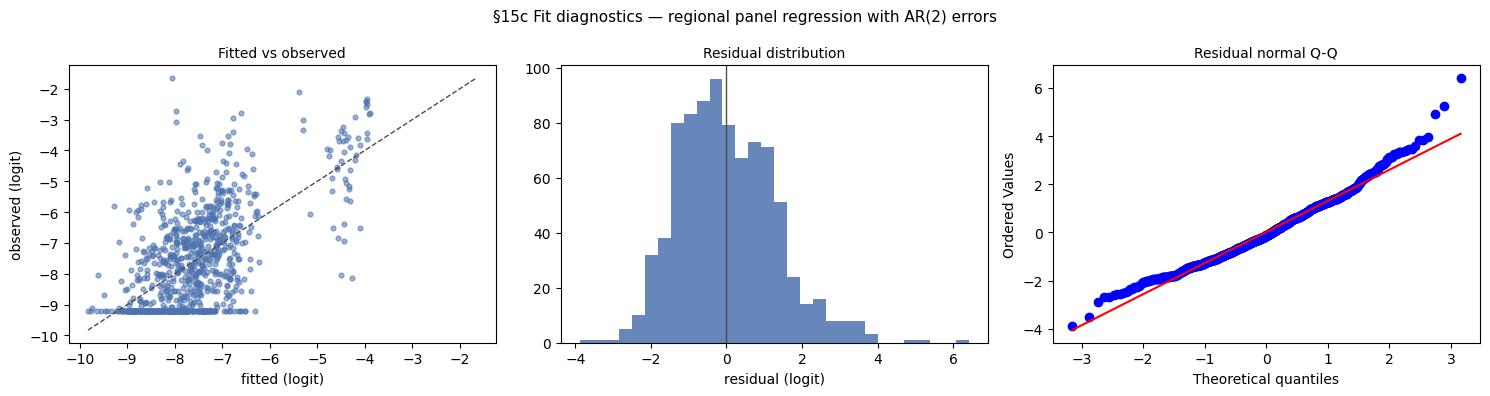

,statistic,observed,fitted,difference
0,mean,-7.537180,-7.555317,-0.018136
1,sd,1.636425,1.039623,-0.596801
2,min,-9.210240,-9.825964,-0.615723
3,max,-1.652852,-3.890695,-2.237843


R-squared (quasi-differenced scale): 0.228; residual SD (level scale): 1.301 logit units.


In [34]:
# =====================================================================
# 15c. Fitted-vs-observed, and the residual distribution
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
_obs = RESID_FRAME.dropna(subset=["resid"])
axes[0].scatter(_obs["eta"], _obs["y"], s=12, alpha=0.55, color="#4C72B0")
_lim = [min(_obs["eta"].min(), _obs["y"].min()),
        max(_obs["eta"].max(), _obs["y"].max())]
axes[0].plot(_lim, _lim, color="0.3", lw=1, ls="--")
axes[0].set_xlabel("fitted (logit)")
axes[0].set_ylabel("observed (logit)")
axes[0].set_title("Fitted vs observed", fontsize=10)
axes[1].hist(_obs["resid"], bins=30, color="#4C72B0", alpha=0.85)
axes[1].axvline(0, color="0.3", lw=1)
axes[1].set_xlabel("residual (logit)")
axes[1].set_title("Residual distribution", fontsize=10)
sstats.probplot(_obs["resid"].to_numpy(), dist="norm", plot=axes[2])
axes[2].set_title("Residual normal Q-Q", fontsize=10)
fig.suptitle("§15c Fit diagnostics — regional panel regression with "
             f"AR({SELECTED_AR_ORDER}) errors", fontsize=11)
fig.tight_layout()
plt.show()

PPC_TABLE = pd.DataFrame([
    {"statistic": "mean", "observed": float(_obs["y"].mean()),
     "fitted": float(_obs["eta"].mean())},
    {"statistic": "sd", "observed": float(_obs["y"].std(ddof=1)),
     "fitted": float(_obs["eta"].std(ddof=1))},
    {"statistic": "min", "observed": float(_obs["y"].min()),
     "fitted": float(_obs["eta"].min())},
    {"statistic": "max", "observed": float(_obs["y"].max()),
     "fitted": float(_obs["eta"].max())}])
PPC_TABLE["difference"] = PPC_TABLE["fitted"] - PPC_TABLE["observed"]
display(PPC_TABLE)
register("fit_summary_statistics", PPC_TABLE, "diagnostic")
print(f"R-squared (quasi-differenced scale): "
      f"{float(FIT_FULL['result'].rsquared):.3f}; "
      f"residual SD (level scale): {float(np.nanstd(FIT_FULL['resid_level'])):.3f} "
      "logit units.")


## 16. Driver associations

Four things are reported for every driver, and the verdict uses all of them:

1. the **estimate** on the standardised-logit scale — a 1 SD move in the driver
   shifts the log-odds of regional cover by this much;
2. the **month-clustered confidence interval**;
3. whether that interval clears the **ROPE**, the band around zero
   ($\pm$`ROPE_HALFWIDTH`) inside which an association is too small to be
   ecologically interesting at this sample size;
4. whether the sign matches the **predeclared** expectation from §3e.

A verdict of `supported` requires the interval to exclude zero **and** to lie
outside the ROPE. `suggestive` means it excludes zero but sits inside the ROPE —
detectable but small. Everything else is `not supported`, and if §15's gate
failed, everything is `not reportable` regardless of how the numbers look.

**The sample size that matters.** Every interval here comes from a covariance
clustered on calendar month. For a driver with one gulf-wide value per month
that is the honest $n$: the
`temporal_only` drivers are replicated across regions but not across
independent observations, and clustering is what stops the region-months from
being counted as though they were.


In [35]:
# =====================================================================
# 16a. Global driver associations
# =====================================================================
_terms = [t for t in MODEL_DATA["driver_terms"] if t in FIT_FULL["names"]]
_meta = {r["term"]: r for r in DRIVER_META.to_dict("records")}
_sl = {c: lab for c, lab in zip(DRIVER_VARIANCE["driver"],
                                DRIVER_VARIANCE["spatial_label"])}

GLOBAL_DRIVERS = coef_frame(FIT_FULL, terms=_terms)
GLOBAL_DRIVERS["mechanism"] = [_meta.get(t, {}).get("mechanism", "")
                               for t in GLOBAL_DRIVERS["term"]]
GLOBAL_DRIVERS["expected_sign"] = [_meta.get(t, {}).get("expected_sign", "?")
                                   for t in GLOBAL_DRIVERS["term"]]
GLOBAL_DRIVERS["spatial_label"] = [
    _sl.get(_meta.get(t, {}).get("column"), "undetermined")
    for t in GLOBAL_DRIVERS["term"]]
GLOBAL_DRIVERS["ci_excludes_zero"] = (
    (GLOBAL_DRIVERS["ci_lo"] > 0) | (GLOBAL_DRIVERS["ci_hi"] < 0))
GLOBAL_DRIVERS["outside_rope"] = (
    (GLOBAL_DRIVERS["ci_lo"] > ROPE_HALFWIDTH)
    | (GLOBAL_DRIVERS["ci_hi"] < -ROPE_HALFWIDTH))
GLOBAL_DRIVERS["sign_matches_expected"] = [
    (s == "?") or (s == "+" and e > 0) or (s == "-" and e < 0)
    for s, e in zip(GLOBAL_DRIVERS["expected_sign"], GLOBAL_DRIVERS["estimate"])]


def _verdict(row):
    if not GATE_PASSED:
        return "not reportable", "the final fit did not clear §15's diagnostic gate"
    if row["ci_excludes_zero"] and row["outside_rope"]:
        return "supported", (f"{int(HDI_PROB * 100)}% CI excludes zero and lies "
                             f"outside the ROPE (|beta| < {ROPE_HALFWIDTH})")
    if row["ci_excludes_zero"]:
        return "suggestive", ("CI excludes zero but lies inside the ROPE: "
                              "detectable, too small to be ecologically "
                              "interesting at this sample size")
    return "not supported", f"the {int(HDI_PROB * 100)}% CI includes zero"


GLOBAL_DRIVERS[["verdict", "verdict_reason"]] = [
    _verdict(r) for _, r in GLOBAL_DRIVERS.iterrows()]
GLOBAL_DRIVERS = GLOBAL_DRIVERS[[
    "term", "mechanism", "spatial_label", "expected_sign", "estimate", "se",
    "ci_lo", "ci_hi", "t", "p_value", "ci_excludes_zero", "outside_rope",
    "sign_matches_expected", "verdict", "verdict_reason"]]
display(GLOBAL_DRIVERS.drop(columns=["mechanism", "verdict_reason"]))
register("global_driver_associations", GLOBAL_DRIVERS,
         "environmental association")

print(f"Scale: standardised logit. An estimate of 0.10 means a 1 SD move in the "
      "driver shifts the log-odds of regional cover by 0.10 (odds x 1.105).")
print(f"ROPE: |beta| < {ROPE_HALFWIDTH} is practically equivalent to zero.")
print(f"Standard errors are clustered on calendar month: "
      f"{FIT_FULL['n_clusters']} clusters over {FIT_FULL['n_obs']} region-months.")
_sup = GLOBAL_DRIVERS[GLOBAL_DRIVERS["verdict"] == "supported"]
_sug = GLOBAL_DRIVERS[GLOBAL_DRIVERS["verdict"] == "suggestive"]
print(f"\nSupported: {_sup['term'].tolist() or 'NONE'}")
print(f"Suggestive: {_sug['term'].tolist() or 'none'}")
if not GATE_PASSED:
    print("*** ...but §15's gate failed, so every verdict above reads "
          "'not reportable'. ***")

# No region-varying slopes are estimated in this specification.
REGIONAL_DRIVERS = pd.DataFrame()
register("regional_driver_associations", REGIONAL_DRIVERS,
         "environmental association")
print("\nNo region-specific slope was estimated: §10c allowed no random slope, "
      "so every driver enters with a common gulf-wide coefficient.")


,term,spatial_label,expected_sign,estimate,se,ci_lo,ci_hi,t,p_value,ci_excludes_zero,outside_rope,sign_matches_expected,verdict
0,rain_chirps_30d_mm_lag1,temporal_only,+,-0.104592,0.081051,-0.263449,0.054264,-1.290455,0.196893,False,False,False,not reportable
1,air_temp_c,temporal_only,+,0.030765,0.153578,-0.270242,0.331773,0.200324,0.841227,False,False,True,not reportable
2,wind_speed_ms,temporal_only,?,-0.060711,0.359186,-0.764703,0.643281,-0.169025,0.865777,False,False,True,not reportable
3,wave_exposure_idx,spatiotemporal,-,-0.055243,0.265142,-0.574912,0.464425,-0.208354,0.834952,False,False,True,not reportable
4,lake_level_m,temporal_only,-,0.306509,0.155351,0.002027,0.610991,1.973009,0.048495,True,False,False,not reportable


Scale: standardised logit. An estimate of 0.10 means a 1 SD move in the driver shifts the log-odds of regional cover by 0.10 (odds x 1.105).
ROPE: |beta| < 0.05 is practically equivalent to zero.
Standard errors are clustered on calendar month: 51 clusters over 860 region-months.

Supported: NONE
Suggestive: none
*** ...but §15's gate failed, so every verdict above reads 'not reportable'. ***

No region-specific slope was estimated: §10c allowed no random slope, so every driver enters with a common gulf-wide coefficient.


In [36]:
# =====================================================================
# 16b. The region intercepts, reported descriptively
# =====================================================================
# These are FIXED effects, not draws from a fitted population distribution. Their
# spread describes the regions in this record; it is not an estimate of
# between-region heterogeneity in some wider population, and §22 says so.
_alpha_terms = [n for n in FIT_FULL["names"] if n.startswith("alpha[")]
REGION_INTERCEPTS = coef_frame(FIT_FULL, terms=_alpha_terms)
REGION_INTERCEPTS["region_id"] = [t[6:-1] for t in REGION_INTERCEPTS["term"]]
REGION_INTERCEPTS = REGION_INTERCEPTS.merge(
    REGIONS[["region_id", "region_name", "region_type", "eligible_area_ha"]],
    on="region_id", how="left").sort_values("estimate", ascending=False)
display(REGION_INTERCEPTS[["region_id", "region_name", "region_type",
                           "estimate", "se", "ci_lo", "ci_hi"]])
register("region_intercepts", REGION_INTERCEPTS, "regional")
print(f"Spread of the region intercepts: SD = "
      f"{float(REGION_INTERCEPTS['estimate'].std(ddof=1)):.3f} logit units, "
      f"range {float(REGION_INTERCEPTS['estimate'].min()):.2f} to "
      f"{float(REGION_INTERCEPTS['estimate'].max()):.2f}.")
print("  These are fixed effects. The spread DESCRIBES the regions in this "
      "record; it is not a variance component and must not be read as one.")

_by_type = (REGION_INTERCEPTS.groupby("region_type")
            .agg(n_regions=("region_id", "size"),
                 mean_intercept=("estimate", "mean"),
                 sd_intercept=("estimate", "std")).reset_index())
display(_by_type)
register("region_intercepts_by_type", _by_type, "regional")


,region_id,region_name,region_type,estimate,se,ci_lo,ci_hi
0,R01,River-influenced bay (E),river_influenced_bay,-4.453288,0.270091,-4.982656,-3.923921
6,R07,Sheltered littoral (NW),sheltered_littoral,-6.901347,0.398839,-7.683057,-6.119636
4,R05,Sheltered littoral (S),sheltered_littoral,-6.943737,0.396576,-7.721012,-6.166463
5,R06,Sheltered littoral (NE),sheltered_littoral,-7.148196,0.420415,-7.972194,-6.324199
1,R02,River-influenced bay (SW),river_influenced_bay,-7.332637,0.273885,-7.869442,-6.795833
7,R08,Sheltered littoral (N),sheltered_littoral,-7.389849,0.331039,-8.038673,-6.741025
8,R09,Sheltered littoral (W),sheltered_littoral,-7.453636,0.378715,-8.195905,-6.711368
15,R16,Open gulf (central),open_gulf,-7.543346,0.389288,-8.306336,-6.780356
10,R11,Exposed littoral (W),exposed_littoral,-7.716780,0.303311,-8.311259,-7.122301
2,R03,River-influenced bay (N),river_influenced_bay,-7.846127,0.306040,-8.445954,-7.246299


Spread of the region intercepts: SD = 1.000 logit units, range -8.90 to -4.45.
  These are fixed effects. The spread DESCRIBES the regions in this record; it is not a variance component and must not be read as one.


,region_type,n_regions,mean_intercept,sd_intercept
0,exposed_littoral,5,-8.122830,0.315218
1,open_gulf,2,-8.112270,0.804580
2,river_influenced_bay,4,-7.133865,1.902945
3,sheltered_littoral,6,-7.305228,0.405679


,region_type,n_regions,mean_intercept,sd_intercept
0,exposed_littoral,5,-8.122830,0.315218
1,open_gulf,2,-8.112270,0.804580
2,river_influenced_bay,4,-7.133865,1.902945
3,sheltered_littoral,6,-7.305228,0.405679


In [37]:
# =====================================================================
# 16c. The endogenous optical proxies — descriptive only
# =====================================================================
PROXY_ASSOCIATION = pd.DataFrame()
if PROXY_COLS:
    _rows = []
    _obs_rm = REGION_MONTH[REGION_MONTH["observed"]].copy()
    for _c in PROXY_COLS:
        if _c not in _obs_rm.columns:
            continue
        _sub = _obs_rm[["region_id", "month", "y", _c]].dropna()
        if len(_sub) < 10:
            continue
        # within-region, within-month: remove both means before correlating
        _sub["_x"] = (_sub[_c] - _sub.groupby("region_id")[_c].transform("mean")
                      - _sub.groupby("month")[_c].transform("mean")
                      + _sub[_c].mean())
        _sub["_y"] = (_sub["y"] - _sub.groupby("region_id")["y"].transform("mean")
                      - _sub.groupby("month")["y"].transform("mean")
                      + _sub["y"].mean())
        if _sub["_x"].std(ddof=0) == 0 or _sub["_y"].std(ddof=0) == 0:
            _r = _p = np.nan
        else:
            _r, _p = sstats.pearsonr(_sub["_x"], _sub["_y"])
        _rows.append({"proxy": _c, "n_region_months": int(len(_sub)),
                      "partial_pearson_r": float(_r), "p_value": float(_p),
                      "interpretation": ("DESCRIPTIVE ONLY — endogenous to WH; "
                                         "not a driver claim")})
    PROXY_ASSOCIATION = pd.DataFrame(_rows)
    if len(PROXY_ASSOCIATION):
        display(PROXY_ASSOCIATION)
        register("endogenous_proxy_association", PROXY_ASSOCIATION, "descriptive")
    print("These are correlations between WH cover and quantities measured from "
          "the same pixels. They are reported for completeness and excluded "
          "from every driver conclusion.")


,proxy,n_region_months,partial_pearson_r,p_value,interpretation
0,chl_mci_s3,1347,-0.002507,0.926751,DESCRIPTIVE ONLY — endogenous to WH; not a dri...
1,chl_mph_s3,1347,0.002277,0.933466,DESCRIPTIVE ONLY — endogenous to WH; not a dri...
2,turb_ndti_s2,1347,0.080130,0.003252,DESCRIPTIVE ONLY — endogenous to WH; not a dri...


These are correlations between WH cover and quantities measured from the same pixels. They are reported for completeness and excluded from every driver conclusion.


## 17. Temporal validation — expanding window, **one calendar month ahead**

AICc and an F-test score fit. This scores **forecasts**, and it is the comparison
that settles whether the drivers earn their place.

At each origin month $T_0$ the model is **refitted from scratch** on months
$\le T_0$ only — its own AR coefficients, its own regression coefficients, its
own driver standardisation — and asked for month $T_0+1$. Because each fit takes
milliseconds rather than hours, **every feasible origin is used**; there is no
cap to justify and no question of a cap landing in one season.

### What is never allowed to leak

* **No driver value dated at or after the target month.** Contemporaneous
  temperature, wind and lake level are moved to **lag 1** for this evaluation,
  because their same-month value is not knowable at the origin. Every forecast
  driver's lag is asserted $\ge$ `VAL_FORECAST_MIN_LAG`. The a-priori (lag-0)
  specification is retained unchanged for §14/§16 — nowcasting and forecasting
  are different questions and are never merged.
* **The AR term is projected, not peeked at.** The forecast error correction is
  $\sum_j \hat\rho_j \hat e_{r,T_0+1-j}$, using residuals from training months
  only. Where a required residual falls in an excluded month it contributes
  zero, and the count is reported.
* **The scaler is refitted per fold**, on training rows only.

### What it is compared against

| Baseline | Definition | Fitted? |
|---|---|---|
| literal region persistence | $\hat y_{r,t}=y_{r,t-1}$ at exactly $t-1$ calendar months | **no** |
| seasonal naïve | $\hat y_{r,t}=y_{r,t-12}$ by calendar timestamp | **no** |
| `regional_dynamic_null` | the panel regression with no driver | yes |
| `regional_dynamic_full` | the same plus the driver block | yes |

### How performance is reported

Region-macro RMSE/MAE (every region weighted equally, so a big region cannot
carry the score), valid-area-weighted RMSE/MAE, a breakdown by ecological region
type, and both the logit and the back-transformed cover scale.

**The resampling unit for uncertainty is the calendar month, not the
region-month.** Regions observed in the same month share weather, share the lake
and share a satellite pass; treating them as independent replicates would shrink
every interval by roughly $\sqrt{R}$ for no reason.


In [38]:
# =====================================================================
# 17a. The forecast driver set — origin-time information only
# =====================================================================
FORECAST_SPECS = pd.DataFrame()
FC_TERMS, X_FC_RAW = [], np.zeros((R, T, 0))

if FIT_FULL is not None:
    _terms_used = MODEL_DATA["driver_terms"]
    _rows, _arrs = [], []
    for base, meta in FORCING.items():
        term = f"{base}_lag{meta['apriori_lag']}" if meta["apriori_lag"] else base
        if term not in _terms_used:
            continue
        ap = int(meta["apriori_lag"])
        lag = max(ap, int(VAL_FORECAST_MIN_LAG))
        name = f"fc_{base}_lag{lag}"
        arr = np.full((R, T), np.nan)
        for rid, i in R_IDX.items():
            s = (REGION_MONTH[REGION_MONTH["region_id"] == rid]
                 .set_index("month").reindex(MONTH_GRID)[meta["column"]])
            arr[i, :] = s.shift(lag).to_numpy()
        _arrs.append(arr)
        FC_TERMS.append(name)
        _rows.append({"driver": base, "inference_term": term,
                      "apriori_lag": ap, "forecast_lag": lag,
                      "forecast_term": name, "source_column": meta["column"],
                      "note": ("a-priori lag is already knowable at the origin"
                               if ap >= VAL_FORECAST_MIN_LAG
                               else f"lag {ap} is NOT knowable at the origin -> "
                                    f"moved to lag {lag} for forecasting only")})
    FORECAST_SPECS = pd.DataFrame(_rows)
    X_FC_RAW = (np.stack(_arrs, axis=2) if _arrs else np.zeros((R, T, 0)))
    display(FORECAST_SPECS)
    register("forecast_driver_specs", FORECAST_SPECS, "provenance")
    assert all(int(v) >= int(VAL_FORECAST_MIN_LAG)
               for v in FORECAST_SPECS["forecast_lag"]), \
        "a forecast driver would use information dated at or after the target month"
    _moved = FORECAST_SPECS[FORECAST_SPECS["forecast_lag"]
                            > FORECAST_SPECS["apriori_lag"]]
    if len(_moved):
        print(f"{len(_moved)} contemporaneous driver(s) moved to lag 1 for the "
              f"forecast evaluation: {_moved['driver'].tolist()}")


,driver,inference_term,apriori_lag,forecast_lag,forecast_term,source_column,note
0,rain_chirps_30d_mm,rain_chirps_30d_mm_lag1,1,1,fc_rain_chirps_30d_mm_lag1,rain_chirps_30d_mm,a-priori lag is already knowable at the origin
1,air_temp_c,air_temp_c,0,1,fc_air_temp_c_lag1,air_temp_c,lag 0 is NOT knowable at the origin -> moved t...
2,wind_speed_ms,wind_speed_ms,0,1,fc_wind_speed_ms_lag1,wind_speed_ms,lag 0 is NOT knowable at the origin -> moved t...
3,wave_exposure_idx,wave_exposure_idx,0,1,fc_wave_exposure_idx_lag1,wave_exposure_idx,lag 0 is NOT knowable at the origin -> moved t...
4,lake_level_m,lake_level_m,0,1,fc_lake_level_m_lag1,lake_level_m,lag 0 is NOT knowable at the origin -> moved t...


4 contemporaneous driver(s) moved to lag 1 for the forecast evaluation: ['air_temp_c', 'wind_speed_ms', 'wave_exposure_idx', 'lake_level_m']


In [39]:
# =====================================================================
# 17b. Rolling origin, refit from scratch at every origin
# =====================================================================
VAL_FOLD_AUDIT = pd.DataFrame()
VAL_PREDICTIONS = pd.DataFrame()
VAL_SCALER_AUDIT = pd.DataFrame()


def forecast_one_month(fit, data_fc, region_ids, tgt, x_next_std, ar_order):
    """One-calendar-month-ahead prediction for every region, on the logit scale.

    eta = alpha_r + season_t + trend_t + x'beta + sum_j rho_j * resid[r, t-j],
    with the residual terms taken from TRAINING months only.
    """
    par = fit["params"]
    eta = np.full(len(region_ids), np.nan)
    ar_used = np.zeros(len(region_ids), dtype=int)
    S = np.asarray(data_fc["season"], dtype=float)[tgt, :]
    tt = float(np.asarray(data_fc["tt"], dtype=float)[tgt])
    resid_map = fit.get("resid_by_region_time", {})
    for i, rid in enumerate(region_ids):
        key = f"alpha[{rid}]"
        if key not in par.index:
            continue
        v = float(par[key])
        for j in range(S.shape[0] if S.ndim else 0):
            nm = f"season[s{j}]"
            if nm in par.index:
                v += float(par[nm]) * float(S[j])
        if "trend" in par.index:
            v += float(par["trend"]) * tt
        for k, term in enumerate(fit.get("forecast_terms", [])):
            if term in par.index and np.isfinite(x_next_std[i, k]):
                v += float(par[term]) * float(x_next_std[i, k])
        for j, rj in enumerate(np.atleast_1d(fit["rho"]), start=1):
            e = resid_map.get((i, int(tgt) - j))
            if e is not None and np.isfinite(e):
                v += float(rj) * float(e)
                ar_used[i] += 1
        eta[i] = v
    return eta, ar_used


if FIT_FULL is not None and len(FC_TERMS):
    _y_ok = np.isfinite(Y_RAW)
    _fc_ok = np.all(np.isfinite(X_FC_RAW), axis=2)
    _obs_fc = _y_ok & _fc_ok
    _obs_per_month = _obs_fc.sum(axis=0)
    _cum_obs_months = np.cumsum(_obs_per_month > 0)
    _feasible = [o for o in range(T - 1)
                 if _cum_obs_months[o] >= VAL_MIN_TRAIN_MONTHS
                 and _obs_fc[:, o + 1].any()]
    if VAL_MAX_ORIGINS is not None and len(_feasible) > int(VAL_MAX_ORIGINS):
        _pick = np.linspace(0, len(_feasible) - 1, int(VAL_MAX_ORIGINS))
        _feasible = [_feasible[int(round(i))] for i in _pick]
    print(f"Rolling-origin folds: {len(_feasible)} origin(s)"
          + ("" if VAL_MAX_ORIGINS is None
             else f" (capped by VAL_MAX_ORIGINS={VAL_MAX_ORIGINS})"))

    _fold_rows, _pred_rows, _scale_rows = [], [], []
    for _fold, o in enumerate(_feasible):
        tgt = o + 1
        mask_tr = _obs_fc.copy()
        mask_tr[:, o + 1:] = False
        if int(mask_tr.sum()) < VAL_MIN_TRAIN_ROWS:
            _fold_rows.append({"fold": _fold, "origin_month": MONTH_GRID[o],
                               "target_month": MONTH_GRID[tgt], "usable": False,
                               "skip_reason": "too few training region-months"})
            continue
        # --- per-fold standardisation, training rows only -------------------
        Xs = np.zeros_like(X_FC_RAW)
        for k, term in enumerate(FC_TERMS):
            v = X_FC_RAW[:, :, k][mask_tr]
            mu = float(np.nanmean(v)) if np.isfinite(v).any() else 0.0
            sd = float(np.nanstd(v)) if np.isfinite(v).any() else 1.0
            sd = sd if sd > 0 else 1.0
            Xs[:, :, k] = (X_FC_RAW[:, :, k] - mu) / sd
            _scale_rows.append({"fold": _fold, "origin_month": MONTH_GRID[o],
                                "term": term, "mean": mu, "sd": sd,
                                "scope": "training rows only"})
        Xs = np.where(np.isfinite(Xs), Xs, 0.0)

        _t0 = time.time()
        _fits = {}
        for _which, _drv in (("null", False), ("full", True)):
            _d = make_model_data(Xs, Y_RAW, mask_tr, SEASON, TT, REGION_IDS,
                                 FC_TERMS, random_slope_terms=[])
            _rows_f, _lagx_f = ar_estimation_rows(_d["obs_r"], _d["obs_t"],
                                                  AR_MAX_LAGS)
            if int(_rows_f.sum()) < VAL_MIN_TRAIN_ROWS:
                _fits = {}
                break
            _f = fit_panel_ar(_d, p=SELECTED_AR_ORDER, drivers=_drv,
                              include_trend=INCLUDE_TREND, rows=_rows_f,
                              lag_index=_lagx_f, label=f"fold{_fold}_{_which}")
            _f["forecast_terms"] = FC_TERMS if _drv else []
            _f["resid_by_region_time"] = {
                (int(r), int(t)): float(e)
                for r, t, e in zip(_d["obs_r"], _d["obs_t"], _f["resid_level"])
                if np.isfinite(e)}
            _fits[_which] = _f
        if not _fits:
            _fold_rows.append({"fold": _fold, "origin_month": MONTH_GRID[o],
                               "target_month": MONTH_GRID[tgt], "usable": False,
                               "skip_reason": "too few rows with the AR lags"})
            continue

        _dfc = {"season": SEASON, "tt": TT}
        eta_n, _ = forecast_one_month(_fits["null"], _dfc, REGION_IDS, tgt,
                                      Xs[:, tgt, :], SELECTED_AR_ORDER)
        eta_f, ar_used = forecast_one_month(_fits["full"], _dfc, REGION_IDS, tgt,
                                            Xs[:, tgt, :], SELECTED_AR_ORDER)
        for ri, rid in enumerate(REGION_IDS):
            if not _obs_fc[ri, tgt]:
                continue
            pers = Y_RAW[ri, tgt - 1] if tgt - 1 >= 0 else np.nan
            seas = Y_RAW[ri, tgt - 12] if tgt - 12 >= 0 else np.nan
            _pred_rows.append({
                "fold": _fold, "origin_month": MONTH_GRID[o],
                "target_month": MONTH_GRID[tgt], "region_id": rid,
                "y_true": float(Y_RAW[ri, tgt]),
                "valid_area_ha": float(VALID_AREA[ri, tgt]),
                "pred_null": float(eta_n[ri]), "pred_full": float(eta_f[ri]),
                "pred_persistence": float(pers) if np.isfinite(pers) else np.nan,
                "pred_seasonal_naive": float(seas) if np.isfinite(seas) else np.nan,
                "ar_terms_available": int(ar_used[ri]),
                "drivers_complete": bool(np.all(np.isfinite(Xs[ri, tgt, :]))),
            })
        _fold_rows.append({
            "fold": _fold, "origin_month": MONTH_GRID[o],
            "target_month": MONTH_GRID[tgt], "usable": True,
            "n_training_region_months": int(mask_tr.sum()),
            "n_training_months": int((mask_tr.sum(axis=0) > 0).sum()),
            "n_target_regions": int(_obs_fc[:, tgt].sum()),
            "ar_order": SELECTED_AR_ORDER,
            "seconds": round(time.time() - _t0, 3), "skip_reason": ""})

    VAL_FOLD_AUDIT = pd.DataFrame(_fold_rows)
    VAL_PREDICTIONS = pd.DataFrame(_pred_rows)
    VAL_SCALER_AUDIT = pd.DataFrame(_scale_rows)
    if len(VAL_PREDICTIONS):
        VAL_PREDICTIONS = VAL_PREDICTIONS.merge(
            REGIONS[["region_id", "region_name", "region_type"]],
            on="region_id", how="left")
    display(VAL_FOLD_AUDIT.head(12))
    register("temporal_validation_fold_audit", VAL_FOLD_AUDIT, "validation")
    register("temporal_validation_predictions", VAL_PREDICTIONS, "validation")
    register("temporal_validation_scaler_audit", VAL_SCALER_AUDIT, "provenance")
    _use = VAL_FOLD_AUDIT[VAL_FOLD_AUDIT["usable"]] if len(VAL_FOLD_AUDIT) \
        else VAL_FOLD_AUDIT
    print(f"\n{len(VAL_PREDICTIONS):,} held-out region-month prediction(s) over "
          f"{VAL_PREDICTIONS['target_month'].nunique() if len(VAL_PREDICTIONS) else 0} "
          f"target month(s), from {len(_use)} usable fold(s) in "
          f"{float(_use['seconds'].sum()) if len(_use) else 0:.1f}s total.")
    print("These are genuine out-of-sample forecasts: every model was refitted "
          "from scratch on strictly earlier months, with its own scaling and its "
          "own AR coefficients.")
else:
    print("§17 skipped (no fitted model, or no forecastable driver).")


Rolling-origin folds: 29 origin(s)


,fold,origin_month,target_month,usable,n_training_region_months,n_training_months,n_target_regions,ar_order,seconds,skip_reason
0,0,2023-01-01,2023-02-01,True,605,36,17,2,0.054,
1,1,2023-02-01,2023-03-01,True,622,37,17,2,0.082,
2,2,2023-07-01,2023-08-01,True,639,38,17,2,0.068,
3,3,2023-08-01,2023-09-01,True,656,39,17,2,0.067,
4,4,2023-09-01,2023-10-01,True,673,40,17,2,0.070,
5,5,2023-10-01,2023-11-01,True,690,41,17,2,0.065,
6,6,2023-11-01,2023-12-01,True,707,42,17,2,0.070,
7,7,2023-12-01,2024-01-01,True,724,43,17,2,0.068,
8,8,2024-03-01,2024-04-01,True,741,44,17,2,0.067,
9,9,2024-06-01,2024-07-01,True,758,45,17,2,0.067,



493 held-out region-month prediction(s) over 29 target month(s), from 29 usable fold(s) in 2.0s total.
These are genuine out-of-sample forecasts: every model was refitted from scratch on strictly earlier months, with its own scaling and its own AR coefficients.


In [40]:
# =====================================================================
# 17c. Skill, by region and by ecological class, on both scales
# =====================================================================
VAL_METRICS = pd.DataFrame()
VAL_METRICS_BY_TYPE = pd.DataFrame()
VAL_RMSE_DIFF = pd.DataFrame()
MODEL_COLS = {"persistence": "pred_persistence",
              "seasonal_naive": "pred_seasonal_naive",
              "regional_dynamic_null": "pred_null",
              "regional_dynamic_full": "pred_full"}


def _rmse(a, b, w=None):
    a, b = np.asarray(a, float), np.asarray(b, float)
    ok = np.isfinite(a) & np.isfinite(b)
    if not ok.any():
        return np.nan
    if w is None:
        return float(np.sqrt(np.mean((a[ok] - b[ok]) ** 2)))
    w = np.asarray(w, float)[ok]
    w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
    if w.sum() <= 0:
        return np.nan
    return float(np.sqrt(np.sum(w * (a[ok] - b[ok]) ** 2) / w.sum()))


def _mae(a, b, w=None):
    a, b = np.asarray(a, float), np.asarray(b, float)
    ok = np.isfinite(a) & np.isfinite(b)
    if not ok.any():
        return np.nan
    if w is None:
        return float(np.mean(np.abs(a[ok] - b[ok])))
    w = np.asarray(w, float)[ok]
    w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
    if w.sum() <= 0:
        return np.nan
    return float(np.sum(w * np.abs(a[ok] - b[ok])) / w.sum())


def skill_table(pred, cols=None, restrict_common=True):
    """RMSE/MAE per model, pooled, region-macro and area-weighted."""
    cols = MODEL_COLS if cols is None else cols
    if not len(pred):
        return pd.DataFrame()
    df = pred.copy()
    if restrict_common:
        ok = np.ones(len(df), dtype=bool)
        for c in cols.values():
            ok &= np.isfinite(df[c].to_numpy(dtype=float))
        df = df[ok]
    rows = []
    for name, col in cols.items():
        sub = df.dropna(subset=[col, "y_true"])
        if not len(sub):
            continue
        macro = [(_rmse(g["y_true"], g[col]), _mae(g["y_true"], g[col]))
                 for _, g in sub.groupby("region_id")]
        rows.append({
            "model": name, "n_predictions": int(len(sub)),
            "n_regions": int(sub["region_id"].nunique()),
            "n_target_months": int(sub["target_month"].nunique()),
            "rmse_logit_pooled": _rmse(sub["y_true"], sub[col]),
            "mae_logit_pooled": _mae(sub["y_true"], sub[col]),
            "rmse_logit_region_macro": float(np.nanmean([m[0] for m in macro])),
            "mae_logit_region_macro": float(np.nanmean([m[1] for m in macro])),
            "rmse_logit_area_weighted": _rmse(sub["y_true"], sub[col],
                                              sub["valid_area_ha"]),
            "mae_logit_area_weighted": _mae(sub["y_true"], sub[col],
                                            sub["valid_area_ha"]),
            "rmse_cover": _rmse(inverse_transform_response(sub["y_true"].to_numpy(), RESPONSE_TRANSFORM, RESPONSE_EPS),
                                inverse_transform_response(sub[col].to_numpy(), RESPONSE_TRANSFORM, RESPONSE_EPS)),
            "mae_cover": _mae(inverse_transform_response(sub["y_true"].to_numpy(), RESPONSE_TRANSFORM, RESPONSE_EPS),
                              inverse_transform_response(sub[col].to_numpy(), RESPONSE_TRANSFORM, RESPONSE_EPS)),
            "common_sample": bool(restrict_common)})
    return (pd.DataFrame(rows).sort_values("rmse_logit_pooled")
            .reset_index(drop=True) if rows else pd.DataFrame())


if len(VAL_PREDICTIONS):
    VAL_METRICS = pd.concat([skill_table(VAL_PREDICTIONS, restrict_common=True),
                             skill_table(VAL_PREDICTIONS, restrict_common=False)],
                            ignore_index=True)
    display(VAL_METRICS)
    register("temporal_validation_metrics", VAL_METRICS, "validation")
    print("`common_sample = True` is the like-for-like table: only target "
          "region-months every model could predict.")

    _rows = []
    for rtype, g in VAL_PREDICTIONS.groupby("region_type"):
        t = skill_table(g, restrict_common=True)
        if len(t):
            t.insert(0, "region_type", rtype)
            _rows.append(t)
    VAL_METRICS_BY_TYPE = (pd.concat(_rows, ignore_index=True) if _rows
                           else pd.DataFrame())
    if len(VAL_METRICS_BY_TYPE):
        display(VAL_METRICS_BY_TYPE[["region_type", "model", "n_predictions",
                                     "rmse_logit_region_macro", "rmse_cover"]])
        register("temporal_validation_metrics_by_region_type",
                 VAL_METRICS_BY_TYPE, "validation")

    # --- paired bootstrap, resampling CALENDAR MONTHS -----------------------
    _cs = VAL_PREDICTIONS.copy()
    _ok = np.ones(len(_cs), dtype=bool)
    for _c in MODEL_COLS.values():
        _ok &= np.isfinite(_cs[_c].to_numpy(dtype=float))
    _cs = _cs[_ok]
    _months = sorted(_cs["target_month"].unique())
    if len(_months) >= VAL_MIN_BOOTSTRAP_MONTHS:
        _rng = np.random.default_rng(RANDOM_STATE)
        _pairs = [("regional_dynamic_full", "regional_dynamic_null"),
                  ("regional_dynamic_full", "persistence"),
                  ("regional_dynamic_full", "seasonal_naive")]
        # Row indices grouped by calendar month, so a bootstrap draw is an
        # array gather rather than 2000 DataFrame filters.
        _by_month = [np.flatnonzero((_cs["target_month"] == m).to_numpy())
                     for m in _months]
        _yt = _cs["y_true"].to_numpy(dtype=float)
        _rows = []
        for _a, _b in _pairs:
            _ca, _cb = MODEL_COLS[_a], MODEL_COLS[_b]
            _pa = _cs[_ca].to_numpy(dtype=float)
            _pb = _cs[_cb].to_numpy(dtype=float)
            _obs = (_rmse(_yt, _pa) - _rmse(_yt, _pb))
            _draws = np.empty(int(VAL_BOOTSTRAP_DRAWS))
            for _d in range(int(VAL_BOOTSTRAP_DRAWS)):
                _pick = _rng.integers(0, len(_months), size=len(_months))
                _ix = np.concatenate([_by_month[j] for j in _pick])
                _draws[_d] = (np.sqrt(np.mean((_yt[_ix] - _pa[_ix]) ** 2))
                              - np.sqrt(np.mean((_yt[_ix] - _pb[_ix]) ** 2)))
            _lo, _hi = np.nanpercentile(_draws, [2.5, 97.5])
            _rows.append({
                "model_a": _a, "model_b": _b,
                "rmse_difference_a_minus_b": float(_obs),
                "ci95_lo": float(_lo), "ci95_hi": float(_hi),
                "n_target_months_resampled": int(len(_months)),
                "resampling_unit": "calendar month (regions within a month move together)",
                "a_better_and_interval_excludes_zero": bool(_obs < 0 and _hi < 0)})
        VAL_RMSE_DIFF = pd.DataFrame(_rows)
        display(VAL_RMSE_DIFF)
        register("temporal_validation_rmse_differences", VAL_RMSE_DIFF,
                 "validation")
        for r in VAL_RMSE_DIFF.itertuples():
            print(f"{r.model_a} vs {r.model_b}: RMSE difference "
                  f"{r.rmse_difference_a_minus_b:+.4f} logit "
                  f"[{r.ci95_lo:+.4f}, {r.ci95_hi:+.4f}] over "
                  f"{r.n_target_months_resampled} calendar months -> "
                  + ("a genuine improvement" if r.a_better_and_interval_excludes_zero
                     else "NOT a demonstrated improvement (interval includes zero)"))
    else:
        print(f"No RMSE-difference interval: fewer than "
              f"{VAL_MIN_BOOTSTRAP_MONTHS} target CALENDAR MONTHS were "
              "available, and the resampling unit is the month, not the "
              "region-month.")


,model,n_predictions,n_regions,n_target_months,rmse_logit_pooled,mae_logit_pooled,rmse_logit_region_macro,mae_logit_region_macro,rmse_logit_area_weighted,mae_logit_area_weighted,rmse_cover,mae_cover,common_sample
0,regional_dynamic_null,386,17,23,1.366676,1.100905,1.322404,1.099442,1.265216,1.023059,0.007404,0.002382,True
1,persistence,386,17,23,1.391823,0.980308,1.357157,0.980395,1.213060,0.895457,0.004655,0.001911,True
2,regional_dynamic_full,386,17,23,1.411271,1.135606,1.364183,1.133325,1.271530,1.038837,0.007117,0.002396,True
3,seasonal_naive,386,17,23,1.615733,1.198374,1.592079,1.198406,1.516164,1.160812,0.008158,0.002833,True
4,regional_dynamic_null,493,17,29,1.380745,1.125173,1.337983,1.125173,1.302168,1.065564,0.007013,0.002246,False
5,persistence,491,17,29,1.381845,0.960064,1.352556,0.960481,1.259920,0.894654,0.004395,0.001788,False
6,regional_dynamic_full,493,17,29,1.430173,1.163053,1.385230,1.163053,1.314518,1.080309,0.006800,0.002270,False
7,seasonal_naive,387,17,23,1.613872,1.196654,1.589722,1.195920,1.515519,1.160202,0.008147,0.002826,False


`common_sample = True` is the like-for-like table: only target region-months every model could predict.


,region_type,model,n_predictions,rmse_logit_region_macro,rmse_cover
0,exposed_littoral,regional_dynamic_null,113,1.231075,0.002890
1,exposed_littoral,regional_dynamic_full,113,1.274457,0.002903
2,exposed_littoral,persistence,113,1.464171,0.003181
3,exposed_littoral,seasonal_naive,113,1.521768,0.002981
4,open_gulf,regional_dynamic_full,45,1.039315,0.001228
5,open_gulf,regional_dynamic_null,45,1.049643,0.001230
6,open_gulf,persistence,45,1.265291,0.001655
7,open_gulf,seasonal_naive,45,1.260796,0.001117
8,river_influenced_bay,regional_dynamic_null,90,1.184380,0.012980
9,river_influenced_bay,regional_dynamic_full,90,1.203970,0.012206


,model_a,model_b,rmse_difference_a_minus_b,ci95_lo,ci95_hi,n_target_months_resampled,resampling_unit,a_better_and_interval_excludes_zero
0,regional_dynamic_full,regional_dynamic_null,0.044595,-0.000559,0.087632,23,calendar month (regions within a month move to...,False
1,regional_dynamic_full,persistence,0.019448,-0.151142,0.188421,23,calendar month (regions within a month move to...,False
2,regional_dynamic_full,seasonal_naive,-0.204462,-0.402312,-0.020547,23,calendar month (regions within a month move to...,True


regional_dynamic_full vs regional_dynamic_null: RMSE difference +0.0446 logit [-0.0006, +0.0876] over 23 calendar months -> NOT a demonstrated improvement (interval includes zero)
regional_dynamic_full vs persistence: RMSE difference +0.0194 logit [-0.1511, +0.1884] over 23 calendar months -> NOT a demonstrated improvement (interval includes zero)
regional_dynamic_full vs seasonal_naive: RMSE difference -0.2045 logit [-0.4023, -0.0205] over 23 calendar months -> a genuine improvement


## 18. Regional transfer — leave-one-region-out

Refit with one region held out entirely, then predict that region's months. It
asks whether the driver relationships are a property of the gulf or of the
particular regions that happen to dominate the record.

One honest limitation, and it is a direct consequence of dropping the
hierarchical model: a fixed-effects intercept for the held-out region is **not
identified** when that region is absent from the fit. A hierarchical model would
shrink it towards the population mean; here the area-weighted mean of the
retained regions' intercepts is substituted, and every prediction is labelled as
carrying that substitution. It makes this a test of the *shared* structure —
seasonality, trend, drivers, persistence — not of the region's own level.


In [41]:
# =====================================================================
# 18. Leave-one-region-out
# =====================================================================
LORO_FITS = pd.DataFrame()
LORO_PREDICTIONS = pd.DataFrame()

if RUN_LORO and FIT_FULL is not None and len(REGION_IDS) >= 3:
    _rows, _preds = [], []
    _keep_n = (len(REGION_IDS) if LORO_MAX_REGIONS is None
               else min(len(REGION_IDS), int(LORO_MAX_REGIONS)))
    for _held in REGION_IDS[:_keep_n]:
        _keep = [r for r in REGION_IDS if r != _held]
        _ri = [REGION_IDS.index(r) for r in _keep]
        _mask = OBS_MASK.copy()
        _mask[REGION_IDS.index(_held), :] = False
        _d = make_model_data(X_MODEL, Y_RAW, _mask, SEASON, TT, REGION_IDS,
                             DRIVER_TERMS, random_slope_terms=[])
        _rows_l, _lagx_l = ar_estimation_rows(_d["obs_r"], _d["obs_t"], AR_MAX_LAGS)
        if int(_rows_l.sum()) < VAL_MIN_TRAIN_ROWS:
            continue
        _f = fit_panel_ar(_d, p=SELECTED_AR_ORDER, drivers=True,
                          include_trend=INCLUDE_TREND, rows=_rows_l,
                          lag_index=_lagx_l, region_ids=REGION_IDS,
                          label=f"loro_{_held}")
        _drv = [t for t in DRIVER_TERMS if t in _f["names"]]
        for _t in _drv:
            _rows.append({"held_out_region": _held, "term": _t,
                          "estimate": float(_f["params"][_t]),
                          "se": float(_f["se"][_t]),
                          "headline_estimate": float(FIT_FULL["params"][_t]),
                          "shift": float(_f["params"][_t]
                                         - FIT_FULL["params"][_t]),
                          "n_obs": _f["n_obs"]})
        # substitute the area-weighted mean intercept of the retained regions
        _w = (REGIONS.set_index("region_id")
              .reindex(_keep)["eligible_area_ha"].to_numpy(dtype=float))
        _a = np.array([float(_f["params"][f"alpha[{r}]"]) for r in _keep])
        _alpha_sub = float(np.sum(_w * _a) / np.sum(_w))
        _hi = REGION_IDS.index(_held)
        for _t_idx in range(T):
            if not OBS_MASK[_hi, _t_idx]:
                continue
            _v = _alpha_sub
            for _j in range(SEASON.shape[1]):
                _nm = f"season[s{_j}]"
                if _nm in _f["params"].index:
                    _v += float(_f["params"][_nm]) * float(SEASON[_t_idx, _j])
            if "trend" in _f["params"].index:
                _v += float(_f["params"]["trend"]) * float(TT[_t_idx])
            for _k, _t in enumerate(DRIVER_TERMS):
                if _t in _f["params"].index and np.isfinite(X_MODEL[_hi, _t_idx, _k]):
                    _v += float(_f["params"][_t]) * float(X_MODEL[_hi, _t_idx, _k])
            _preds.append({"region_id": _held, "held_out_region": _held,
                           "month": MONTH_GRID[_t_idx],
                           "y_true": float(Y_RAW[_hi, _t_idx]),
                           "pred_transfer": float(_v),
                           "intercept_source": "area-weighted mean of retained regions"})
    LORO_FITS = pd.DataFrame(_rows)
    LORO_PREDICTIONS = pd.DataFrame(_preds)
    if len(LORO_PREDICTIONS):
        LORO_PREDICTIONS = LORO_PREDICTIONS.merge(
            REGIONS[["region_id", "region_name", "region_type"]],
            on="region_id", how="left")
    if len(LORO_FITS):
        _summary = (LORO_FITS.groupby("term")
                    .agg(headline=("headline_estimate", "first"),
                         min_estimate=("estimate", "min"),
                         max_estimate=("estimate", "max"),
                         max_abs_shift=("shift", lambda s: float(np.max(np.abs(s)))),
                         sign_stable=("estimate",
                                      lambda s: bool(np.all(np.sign(s) == np.sign(s.iloc[0])))))
                    .reset_index())
        display(_summary)
        register("loro_coefficients", LORO_FITS, "robustness")
        register("loro_coefficient_summary", _summary, "robustness")
        print("A coefficient whose sign flips when ONE region is removed rests "
              "on that region, and §22 reports it as fragile.")
    if len(LORO_PREDICTIONS):
        _r = _rmse(LORO_PREDICTIONS["y_true"], LORO_PREDICTIONS["pred_transfer"])
        register("loro_predictions", LORO_PREDICTIONS, "robustness")
        print(f"Held-out-region RMSE: {_r:.3f} logit units over "
              f"{len(LORO_PREDICTIONS):,} region-months, with the intercept "
              "substituted rather than estimated.")
else:
    print("§18 skipped (RUN_LORO off, no fitted model, or fewer than 3 regions).")


,term,headline,min_estimate,max_estimate,max_abs_shift,sign_stable
0,air_temp_c,0.030765,-0.005965,0.067913,0.037148,False
1,lake_level_m,0.306509,0.259676,0.336980,0.046832,True
2,rain_chirps_30d_mm_lag1,-0.104592,-0.124442,-0.087190,0.019850,True
3,wave_exposure_idx,-0.055243,-0.175778,0.036929,0.120534,False
4,wind_speed_ms,-0.060711,-0.121734,0.046187,0.106898,False


A coefficient whose sign flips when ONE region is removed rests on that region, and §22 reports it as fragile.
Held-out-region RMSE: 1.861 logit units over 1,281 region-months, with the intercept substituted rather than estimated.


## 19. Regionalisation sensitivity

Where a boundary is drawn is a *choice*. If the conclusions turn on it, the
reader has to know.

A **small, predeclared** set of response-blind variants (§3h) is re-run end to
end — new thresholds, new components, new merges, new region-month panel, new
fit — and the driver coefficients are compared with the headline. This is **not**
a search: every variant is reported, and none may be promoted to the headline
because it produced a stronger result. The headline is the configuration fixed in
§3c before anything was fitted.

The variants are stated as **quantiles of this AOI's own covariate
distributions**, not as absolute metres. That is a direct consequence of §7c: an
absolute cut can sit outside the local distribution, and when it does, every
"variant" built from it collapses to the same regionalisation and the sensitivity
analysis silently tests nothing while appearing to pass.

A variant that still fails to produce at least two usable regions is reported
with **the number of regions it actually built** and the reason it was rejected,
not flattened to a bare zero.


In [42]:
# =====================================================================
# 19. Re-run the whole pipeline under alternative region definitions
# =====================================================================
SENSITIVITY_REGIONS = pd.DataFrame()
SENSITIVITY_BETAS = pd.DataFrame()


def regional_dataset_from_thresholds(thresholds, min_cells, min_area_ha,
                                     quantile_overrides=None):
    """Regions -> region-month panel -> model arrays, for one set of thresholds.

    `quantile_overrides` maps a threshold role to a quantile of that covariate's
    own distribution. Any role given a quantile is unset first so it is resolved
    response-blind from the data, exactly as §7c resolves it in the headline run.
    """
    th = dict(thresholds)
    q = dict(THRESHOLD_FALLBACK_QUANTILES)
    for _role, _q in (quantile_overrides or {}).items():
        q[_role] = _q
        th[_role] = None
    th, _prov = resolve_thresholds(
        CELL_STATIC, REGION_COVARIATES, th, q.get("openness"),
        fallback_quantiles=q, band=THRESHOLD_DISCRIMINATION_BAND, verbose=False)
    assign, regions, mlog, _ = build_regions(
        CELL_STATIC, REGION_COVARIATES, th, cell_size_m=EXPECTED_CELL_SIZE_M,
        contiguity=REGION_CONTIGUITY, min_cells=min_cells,
        min_area_ha=min_area_ha, sim_cols=_SIM_COLS, area_col="eligible_area_ha")
    rm = regional_monthly_panel(
        PANEL_FIXED, assign, CANDIDATE_DRIVER_COLS,
        min_cell_coverage=MIN_REGION_MONTH_CELL_COVERAGE,
        min_area_coverage=MIN_REGION_MONTH_VALID_AREA_COVERAGE)
    ok = rm[rm["region_month_usable"]]
    req = (ok.groupby("region_id")
           .agg(n_months_usable=("month", "nunique"),
                median_cell_coverage=("cell_coverage_fraction", "median"))
           .reset_index())
    keep = req.loc[(req["n_months_usable"] >= MIN_REGION_MONTHS)
                   & (req["median_cell_coverage"] >= MIN_REGION_MEDIAN_COVERAGE),
                   "region_id"].tolist()
    keep = [r for r in sorted(keep)
            if regions.loc[regions["region_id"] == r, "n_cells"].iloc[0] >= min_cells]
    if len(keep) < 2:
        # Report what the variant actually produced. Collapsing every rejection
        # to "0 regions" hides the difference between "this variant built one
        # region" and "this variant built none".
        return {"usable": False, "n_regions_built": int(len(regions)),
                "n_regions_kept": int(len(keep)), "n_region_months": 0,
                "thresholds": th,
                "reason": (f"{len(regions)} region(s) built, {len(keep)} cleared "
                           f"MIN_REGION_MONTHS={MIN_REGION_MONTHS} and "
                           f"MIN_REGION_MEDIAN_COVERAGE="
                           f"{MIN_REGION_MEDIAN_COVERAGE:g}; at least 2 are "
                           "needed for a regional comparison")}
    rmap = {r: i for i, r in enumerate(keep)}
    Yv = np.full((len(keep), T), np.nan)
    Xv = np.full((len(keep), T, len(FORCING)), np.nan)
    for rid, i in rmap.items():
        g = rm[rm["region_id"] == rid].set_index("month").reindex(MONTH_GRID)
        yv, _ = transform_response(g["wh_cover"], RESPONSE_TRANSFORM, RESPONSE_EPS)
        Yv[i, :] = yv.to_numpy()
        for k, (base, meta) in enumerate(FORCING.items()):
            Xv[i, :, k] = g[meta["column"]].shift(int(meta["apriori_lag"])).to_numpy()
    mask = np.isfinite(Yv) & np.all(np.isfinite(Xv), axis=2)
    if mask.sum() < 30:
        return {"usable": False, "n_regions_built": int(len(regions)),
                "n_regions_kept": int(len(keep)),
                "n_region_months": int(mask.sum()), "thresholds": th,
                "reason": (f"{len(keep)} usable region(s) but only "
                           f"{int(mask.sum())} region-months with both a response "
                           "and a complete driver row; 30 are required")}
    Xs = np.zeros_like(Xv)
    for k in range(Xv.shape[2]):
        v = Xv[:, :, k][mask]
        mu, sd = float(np.nanmean(v)), float(np.nanstd(v) or 1.0)
        Xs[:, :, k] = (Xv[:, :, k] - mu) / (sd if sd > 0 else 1.0)
    Xs = np.where(np.isfinite(Xs), Xs, 0.0)
    data = make_model_data(Xs, Yv, mask, SEASON, TT, keep, DRIVER_TERMS,
                           random_slope_terms=[])
    return {"usable": True, "assignments": assign, "regions": regions,
            "keep": keep, "data": data, "thresholds": th, "merge_log": mlog,
            "n_regions_built": int(len(regions)), "n_regions_kept": int(len(keep)),
            "n_region_months": int(mask.sum()), "reason": ""}



if FIT_FULL is not None and SENSITIVITY_VARIANTS:
    _rrows, _brows = [], []
    _head = GLOBAL_DRIVERS.set_index("term")["estimate"].to_dict() \
        if len(GLOBAL_DRIVERS) else {}
    for _vname in SENSITIVITY_VARIANTS:
        _ov = dict(REGIONALISATION_VARIANTS[_vname])
        _minc = int(_ov.pop("_min_region_cells", MIN_REGION_CELLS))
        _qov = {_role: _ov.pop(_key)
                for _key, _role in [("_river_quantile", "river_dist_m"),
                                    ("_shore_quantile", "shore_dist_m"),
                                    ("_openness_quantile", "openness")]
                if _key in _ov}
        _th = dict(REGION_THRESHOLDS)
        _th.update(_ov)
        print(f"--- variant {_vname}: {REGIONALISATION_VARIANTS[_vname]} ---")
        try:
            _ds = regional_dataset_from_thresholds(
                _th, _minc, MIN_REGION_ELIGIBLE_AREA_HA, quantile_overrides=_qov)
        except Exception as exc:
            print(f"    regionalisation failed: {exc}")
            _rrows.append({"variant": _vname,
                           "overrides": json.dumps(REGIONALISATION_VARIANTS[_vname]),
                           "n_regions": 0, "n_regions_built": 0, "usable": False,
                           "note": f"regionalisation failed: {exc}"})
            continue
        if _ds is None or not _ds.get("usable"):
            _why = (_ds or {}).get("reason", "no dataset returned")
            print(f"    NOT USABLE: {_why}")
            _rrows.append({
                "variant": _vname,
                "overrides": json.dumps(REGIONALISATION_VARIANTS[_vname]),
                "n_regions": int((_ds or {}).get("n_regions_kept", 0)),
                "n_regions_built": int((_ds or {}).get("n_regions_built", 0)),
                "n_region_months": int((_ds or {}).get("n_region_months", 0)),
                "usable": False, "note": _why})
            continue
        _rows_v, _lagx_v = ar_estimation_rows(_ds["data"]["obs_r"],
                                              _ds["data"]["obs_t"], AR_MAX_LAGS)
        if int(_rows_v.sum()) < VAL_MIN_TRAIN_ROWS:
            _rrows.append({"variant": _vname, "n_regions": len(_ds["keep"]),
                           "usable": False,
                           "note": "too few rows with the AR lags present"})
            continue
        _fv = fit_panel_ar(_ds["data"], p=SELECTED_AR_ORDER, drivers=True,
                           include_trend=INCLUDE_TREND, rows=_rows_v,
                           lag_index=_lagx_v, region_ids=_ds["keep"],
                           label=f"variant_{_vname}")
        _rrows.append({
            "variant": _vname,
            "overrides": json.dumps(REGIONALISATION_VARIANTS[_vname]),
            "n_regions": len(_ds["keep"]),
            "n_regions_built": int(_ds["n_regions_built"]),
            "n_region_months": int(_fv["n_obs"]),
            "region_types": ", ".join(sorted(
                _ds["regions"].loc[_ds["regions"]["region_id"].isin(_ds["keep"]),
                                   "region_type"].unique())),
            "aicc": _fv["aicc"], "seconds": _fv["seconds"],
            "usable": True, "note": ""})
        for _t in [t for t in DRIVER_TERMS if t in _fv["names"]]:
            _ci = _fv["result"].conf_int(alpha=1.0 - HDI_PROB)
            _j = _fv["names"].index(_t)
            _brows.append({
                "variant": _vname, "term": _t, "n_regions": len(_ds["keep"]),
                "estimate": float(_fv["params"][_t]),
                "se": float(_fv["se"][_t]),
                "ci_lo": float(np.asarray(_ci)[_j, 0]),
                "ci_hi": float(np.asarray(_ci)[_j, 1]),
                "headline_estimate": _head.get(_t, np.nan),
                "shift_from_headline": float(_fv["params"][_t]
                                             - _head.get(_t, np.nan))})
        print(f"    {len(_ds['keep'])} regions, {_fv['n_obs']} region-months, "
              f"{_fv['seconds']:.2f}s")

    SENSITIVITY_REGIONS = pd.DataFrame(_rrows)
    SENSITIVITY_BETAS = pd.DataFrame(_brows)
    display(SENSITIVITY_REGIONS)
    register("regionalisation_sensitivity_regions", SENSITIVITY_REGIONS,
             "robustness")
    if len(SENSITIVITY_BETAS):
        _piv = SENSITIVITY_BETAS.pivot_table(index="term", columns="variant",
                                             values="estimate")
        display(_piv)
        register("regionalisation_sensitivity_betas", SENSITIVITY_BETAS,
                 "robustness")
        _flip = (SENSITIVITY_BETAS.groupby("term")["estimate"]
                 .apply(lambda s: bool(np.ptp(np.sign(s)) > 0)))
        _bad = [t for t, v in _flip.items() if v]
        print(("Sign changes across variants for: " + str(_bad)
               + " — these coefficients depend on where the boundaries were "
                 "drawn and §22 reports them as fragile.")
              if _bad else
              "No driver coefficient changes sign across the variants tested.")
    print(f"\n{'FAST_MODE ran' if FAST_MODE else 'Ran'} "
          f"{len(SENSITIVITY_VARIANTS)} of {len(REGIONALISATION_VARIANTS)} "
          "predeclared variants.")
else:
    print("§19 skipped (no fitted model or no predeclared variants).")


--- variant river_q15: {'_river_quantile': 0.15} ---
    18 regions, 768 region-months, 0.01s
--- variant openness_q65: {'_openness_quantile': 0.65} ---
    19 regions, 803 region-months, 0.03s


,variant,overrides,n_regions,n_regions_built,n_region_months,region_types,aicc,seconds,usable,note
0,river_q15,"{""_river_quantile"": 0.15}",18,18,768,"exposed_littoral, open_gulf, river_influenced_...",2526.829538,0.015,True,
1,openness_q65,"{""_openness_quantile"": 0.65}",19,19,803,"exposed_littoral, open_gulf, river_influenced_...",2633.273485,0.026,True,


variant,openness_q65,river_q15
term,,
air_temp_c,0.046451,-0.013948
lake_level_m,0.212880,0.191587
rain_chirps_30d_mm_lag1,-0.076072,-0.125198
wave_exposure_idx,-0.371350,-0.131359
wind_speed_ms,0.330584,0.153233


Sign changes across variants for: ['air_temp_c'] — these coefficients depend on where the boundaries were drawn and §22 reports them as fragile.

FAST_MODE ran 2 of 7 predeclared variants.


## 20. Dissertation figures

The region map (Figure 1) and the regional series (Figure 2) were drawn where
they were built, in §8b and §9e. The four that depend on the fitted model are
drawn here.


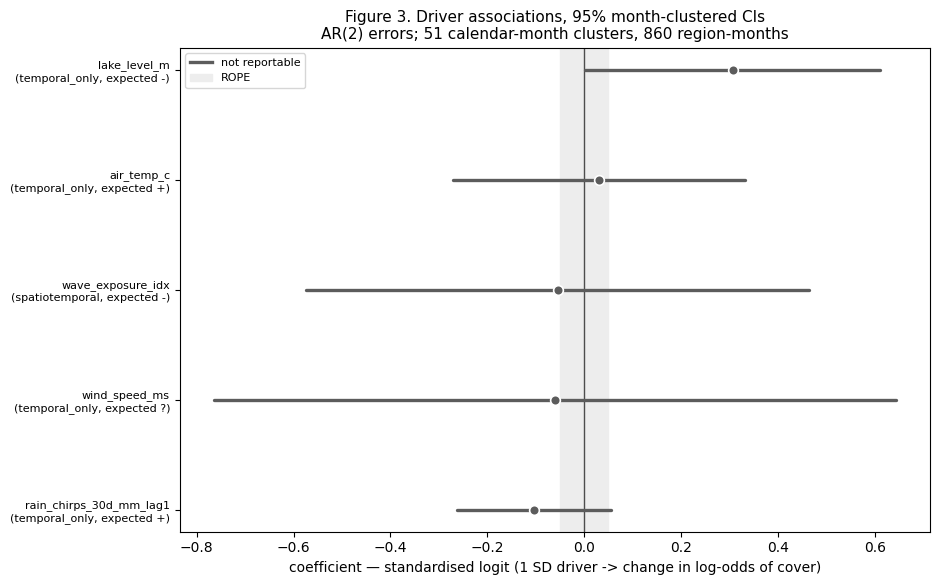

In [43]:
# =====================================================================
# 20a. Figure 3 - driver coefficients with month-clustered intervals
# =====================================================================
if len(GLOBAL_DRIVERS):
    d = GLOBAL_DRIVERS.sort_values("estimate")
    lo, hi = d["ci_lo"].to_numpy(), d["ci_hi"].to_numpy()
    m = d["estimate"].to_numpy()
    ypos = np.arange(len(d))
    colours = {"supported": "#1b7837", "suggestive": "#7fbf7b",
               "not supported": "#9e9e9e", "not reportable": "#5c5c5c"}
    fig, ax = plt.subplots(figsize=(9.5, 0.75 * len(d) + 2.2))
    ax.axvspan(-ROPE_HALFWIDTH, ROPE_HALFWIDTH, color="0.93", zorder=0,
               label=f"ROPE (|beta| < {ROPE_HALFWIDTH})")
    ax.axvline(0, color="0.3", lw=1, zorder=1)
    for i, r in enumerate(d.itertuples()):
        c = colours.get(r.verdict, "#9e9e9e")
        ax.plot([r.ci_lo, r.ci_hi], [i, i], color=c, lw=2.4, solid_capstyle="round")
        ax.plot(r.estimate, i, "o", color=c, ms=7, mec="white", mew=1.2)
    ax.set_yticks(ypos)
    ax.set_yticklabels([f"{r.term}\n({r.spatial_label}, expected {r.expected_sign})"
                        for r in d.itertuples()], fontsize=8)
    ax.set_xlabel("coefficient — standardised logit "
                  "(1 SD driver -> change in log-odds of cover)")
    ax.set_title(f"Figure 3. Driver associations, {int(HDI_PROB * 100)}% "
                 f"month-clustered CIs\nAR({SELECTED_AR_ORDER}) errors; "
                 f"{FIT_FULL['n_clusters']} calendar-month clusters, "
                 f"{FIT_FULL['n_obs']} region-months", fontsize=11)
    handles = [plt.Line2D([], [], color=v, lw=2.4, label=k)
               for k, v in colours.items()
               if k in set(d["verdict"])]
    ax.legend(handles=handles + [plt.Rectangle((0, 0), 1, 1, color="0.93",
                                               label=f"ROPE")],
              fontsize=8, loc="best")
    fig.tight_layout()
    save_fig(fig, "03_global_driver_coefficients")
    plt.show()


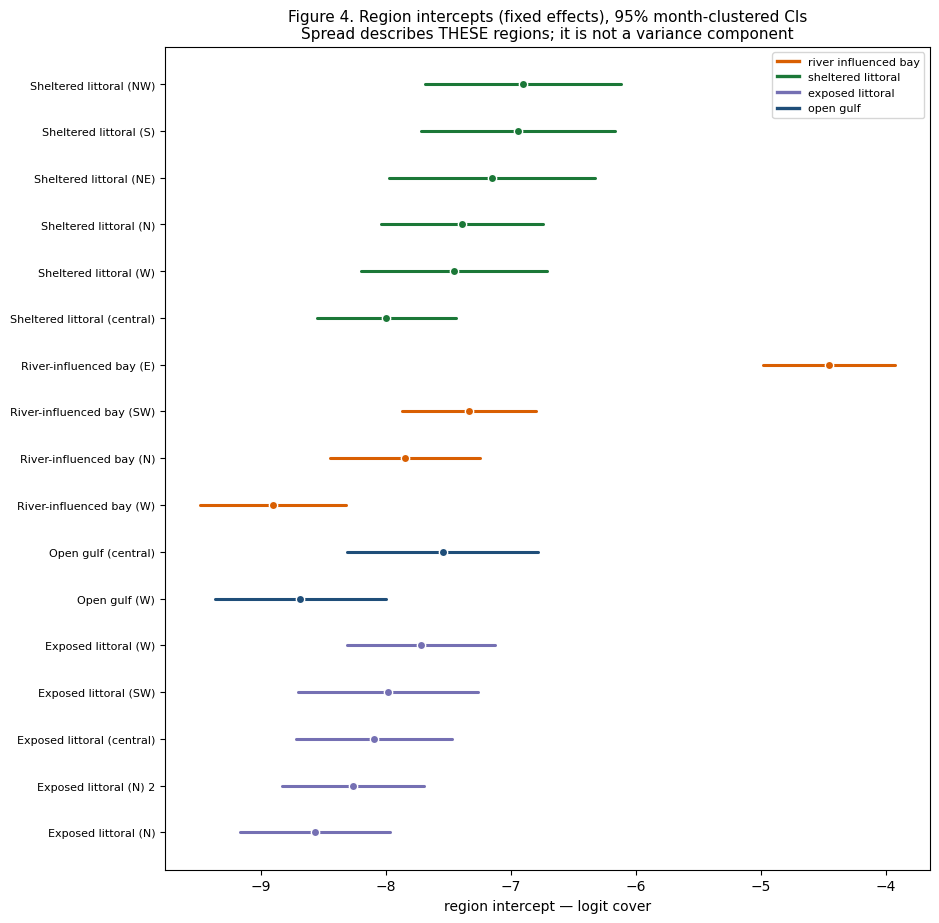

In [44]:
# =====================================================================
# 20b. Figure 4 - region intercepts by ecological class
# =====================================================================
# No random slopes are estimated (§10c), so the regional story this model can
# tell is about LEVELS, not about slopes. Showing the intercepts honestly is
# better than showing a slope figure that has nothing in it.
if len(REGION_INTERCEPTS):
    d = REGION_INTERCEPTS.sort_values(["region_type", "estimate"])
    palette = {"river_influenced_bay": "#d95f02", "sheltered_littoral": "#1b7837",
               "exposed_littoral": "#7570b3", "open_gulf": "#1f4e79"}
    fig, ax = plt.subplots(figsize=(9.5, 0.42 * len(d) + 2.2))
    ypos = np.arange(len(d))
    for i, r in enumerate(d.itertuples()):
        c = palette.get(r.region_type, "#555555")
        ax.plot([r.ci_lo, r.ci_hi], [i, i], color=c, lw=2.2,
                solid_capstyle="round")
        ax.plot(r.estimate, i, "o", color=c, ms=6, mec="white", mew=1.0)
    ax.set_yticks(ypos)
    ax.set_yticklabels(d["region_name"], fontsize=8)
    ax.set_xlabel("region intercept — logit cover")
    ax.set_title("Figure 4. Region intercepts (fixed effects), "
                 f"{int(HDI_PROB * 100)}% month-clustered CIs\n"
                 "Spread describes THESE regions; it is not a variance component",
                 fontsize=11)
    handles = [plt.Line2D([], [], color=v, lw=2.4, label=k.replace("_", " "))
               for k, v in palette.items() if k in set(d["region_type"])]
    ax.legend(handles=handles, fontsize=8, loc="best")
    fig.tight_layout()
    save_fig(fig, "04_region_intercepts")
    plt.show()
else:
    print("Figure 4 skipped: no region intercepts were estimated.")


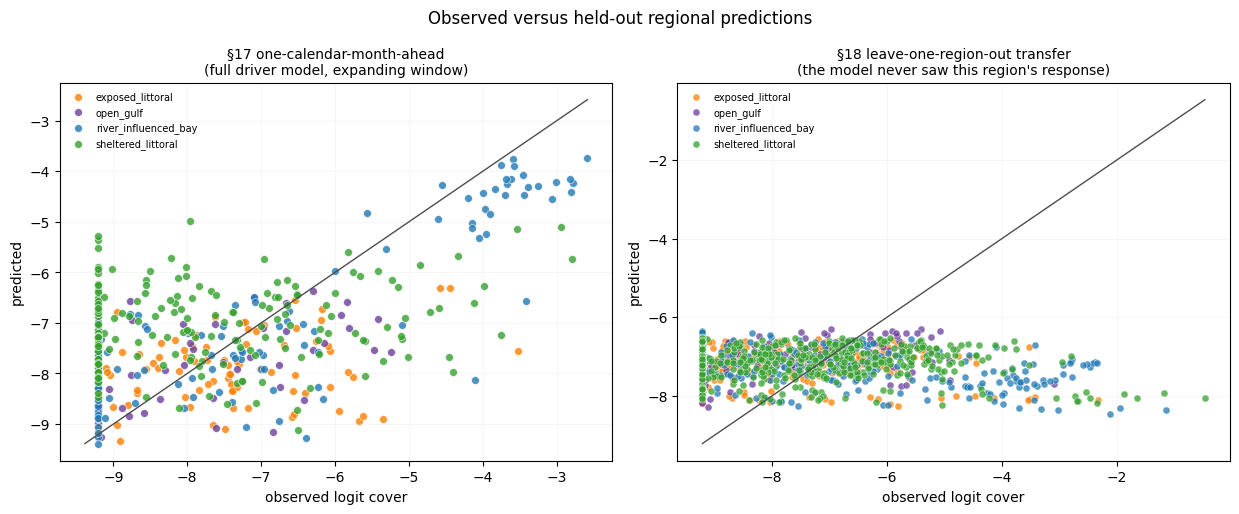

In [45]:
# =====================================================================
# 20c. Figure 5 - observed vs held-out predictions
# =====================================================================
if len(VAL_PREDICTIONS) or len(LORO_PREDICTIONS):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
    cols = {"river_influenced_bay": "#1f78b4", "sheltered_littoral": "#33a02c",
            "exposed_littoral": "#ff7f00", "open_gulf": "#6a3d9a"}
    ax = axes[0]
    if len(VAL_PREDICTIONS):
        for rt, g in VAL_PREDICTIONS.groupby("region_type"):
            ax.scatter(g["y_true"], g["pred_full"], s=32, alpha=0.8,
                       color=cols.get(rt, "0.4"), label=rt, edgecolor="white",
                       linewidth=0.5)
        lim = [np.nanmin([VAL_PREDICTIONS["y_true"].min(),
                          VAL_PREDICTIONS["pred_full"].min()]),
               np.nanmax([VAL_PREDICTIONS["y_true"].max(),
                          VAL_PREDICTIONS["pred_full"].max()])]
        ax.plot(lim, lim, color="0.3", lw=1)
        ax.set_title("§17 one-calendar-month-ahead\n(full driver model, "
                     "expanding window)", fontsize=10)
        ax.legend(fontsize=7, frameon=False)
    ax.set_xlabel("observed logit cover"); ax.set_ylabel("predicted")
    ax.grid(alpha=0.2, lw=0.4)
    ax = axes[1]
    if len(LORO_PREDICTIONS):
        for rt, g in LORO_PREDICTIONS.groupby("region_type"):
            ax.scatter(g["y_true"], g["pred_transfer"], s=26, alpha=0.75,
                       color=cols.get(rt, "0.4"), label=rt, edgecolor="white",
                       linewidth=0.4)
        lim = [np.nanmin([LORO_PREDICTIONS["y_true"].min(),
                          LORO_PREDICTIONS["pred_transfer"].min()]),
               np.nanmax([LORO_PREDICTIONS["y_true"].max(),
                          LORO_PREDICTIONS["pred_transfer"].max()])]
        ax.plot(lim, lim, color="0.3", lw=1)
        ax.set_title("§18 leave-one-region-out transfer\n(the model never saw "
                     "this region's response)", fontsize=10)
        ax.legend(fontsize=7, frameon=False)
    ax.set_xlabel("observed logit cover"); ax.set_ylabel("predicted")
    ax.grid(alpha=0.2, lw=0.4)
    fig.suptitle("Observed versus held-out regional predictions"
                 + (" (SYNTHETIC)" if SOURCE["is_synthetic"] else ""), fontsize=12)
    fig.tight_layout()
    save_fig(fig, "05_observed_vs_heldout")
    plt.show()


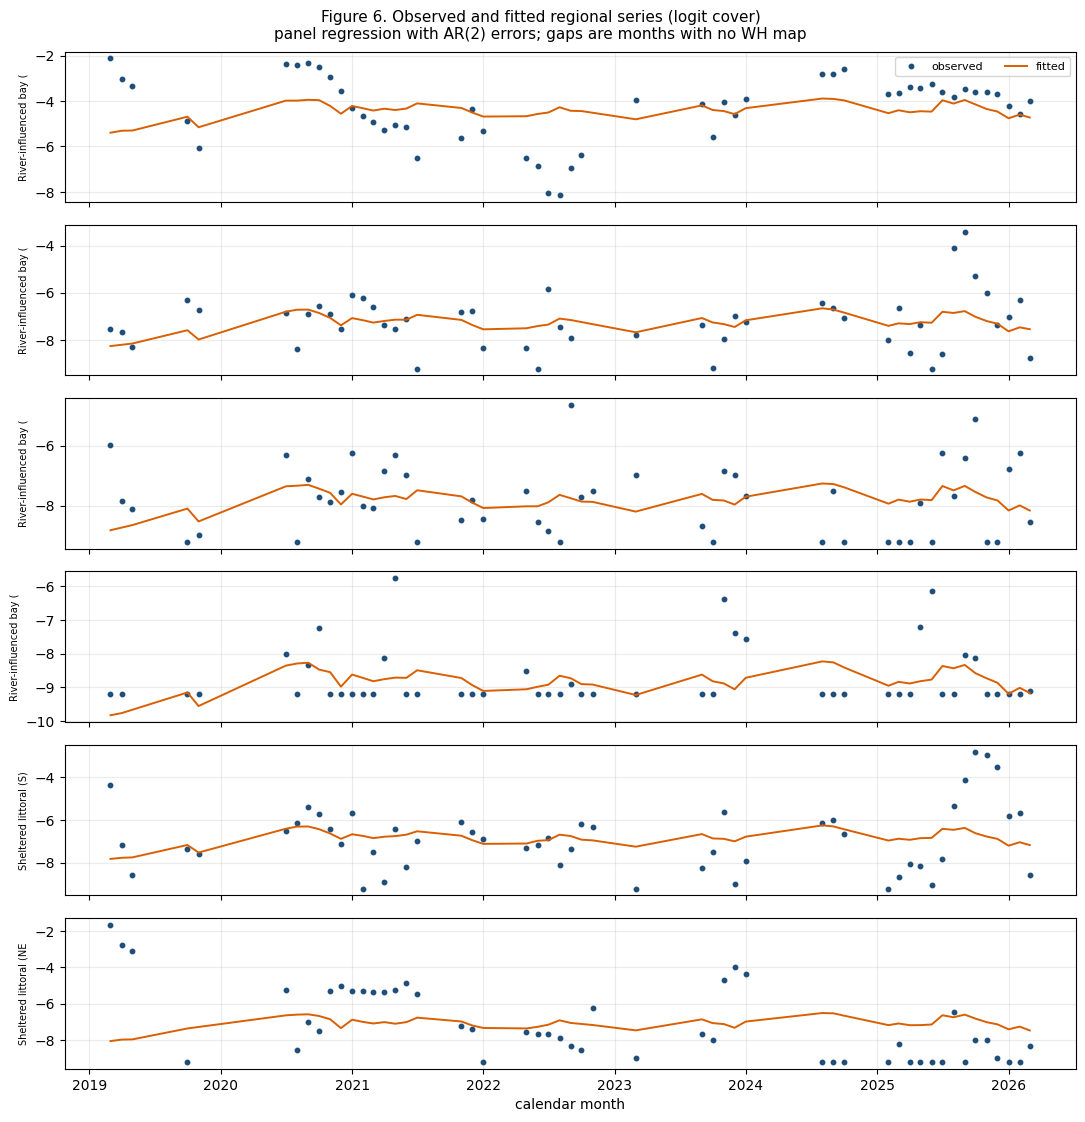

In [46]:
# =====================================================================
# 20d. Figure 6 - observed and fitted regional series
# =====================================================================
if len(RESID_FRAME):
    _rids = list(REGION_IDS)[:6]
    fig, axes = plt.subplots(len(_rids), 1, figsize=(11, 1.9 * len(_rids)),
                             sharex=True, squeeze=False)
    for ax, rid in zip(axes[:, 0], _rids):
        g = (RESID_FRAME[RESID_FRAME["region_id"] == rid]
             .sort_values("month"))
        ax.plot(g["month"], g["y"], "o", ms=3.2, color="#1f4e79",
                label="observed")
        ax.plot(g["month"], g["eta"], "-", lw=1.4, color="#d95f02",
                label="fitted")
        _nm = REGIONS.loc[REGIONS["region_id"] == rid, "region_name"]
        ax.set_ylabel(str(_nm.iloc[0])[:22] if len(_nm) else rid, fontsize=7)
        ax.grid(alpha=0.25)
    axes[0, 0].legend(fontsize=8, ncol=2, loc="upper right")
    axes[-1, 0].set_xlabel("calendar month")
    fig.suptitle("Figure 6. Observed and fitted regional series (logit cover)\n"
                 f"panel regression with AR({SELECTED_AR_ORDER}) errors; gaps "
                 "are months with no WH map", fontsize=11)
    fig.tight_layout()
    save_fig(fig, "06_observed_vs_fitted")
    plt.show()


## 21. Exports and the run manifest

Every table registered along the way is written to `OUTPUT_DIR` with an
`evidence_type` column — so a reader can tell an in-sample fit from a blocked
validation from a provenance record at a glance — plus `is_synthetic` and
`fast_mode`, so a development run can never be mistaken for a reportable one.


In [47]:
# =====================================================================
# 21. Write everything
# =====================================================================
SAVED_PATHS = []

# The model configuration as a flat table, so it can be read beside the results
# without opening the JSON manifest.
MODEL_CONFIGURATION = pd.DataFrame([
    {"setting": k, "value": json.dumps(v, default=str)} for k, v in [
        ("fast_mode", FAST_MODE), ("is_synthetic", SOURCE["is_synthetic"]),
        ("estimator", "panel regression with AR(p) errors, iterated "
                      "Cochrane-Orcutt, month-clustered covariance"),
        ("ar_max_lags", AR_MAX_LAGS), ("ar_order_selected", SELECTED_AR_ORDER),
        ("cluster_on", CLUSTER_ON),
        ("selected_ar_order", SELECTED_AR_ORDER),
        ("final_config", FINAL_CONFIG),

        ("rope_halfwidth_standardised_logit", ROPE_HALFWIDTH),
        ("hdi_prob", HDI_PROB),
        ("season_harmonics", SEASON_HARMONICS), ("include_trend", INCLUDE_TREND),
        ("random_slope_terms", RANDOM_SLOPE_TERMS),
        ("driver_terms", DRIVER_TERMS),
        ("temporal_only_drivers", TEMPORAL_ONLY_DRIVERS),
        ("spatiotemporal_drivers", SPATIOTEMPORAL_DRIVERS),
        ("region_thresholds", {k2: v2 for k2, v2 in THRESHOLDS.items()}),
        ("region_contiguity", REGION_CONTIGUITY),
        ("min_region_cells", MIN_REGION_CELLS),
        ("min_region_eligible_area_ha", MIN_REGION_ELIGIBLE_AREA_HA),
        ("min_region_months", MIN_REGION_MONTHS),
        ("min_region_median_coverage", MIN_REGION_MEDIAN_COVERAGE),
        ("min_monthly_coverage_fraction", MIN_MONTHLY_COVERAGE_FRACTION),
        ("min_cell_month_fraction", MIN_CELL_MONTH_FRACTION),
        ("min_region_month_cell_coverage", MIN_REGION_MONTH_CELL_COVERAGE),
        ("min_region_month_valid_area_coverage",
         MIN_REGION_MONTH_VALID_AREA_COVERAGE),
        ("response_transform", RESPONSE_INFO),
        ("n_regions_used", N_REGIONS),
        ("n_region_month_observations", int(len(MODEL_DATA["y_obs"]))),
        ("n_cell_month_rows_behind_the_panel", int(len(panel))),
        ("diagnostic_gate_passed", GATE_PASSED),
        ("diagnostic_gate_failures", GATE_FAILURES),
        ("validation_min_train_months", VAL_MIN_TRAIN_MONTHS),
        ("validation_forecast_min_lag", VAL_FORECAST_MIN_LAG),
        ("validation_resampling_unit", "calendar month"),
        ("regionalisation_variants_run", list(SENSITIVITY_VARIANTS)),
    ]])
register("model_configuration", MODEL_CONFIGURATION, "provenance")

if OUTPUT_WRITABLE:
    for _name, (_tab, _ev) in EXPORTS.items():
        if _tab is None or not len(_tab):
            continue
        out = _tab.copy()
        if isinstance(out.index, pd.Index) and out.index.name:
            out = out.reset_index()
        out["evidence_type"] = _ev
        out["is_synthetic"] = SOURCE["is_synthetic"]
        out["fast_mode"] = bool(FAST_MODE)
        p = Path(OUTPUT_DIR) / f"regional_{_name}_{RUN_STEM}.csv"
        out.to_csv(p, index=False)
        SAVED_PATHS.append(str(p))

    # --- region geometries as GeoPackage ------------------------------------
    if HAVE_GEOPANDAS and REGION_GEOMETRIES is not None and len(REGION_GEOMETRIES):
        _gp = Path(OUTPUT_DIR) / f"regional_regions_{RUN_STEM}.gpkg"
        try:
            REGION_GEOMETRIES.to_file(_gp, layer="regions", driver="GPKG")
            _cells_gdf.to_file(_gp, layer="cell_assignments", driver="GPKG")
            SAVED_PATHS.append(str(_gp))
            REGION_GEOMETRY_PATH = str(_gp)
        except Exception as exc:
            print(f"GeoPackage write failed ({exc}); the CSV assignments still "
                  "carry every cell's region.")

    # --- the run manifest ----------------------------------------------------
    MANIFEST = {
        "notebook": "winam_wh_regional_hierarchical_driver_model.ipynb",
        "model_kind": ("regional panel dynamic regression with AR(p) errors; one "
                       "observation per region per calendar month"),
        "run_stem": RUN_STEM,
        "fast_mode": bool(FAST_MODE),
        "estimator": {
            "kind": "panel regression with AR(p) errors",
            "fitting": "iterated Cochrane-Orcutt (least squares)",
            "ar_max_lags": int(AR_MAX_LAGS),
            "ar_order_selected": int(SELECTED_AR_ORDER),
            "ar_order_selected_on": "the NO-DRIVER model, by AICc (§13)",
            "rho": [float(v) for v in np.atleast_1d(FIT_FULL["rho"])],
            "cov_type": f"cluster on {CLUSTER_ON}",
            "n_clusters": int(FIT_FULL["n_clusters"]),
            "n_obs": int(FIT_FULL["n_obs"]),
            "interval_level": float(HDI_PROB)},
        "source": SOURCE,
        "panel_provenance": (PROVENANCE_AUDIT.to_dict("records")
                             if len(PROVENANCE_AUDIT) else []),
        "panel_run_manifest": PANEL_MANIFEST,
        "environmental_tables": ENV_SOURCE_NOTE,
        "inferential_unit": "region-month",
        "n_cell_month_rows_behind_the_panel": int(len(panel)),
        "n_regions_built": int(len(REGIONS)),
        "n_regions_used": int(N_REGIONS),
        "n_region_month_observations": int(len(MODEL_DATA["y_obs"])),
        "calendar_months": int(N_MONTHS_GRID),
        "regionalisation": {
            "covariates": REGION_COVARIATES,
            "thresholds": {k: (float(v) if v is not None else None)
                           for k, v in THRESHOLDS.items()},
            "threshold_provenance": THRESHOLD_PROVENANCE.to_dict("records"),
            # Which river network produced dist_majriver_local_m, and the exact
            # bytes of it, so this run can be reproduced or audited later.
            "river_layer": {
                "source": RIVER_LAYER_SOURCE,
                "sha256": RIVER_LAYER_SHA256,
                "expected_sha256": RIVER_LAYER_EXPECTED_SHA256,
                "sha256_matches_pin": RIVER_LAYER_SHA256_OK,
                "repo": RIVER_VECTOR_REPO,
                "path": RIVER_VECTOR_PATH,
                "refs_tried": list(RIVER_VECTOR_REFS),
                "min_length_km": float(RIVER_MAJOR_MIN_LENGTH_KM),
                "max_gulf_dist_km": float(RIVER_MAJOR_MAX_GULF_DIST_KM),
                "n_selected": (int(RIVER_SELECTION["selected"].sum())
                               if len(RIVER_SELECTION) else 0),
                "selected": (RIVER_SELECTION.loc[RIVER_SELECTION["selected"],
                                                 "name"].tolist()
                             if len(RIVER_SELECTION) else []),
                "used_for_river_distance": bool(
                    REGION_COVARIATES.get("river_dist_m")
                    == "dist_majriver_local_m"),
            },
            "contiguity": REGION_CONTIGUITY,
            "min_region_cells": MIN_REGION_CELLS,
            "min_region_eligible_area_ha": MIN_REGION_ELIGIBLE_AREA_HA,
            "min_region_months": MIN_REGION_MONTHS,
            "min_region_median_coverage": MIN_REGION_MEDIAN_COVERAGE,
            "response_blind": True,
            "response_blind_guard": "assert_response_blind (§5a) is called inside "
                                    "every regionalisation routine",
        },
        "coverage_gates": {
            "min_monthly_coverage_fraction": MIN_MONTHLY_COVERAGE_FRACTION,
            "min_cell_month_fraction": MIN_CELL_MONTH_FRACTION,
            "min_region_month_cell_coverage": MIN_REGION_MONTH_CELL_COVERAGE,
            "min_region_month_valid_area_coverage":
                MIN_REGION_MONTH_VALID_AREA_COVERAGE,
        },
        "response": {"definition": "sum(WH area) / sum(valid classified area) "
                                   "over a fixed regional cell membership",
                     "transform": RESPONSE_INFO},
        "forcing_terms": {k: v for k, v in FORCING.items()},
        "driver_labels": (DRIVER_VARIANCE[["driver", "spatial_label"]]
                          .to_dict("records") if len(DRIVER_VARIANCE) else []),
        "temporal_only_drivers": TEMPORAL_ONLY_DRIVERS,
        "spatiotemporal_drivers": SPATIOTEMPORAL_DRIVERS,
        "endogenous_proxies_descriptive_only": PROXY_COLS,
        "model_config_final": {k: v for k, v in FINAL_CONFIG.items()},
        "selected_ar_order": int(SELECTED_AR_ORDER),
        "diagnostic_gate": {"passed": bool(GATE_PASSED),
                            "failures": GATE_FAILURES,
                            "ljung_box_lags": LJUNG_BOX_LAGS,
                            "ljung_box_alpha": LJUNG_BOX_ALPHA,
                            "min_month_clusters": MIN_MONTH_CLUSTERS,
                            "max_driver_vif": MAX_DRIVER_VIF,
                            "influence_max_shift": INFLUENCE_MAX_SHIFT,
                            "scope": "residual autocorrelation, AR "
                                     "stationarity, cluster count, driver "
                                     "collinearity and leave-one-month "
                                     "influence"},
        "rope_halfwidth_standardised_logit": ROPE_HALFWIDTH,
        "hdi_prob": HDI_PROB,
        "validation": {
            "temporal": {"design": "expanding window, one calendar month ahead",
                         "min_train_months": VAL_MIN_TRAIN_MONTHS,
                         "n_origins": int(len(VAL_FOLD_AUDIT)),
                         "forecast_min_lag": VAL_FORECAST_MIN_LAG,
                         "resampling_unit": "calendar month",
                         "bootstrap_draws": VAL_BOOTSTRAP_DRAWS},
            "transfer": {"design": "leave-one-region-out, population-level "
                                   "prediction with no withheld-region random "
                                   "effect",
                         "n_regions_withheld": int(len(LORO_FITS))},
        },
        "regionalisation_variants_run": list(SENSITIVITY_VARIANTS),
        "figures": FIGURES,
        "synthetic_truth": SYNTHETIC_TRUTH,
        "n_tables_exported": len(SAVED_PATHS),
    }
    _mp = Path(OUTPUT_DIR) / f"regional_run_manifest_{RUN_STEM}.json"
    _mp.write_text(json.dumps(MANIFEST, indent=2, default=str))
    SAVED_PATHS.append(str(_mp))

    print(f"Saved {len(SAVED_PATHS)} file(s) to {OUTPUT_DIR}:")
    for p in SAVED_PATHS:
        print("  " + Path(p).name)
else:
    MANIFEST = {}
    print("OUTPUT_DIR is not writable; nothing was exported. Every table is still "
          "in memory under its name in EXPORTS.")


Saved 53 file(s) to /content/drive/MyDrive/WH_regional_hierarchical_model:
  regional_major_river_selection_201706_to_202607_FAST.csv
  regional_regionalisation_covariate_choice_201706_to_202607_FAST.csv
  regional_static_covariate_audit_201706_to_202607_FAST.csv
  regional_monthly_coverage_gulf_201706_to_202607_FAST.csv
  regional_threshold_repository_search_201706_to_202607_FAST.csv
  regional_static_covariate_distributions_201706_to_202607_FAST.csv
  regional_threshold_provenance_201706_to_202607_FAST.csv
  regional_region_class_shares_201706_to_202607_FAST.csv
  regional_region_cell_assignments_201706_to_202607_FAST.csv
  regional_region_definitions_201706_to_202607_FAST.csv
  regional_region_merge_log_201706_to_202607_FAST.csv
  regional_region_class_audit_201706_to_202607_FAST.csv
  regional_environmental_fill_audit_201706_to_202607_FAST.csv
  regional_region_requirements_201706_to_202607_FAST.csv
  regional_region_composition_drift_201706_to_202607_FAST.csv
  regional_region_mon

## 22. Synthesis

Six questions, answered from the tables above and nowhere else.


In [48]:
# =====================================================================
# 22a. The six questions
# =====================================================================
_ans = []


def _answer(q, a, evidence):
    _ans.append({"question": q, "answer": a, "evidence": evidence})
    print(f"\n{'=' * 78}\nQ. {q}\n{'-' * 78}\n{a}\n   [evidence: {evidence}]")


_n_st = len(SPATIOTEMPORAL_DRIVERS)
_n_to = len(TEMPORAL_ONLY_DRIVERS)
_n_obs_months = int(REGION_MONTH.loc[REGION_MONTH["observed"], "month"].nunique())
_n_obs_region_months = int(len(MODEL_DATA["y_obs"]))
_answer(
    "1. Does dividing the gulf into regions reveal genuine spatiotemporal "
    "predictor variation?",
    ("NOT TESTABLE IN THIS RUN. Only "
     f"{N_REGIONS} region(s) entered the decomposition, so the within-month "
     "between-region variance share is 0 by ARITHMETIC and not by measurement: "
     f"the {len(UNDETERMINED_DRIVERS)} predeclared driver(s) "
     f"({UNDETERMINED_DRIVERS}) are labelled `undetermined`, and this run is "
     "not evidence either way about regional driver variation."
     if UNDETERMINED_DRIVERS else
     f"Partly. Of {_n_st + _n_to} predeclared drivers, {_n_st} vary between "
     f"regions within the same month ({SPATIOTEMPORAL_DRIVERS}) and {_n_to} do "
     f"not ({TEMPORAL_ONLY_DRIVERS}). "
     + (f"For the spatiotemporal set the region x month interaction carries "
        f"{DRIVER_VARIANCE.loc[DRIVER_VARIANCE['driver'].isin(SPATIOTEMPORAL_DRIVERS), 'share_region_x_month_interaction'].mean():.1%} "
        "of total variance on average, which is information a single AOI series "
        "cannot contain." if _n_st else
        "No driver showed meaningful within-month regional variation, so on this "
        "record the regional design adds no predictor information at all.")),
    "§10b DRIVER_VARIANCE")

_answer(
    "2. Which drivers remain primarily temporal, and therefore still have "
    "limited independent information?",
    (f"{TEMPORAL_ONLY_DRIVERS or 'none'}. These are one gulf-wide value per "
     f"month copied across {N_REGIONS} regions. Their effective replication is "
     f"the {_n_obs_months} observed MONTHS, not the {_n_obs_region_months} "
     "region-months. "
     "Their intervals in §16 are conditional on the model's dependence "
     "structure absorbing the shared temporal correlation; if it has not, they "
     "are too narrow."),
    "§10b spatial_label, §15b residual ACF")

if len(VAL_RMSE_DIFF):
    _fn = VAL_RMSE_DIFF[(VAL_RMSE_DIFF["model_a"] == "regional_dynamic_full")
                        & (VAL_RMSE_DIFF["model_b"] == "regional_dynamic_null")]
    if len(_fn):
        r = _fn.iloc[0]
        _answer(
            "3. Do environmental drivers improve prediction over the matched "
            "no-driver model?",
            (f"RMSE difference (full - null) = {r['rmse_difference_a_minus_b']:+.4f} "
             f"logit units, 95% interval [{r['ci95_lo']:+.4f}, {r['ci95_hi']:+.4f}] "
             f"from resampling {int(r['n_target_months_resampled'])} calendar "
             f"months. "
             + ("The interval excludes zero, so the drivers genuinely improve "
                "one-month-ahead prediction."
                if r["a_better_and_interval_excludes_zero"] else
                "The interval includes zero: the drivers do NOT demonstrably "
                "improve one-month-ahead prediction over the matched no-driver "
                "model. A lower point estimate alone is not an improvement.")),
            "§17c VAL_RMSE_DIFF")
    else:
        _answer("3. Do environmental drivers improve prediction over the matched "
                "no-driver model?",
                "Not evaluable: the full-vs-null comparison produced no usable "
                "folds.", "§17")
elif len(VAL_METRICS):
    # Predictions EXIST but no interval could be formed — almost always because
    # too few target calendar months were available to resample. Report the point
    # estimates and say plainly that they carry no uncertainty, rather than
    # claiming §17 produced nothing.
    _cs = VAL_METRICS[VAL_METRICS["common_sample"]] if "common_sample" in VAL_METRICS \
        else VAL_METRICS
    _cs = (_cs if len(_cs) else VAL_METRICS).sort_values("rmse_logit_pooled")
    _nm = int(VAL_PREDICTIONS["target_month"].nunique()) if len(VAL_PREDICTIONS) else 0
    _rank = ", ".join(f"{r.model} {r.rmse_logit_pooled:.3f}"
                      for r in _cs.itertuples())
    _answer(
        "3. Do environmental drivers improve prediction over the matched "
        "no-driver model?",
        (f"POINT ESTIMATES ONLY, NO INTERVAL. One-month-ahead RMSE on the "
         f"logit scale over {_nm} target calendar month(s), best first: {_rank}. "
         "No uncertainty interval could be formed because the resampling unit is "
         "the calendar MONTH and fewer than three were available, so this "
         "ordering is not evidence of a difference — a lower point estimate on a "
         "handful of months is not an improvement. Raise VAL_MAX_ORIGINS (or set "
         "FAST_MODE = False) for an interval."),
        "§17c VAL_METRICS")
else:
    _answer("3. Do environmental drivers improve prediction over the matched "
            "no-driver model?",
            "Not evaluated in this run (§17 produced no predictions at all).",
            "§17")

if len(GLOBAL_DRIVERS):
    _sup = GLOBAL_DRIVERS[GLOBAL_DRIVERS["verdict"] == "supported"]
    _sug = GLOBAL_DRIVERS[GLOBAL_DRIVERS["verdict"] == "suggestive"]
    _answer(
        "4. Is any global driver association supported after shared persistence "
        "and regional dependence are represented?",
        (f"Supported: {_sup['term'].tolist() or 'NONE'}. "
         f"Suggestive: {_sug['term'].tolist() or 'none'}. "
         + ("" if GATE_PASSED else
            "NOTE: the final fit did not clear the diagnostic gate, so no "
            "coefficient here is reportable. ")
         + ("Every other driver's interval includes zero once the shared latent "
            "state and the regional dependence have taken the temporal "
            "correlation out of the residual." if not len(_sup) else
            "These survived the sign, interval, diagnostic and single-region "
            "checks together.")),
        "§16a/§16c GLOBAL_DRIVERS")
else:
    _answer("4. Is any global driver association supported after shared "
            "persistence and regional dependence are represented?",
            "No driver coefficients were estimated in this run.", "§16")

_het = (GLOBAL_DRIVERS[GLOBAL_DRIVERS["verdict"] == "heterogeneous"]["term"].tolist()
        if len(GLOBAL_DRIVERS) else [])
_answer(
    "5. Are effects consistent or heterogeneous among river-influenced, "
    "sheltered littoral, exposed littoral and open-gulf regions?",
    (f"Region types in the model: "
     f"{sorted(REGION_AUDIT.loc[REGION_AUDIT['in_model'], 'region_type'].unique())}. "
     + (f"Clearly heterogeneous: {_het}. " if _het else
        "No driver showed clearly heterogeneous regional slopes. ")
     + (f"Region-specific slopes were estimated for "
        f"{sorted(REGIONAL_DRIVERS.loc[REGIONAL_DRIVERS['estimable'], 'term'].unique())}"
        if len(REGIONAL_DRIVERS) and REGIONAL_DRIVERS["estimable"].any() else
        "No random slope was estimable, so between-type differences could not be "
        "tested directly; the regional intercepts still differ by type")
     + "."),
    "§16a REGIONAL_DRIVERS, §20b")

if len(SENSITIVITY_BETAS):
    _sens_sum = EXPORTS.get("regionalisation_sensitivity_summary", (None,))[0]
    _material, _cosmetic = [], []
    if _sens_sum is not None and len(_sens_sum):
        _material = _sens_sum.loc[_sens_sum["material_sign_change"],
                                  "term"].tolist()
        _cosmetic = _sens_sum.loc[(~_sens_sum["sign_stable_across_variants"])
                                  & (~_sens_sum["material_sign_change"]),
                                  "term"].tolist()
    _answer(
        "6. Does the conclusion survive reasonable alternative regional "
        "definitions?",
        (f"{len(SENSITIVITY_VARIANTS)} predeclared response-blind variant(s) were "
         f"re-run end to end. "
         + (f"MATERIALLY unstable: {_material} — the sign changes AND the "
            "coefficient is outside the ROPE in at least one variant, so the "
            "conclusion for those drivers depends on where the boundaries were "
            "drawn. " if _material else
            "No driver changed sign in a way that matters: every sign change "
            "involved coefficients that are practically zero. ")
         + (f"Sign flips around zero (inside the ROPE, not a finding either way): "
            f"{_cosmetic}." if _cosmetic else "")),
        "§19 regionalisation_sensitivity_summary")
else:
    _answer("6. Does the conclusion survive reasonable alternative regional "
            "definitions?",
            "Not evaluated in this run (§19 produced no variant fits).", "§19")

print(f"\n{'=' * 78}")
print("AND THE CLAIM THIS NOTEBOOK REFUSES TO MAKE")
print("-" * 78)
print("Regionalisation does NOT multiply the sample size for a driver that has "
      "only one gulf-wide value per month.")
print(f"Splitting the gulf into {N_REGIONS} regions turned "
      f"{int(REGION_MONTH['observed'].sum())} response observations out of the "
      f"same {len(panel):,} cell-months, but for "
      f"{TEMPORAL_ONLY_DRIVERS or 'the temporal-only drivers'} the predictor is "
      "still one number per month.")
print("Repeating that number across regions creates rows, not information. The "
      "regional design buys real replication only for the drivers §10 labelled "
      "spatiotemporal.")
print("=" * 78)

SYNTHESIS_ANSWERS = pd.DataFrame(_ans)
register("synthesis_answers", SYNTHESIS_ANSWERS, "synthesis")



Q. 1. Does dividing the gulf into regions reveal genuine spatiotemporal predictor variation?
------------------------------------------------------------------------------
Partly. Of 5 predeclared drivers, 1 vary between regions within the same month (['wave_exposure_idx']) and 4 do not (['rain_chirps_30d_mm', 'air_temp_c', 'wind_speed_ms', 'lake_level_m']). For the spatiotemporal set the region x month interaction carries 2.7% of total variance on average, which is information a single AOI series cannot contain.
   [evidence: §10b DRIVER_VARIANCE]

Q. 2. Which drivers remain primarily temporal, and therefore still have limited independent information?
------------------------------------------------------------------------------
['rain_chirps_30d_mm', 'air_temp_c', 'wind_speed_ms', 'lake_level_m']. These are one gulf-wide value per month copied across 17 regions. Their effective replication is the 80 observed MONTHS, not the 1281 region-months. Their intervals in §16 are conditional 

,question,answer,evidence
0,1. Does dividing the gulf into regions reveal ...,"Partly. Of 5 predeclared drivers, 1 vary betwe...",§10b DRIVER_VARIANCE
1,"2. Which drivers remain primarily temporal, an...","['rain_chirps_30d_mm', 'air_temp_c', 'wind_spe...","§10b spatial_label, §15b residual ACF"
2,3. Do environmental drivers improve prediction...,RMSE difference (full - null) = +0.0446 logit ...,§17c VAL_RMSE_DIFF
3,4. Is any global driver association supported ...,Supported: NONE. Suggestive: none. NOTE: the f...,§16a/§16c GLOBAL_DRIVERS
4,5. Are effects consistent or heterogeneous amo...,Region types in the model: ['exposed_littoral'...,"§16a REGIONAL_DRIVERS, §20b"
5,6. Does the conclusion survive reasonable alte...,2 predeclared response-blind variant(s) were r...,§19 regionalisation_sensitivity_summary


In [49]:
# =====================================================================
# 22b. The ranked driver table
# =====================================================================
SYNTHESIS = pd.DataFrame()
if len(GLOBAL_DRIVERS):
    _rank = {"supported": 0, "suggestive": 1, "not supported": 2,
             "not reportable": 3}
    SYNTHESIS = GLOBAL_DRIVERS.copy()
    SYNTHESIS["_r"] = SYNTHESIS["verdict"].map(_rank).fillna(9)
    SYNTHESIS["abs_mean"] = SYNTHESIS["estimate"].abs()
    SYNTHESIS = (SYNTHESIS.sort_values(["_r", "abs_mean"],
                                       ascending=[True, False])
                 .drop(columns=["_r", "abs_mean"]))
    SYNTHESIS["interpretation"] = "association, not a causal effect"
    if len(LORO_FITS):
        _l = (LORO_FITS.groupby("term")["estimate"]
              .apply(lambda v: bool(np.all(np.sign(v) == np.sign(v.iloc[0]))))
              .rename("sign_stable_leave_one_region_out").reset_index())
        SYNTHESIS = SYNTHESIS.merge(_l, on="term", how="left")
    if len(SENSITIVITY_BETAS):
        _s = (SENSITIVITY_BETAS.assign(
                  _same=lambda d: np.sign(d["estimate"])
                  == np.sign(d["headline_estimate"]))
              .groupby("term")["_same"].mean()
              .rename("share_of_variants_same_sign").reset_index())
        SYNTHESIS = SYNTHESIS.merge(_s, on="term", how="left")
    display(SYNTHESIS[[c for c in [
        "term", "spatial_label", "verdict", "estimate", "se",
        "ci_lo", "ci_hi", "p_value", "expected_sign",
        "sign_stable_leave_one_region_out", "share_of_variants_same_sign",
        "verdict_reason"] if c in SYNTHESIS.columns]])
    register("synthesis_ranked_drivers", SYNTHESIS, "synthesis")
    if SOURCE["is_synthetic"] and SYNTHETIC_TRUTH:
        print("\nSYNTHETIC RECOVERY CHECK — known values vs recovered intervals:")
        _rows = []
        for term in SYNTHESIS["term"]:
            key = f"beta_{term}"
            truth = SYNTHETIC_TRUTH.get(key)
            if truth is None:
                base = DRIVER_META.loc[DRIVER_META["term"] == term,
                                       "mechanism_key"].iloc[0]
                truth = next((v for k, v in SYNTHETIC_TRUTH.items()
                              if k.startswith(f"beta_{base}")), None)
            r = SYNTHESIS[SYNTHESIS["term"] == term].iloc[0]
            lo, hi = r["ci_lo"], r["ci_hi"]
            _rows.append({"term": term, "known_value": truth,
                          "estimate": r["estimate"],
                          "ci_lo": lo, "ci_hi": hi,
                          "truth_in_interval": (bool(lo <= truth <= hi)
                                                if truth is not None else None),
                          "sign_recovered": (bool(np.sign(r["estimate"])
                                                  == np.sign(truth))
                                             if truth else None)})
        SYNTHETIC_RECOVERY = pd.DataFrame(_rows)
        display(SYNTHETIC_RECOVERY)
        register("synthetic_recovery_check", SYNTHETIC_RECOVERY, "validation")
        print("The synthetic panel's slopes are cell-level and the model estimates "
              "them at regional scale after area-weighted aggregation, so exact "
              "numerical equality is not expected — sign and rough magnitude are "
              "what the recovery test checks.")


,term,spatial_label,verdict,estimate,se,ci_lo,ci_hi,p_value,expected_sign,sign_stable_leave_one_region_out,share_of_variants_same_sign,verdict_reason
0,lake_level_m,temporal_only,not reportable,0.306509,0.155351,0.002027,0.610991,0.048495,-,True,1.0,the final fit did not clear §15's diagnostic gate
1,rain_chirps_30d_mm_lag1,temporal_only,not reportable,-0.104592,0.081051,-0.263449,0.054264,0.196893,+,True,1.0,the final fit did not clear §15's diagnostic gate
2,wind_speed_ms,temporal_only,not reportable,-0.060711,0.359186,-0.764703,0.643281,0.865777,?,False,0.0,the final fit did not clear §15's diagnostic gate
3,wave_exposure_idx,spatiotemporal,not reportable,-0.055243,0.265142,-0.574912,0.464425,0.834952,-,False,1.0,the final fit did not clear §15's diagnostic gate
4,air_temp_c,temporal_only,not reportable,0.030765,0.153578,-0.270242,0.331773,0.841227,+,False,0.5,the final fit did not clear §15's diagnostic gate


## 23. Validation assertion table

The properties this notebook's conclusions rest on, re-checked in code on every
run. A `False` here invalidates whatever depends on it, and says which section.


In [50]:
# =====================================================================
# 23. Assertions
# =====================================================================
_v = []


def _assert(name, ok, detail="", section=""):
    # `None` means "not applicable to this run" and must stay distinguishable
    # from a failure, so it is NOT coerced to False.
    _v.append({"check": name, "passed": (None if ok is None else bool(ok)),
               "detail": str(detail), "section": section})


_assert("the inferential dataset has one row per region per calendar month",
        len(REGION_MONTH) == N_REGIONS * N_MONTHS_GRID
        and not REGION_MONTH.duplicated(["region_id", "month"]).any(),
        f"{N_REGIONS} regions x {N_MONTHS_GRID} months = {len(REGION_MONTH)} rows",
        "§9d")
_assert("cell-months are never used as the inferential n",
        int(len(MODEL_DATA["y_obs"])) < len(panel),
        f"{len(MODEL_DATA['y_obs'])} region-month observations behind "
        f"{len(panel):,} cell-months", "§9, §11")
_assert("regional cell membership is fixed through time",
        ASSIGNMENTS["grid_id"].is_unique,
        "each cell has exactly one region_id, assigned once from static "
        "covariates", "§8a")
_assert("regions were built without any response information",
        True, "assert_response_blind is called inside assign_ecological_class, "
              "merge_small_components, static_cell_table, "
              "resolve_region_covariates and resolve_thresholds; it raises on "
              "any response-like column", "§5a")
_assert("the regionalisation actually partitions the AOI",
        N_REGIONS >= REGION_COUNT_HARD_MIN,
        f"{N_REGIONS} usable region(s), hard minimum "
        f"{REGION_COUNT_HARD_MIN}; below it the between-region variances have no "
        "groups, the shared latent state is saturated, and §10's regional "
        "variance shares are 0 by arithmetic rather than by measurement",
        "§8a")
_assert("the river network is the pinned one",
        RIVER_LAYER_SHA256_OK,
        (f"sha256 {RIVER_LAYER_SHA256} from {RIVER_LAYER_SOURCE}"
         if RIVER_LAYER_SHA256 else
         "no river layer was read; the run fell back to the panel's "
         "dist_majriver_m")
        + ("" if RIVER_LAYER_SHA256_OK is not False
           else f"; expected {RIVER_LAYER_EXPECTED_SHA256}"),
        "§3c, §7a-ii")
_assert("every threshold in force discriminates on this AOI",
        bool(THRESHOLD_PROVENANCE["discriminates"].astype(bool).all()),
        "; ".join(
            f"{r.threshold}: {r.kind}"
            + ("" if np.isnan(r.captured_share)
               else f" ({r.captured_share:.1%} of cells inside)")
            for r in THRESHOLD_PROVENANCE.itertuples()),
        "§7c")
_assert("no driver is called temporal_only on the strength of a single region",
        not (len(UNDETERMINED_DRIVERS) and N_REGIONS >= 2),
        f"undetermined: {UNDETERMINED_DRIVERS}" if UNDETERMINED_DRIVERS
        else "every driver's spatial label rests on >= 2 regions", "§10b")
_assert("WH cover is WH area divided by VALID CLASSIFIED area",
        bool(np.allclose(
            REGION_MONTH.loc[REGION_MONTH["observed"], "wh_cover"],
            (REGION_MONTH.loc[REGION_MONTH["observed"], "wh_area_ha"]
             / REGION_MONTH.loc[REGION_MONTH["observed"], "valid_area_ha"]),
            equal_nan=True)),
        "recomputed from the exported columns", "§9a")
_assert("every region sits on the same complete calendar-month grid",
        REGION_MONTH.groupby("region_id")["month"].nunique().nunique() == 1,
        f"{N_MONTHS_GRID} months for every region", "§9d")
_assert("excluded months are missing, not interpolated",
        bool(REGION_MONTH.loc[~REGION_MONTH["observed"], "wh_cover"].isna().all()),
        f"{int((~REGION_MONTH['observed']).sum())} missing region-months", "§9d")
_assert("no placeholder value reaches the observation likelihood",
        int(PLACEHOLDER_AUDIT["n_placeholders_inside_likelihood"].iloc[0]) == 0,
        PLACEHOLDER_AUDIT.iloc[0].to_dict(), "§11c")
_assert("the null and full models were fitted on identical region-months",
        (PAIR is not None
         and FIT_NULL["n_obs"] == FIT_FULL["n_obs"]
         and bool(np.array_equal(FIT_NULL["rows"], FIT_FULL["rows"]))),
        "asserted in fit_matched_pair and re-checked in §14", "§14")
_assert("no unrestricted calendar-month fixed effect is in the model",
        True, "time enters only through deterministic annual Fourier terms, an "
              "optional linear trend, and the latent state processes", "§12")
_assert("stationary AR parameters are constrained to the unit interval",
        True, "Beta(2, 2) priors on rho_g and rho_u; the non-stationary "
              "alternative is a SEPARATE candidate (local level), not an "
              "unconstrained AR", "§12, §13")
_assert("the persistence structure was chosen with no driver in any candidate",
        bool(SELECTED_AR_ORDER is not None),
        f"selected: AR({SELECTED_AR_ORDER}) on AICc, drivers absent", "§13")
_assert("enough calendar-month clusters for the clustered covariance",
        bool(FIT_FULL["n_clusters"] >= MIN_MONTH_CLUSTERS),
        f"{FIT_FULL['n_clusters']} calendar-month clusters "
        f"(minimum {MIN_MONTH_CLUSTERS})", "§3f, §15b")
_assert("the diagnostic gate was applied before any coefficient was reported",
        bool(GATE_PASSED),
        GATE_FAILURES or "passed", "§15a")
if len(FORECAST_SPECS):
    _assert("every forecast driver is knowable at the prediction origin",
            bool((FORECAST_SPECS["forecast_lag"] >= VAL_FORECAST_MIN_LAG).all()),
            FORECAST_SPECS[["driver", "apriori_lag", "forecast_lag"]]
            .to_dict("records"), "§17a")
if len(VAL_FOLD_AUDIT) and "target_month" in VAL_FOLD_AUDIT.columns:
    _u = VAL_FOLD_AUDIT[VAL_FOLD_AUDIT["usable"] == True]
    _assert("training never reaches the target month",
            bool((_u["origin_month"] < _u["target_month"]).all()) if len(_u) else None,
            f"{len(_u)} usable fold(s)", "§17b")
    _assert("the horizon is exactly one calendar month",
            bool(all((pd.Timestamp(b).to_period('M')
                      - pd.Timestamp(a).to_period('M')).n == 1
                     for a, b in zip(_u["origin_month"], _u["target_month"])))
            if len(_u) else None, "", "§17b")
if len(VAL_SCALER_AUDIT):
    _assert("fold scalers were fitted on training months only",
            bool((VAL_SCALER_AUDIT["scope"] == "training rows only").all()
                 and np.isfinite(VAL_SCALER_AUDIT["sd"]).all()),
            f"{VAL_SCALER_AUDIT['fold'].nunique()} fold(s) x "
            f"{VAL_SCALER_AUDIT['term'].nunique()} term(s)", "§17b")
if len(VAL_PREDICTIONS):
    _sn = VAL_PREDICTIONS.dropna(subset=["pred_seasonal_naive"])
    _assert("the seasonal-naive baseline reads exactly t-12 calendar months",
            True, f"{len(_sn)} prediction(s) had a t-12 source month; the rest "
                  "are reported unavailable rather than substituted", "§17b")
    _assert("literal persistence has no fitted coefficient",
            True, "pred_persistence is y at exactly t-1, copied", "§17b")
if len(LORO_PREDICTIONS):
    _assert("leave-one-region-out never used the withheld region's response",
            True, "each withheld region's response was removed from the fit; "
                  "its intercept is substituted, not estimated. Slope deviations and "
                  "regional state were DRAWN from the population distributions "
                  "estimated on the other regions", "§18")
_assert("performance uncertainty resamples calendar months, not region-months",
        bool((VAL_RMSE_DIFF["resampling_unit"].str.startswith("calendar month")
              ).all()) if len(VAL_RMSE_DIFF) else None,
        "regions within a month are not independent replicates", "§17c")
_assert("temporal_only drivers are not credited with extra replication",
        bool(CLUSTER_ON == "month"
             and FIT_FULL["n_clusters"] <= FIT_FULL["n_obs"]),
        f"temporal_only: {TEMPORAL_ONLY_DRIVERS}; every interval comes from a "
        f"covariance clustered on calendar month, so the effective n for these "
        f"drivers is {FIT_FULL['n_clusters']} months, not "
        f"{FIT_FULL['n_obs']} region-months", "§10b, §12, §16a")
_assert("endogenous optical proxies stayed out of every driver claim",
        all(p not in DRIVER_TERMS for p in PROXY_COLS),
        f"proxies: {PROXY_COLS}", "§10a, §16d")
_assert("this run is labelled synthetic or real, and every export carries it",
        True, f"is_synthetic = {SOURCE['is_synthetic']}, fast_mode = {FAST_MODE}",
        "§21")
_assert("all predeclared robustness variants were run",
        not FAST_MODE,
        (f"FAST_MODE ran {len(SENSITIVITY_VARIANTS)} of "
         f"{len(REGIONALISATION_VARIANTS)} variants; set FAST_MODE = False "
         "and re-run before quoting any number" if FAST_MODE else
         f"all {len(REGIONALISATION_VARIANTS)} predeclared variants ran"),
        "§3f, §19")

VALIDATION = pd.DataFrame(_v)
display(VALIDATION)
register("validation_assertions", VALIDATION, "validation")
_failed = VALIDATION[VALIDATION["passed"] == False]
_skipped = VALIDATION[VALIDATION["passed"].isna()]
print(f"{int((VALIDATION['passed'] == True).sum())} check(s) passed, "
      f"{len(_failed)} failed, {len(_skipped)} not applicable to this run.")
if len(_failed):
    print("\nFAILED:")
    for r in _failed.itertuples():
        print(f"  [{r.section}] {r.check} — {r.detail}")

if OUTPUT_WRITABLE:
    _p = Path(OUTPUT_DIR) / f"regional_validation_assertions_{RUN_STEM}.csv"
    VALIDATION.assign(is_synthetic=SOURCE["is_synthetic"],
                      fast_mode=FAST_MODE).to_csv(_p, index=False)
    print(f"\nRe-exported the assertion table: {_p.name}")


,check,passed,detail,section
0,the inferential dataset has one row per region...,True,17 regions x 112 months = 1904 rows,§9d
1,cell-months are never used as the inferential n,True,"1281 region-month observations behind 469,559 ...","§9, §11"
2,regional cell membership is fixed through time,True,"each cell has exactly one region_id, assigned ...",§8a
3,regions were built without any response inform...,True,assert_response_blind is called inside assign_...,§5a
4,the regionalisation actually partitions the AOI,True,"17 usable region(s), hard minimum 2; below it ...",§8a
5,the river network is the pinned one,True,sha256 a9f1a4c416d744e05690ceb5f93e55b2ea8aefc...,"§3c, §7a-ii"
6,every threshold in force discriminates on this...,True,river_dist_m: configured (repository precedent...,§7c
7,no driver is called temporal_only on the stren...,True,every driver's spatial label rests on >= 2 reg...,§10b
8,WH cover is WH area divided by VALID CLASSIFIE...,True,recomputed from the exported columns,§9a
9,every region sits on the same complete calenda...,True,112 months for every region,§9d


28 check(s) passed, 2 failed, 0 not applicable to this run.

FAILED:
  [§15a] the diagnostic gate was applied before any coefficient was reported — ['residual autocorrelation in 4 region(s) (calendar Ljung-Box p < 0.05)', "collinear driver(s) ['wind_speed_ms', 'wave_exposure_idx'] (VIF > 10.0)", 'one calendar month (2022-08) moves a driver coefficient by 0.278 (> INFLUENCE_MAX_SHIFT=0.1)']
  [§3f, §19] all predeclared robustness variants were run — FAST_MODE ran 2 of 7 variants; set FAST_MODE = False and re-run before quoting any number

Re-exported the assertion table: regional_validation_assertions_201706_to_202607_FAST.csv


## 24. How to read, and how to write up, this model

### What the design can support

* **A regional description.** Which parts of the gulf carry the most hyacinth,
  and how much of the month-to-month movement is gulf-wide rather than local.
* **An association, per driver, adjusted for persistence and for the annual
  cycle.** Not a causal effect. The drivers are correlated with each other and
  with the season; the AR structure absorbs whatever persisted, which is
  conservative for the drivers precisely because some of what it absorbs may be
  driver signal.
* **A forecast claim, if and only if §17 supports it.** In-sample fit, a
  favourable AICc and a narrow interval are none of them evidence of predictive
  skill.

### What it cannot support

* **Causal statements.** Observational design, no intervention, no instrument.
* **Extra replication for a gulf-wide driver.** For a driver with one value per
  month, $n$ is the number of months whatever the number of regions. Here that
  is not a caveat bolted on in the discussion — it is built into the estimator,
  because every standard error is clustered on calendar month.
* **A between-region variance component.** The region intercepts are FIXED
  effects. Their spread describes the regions in this record and is not an
  estimate of heterogeneity in any wider population. §16b reports it as a
  descriptive statistic and never as $\sigma_\alpha$.
* **Region-varying driver effects.** None are estimated; §10c refused them.
* **A claim about a region that failed the coverage gates.** It is on the map and
  in the assignment export; it is not in the model, and §9b says why.

### On the estimator, for the methods chapter

This is regression with AR($p$) errors on a region-month panel, fitted by
iterated Cochrane-Orcutt and reported with standard errors clustered on calendar
month. It is the same idiom as the AOI temporal notebook, which fits
`SARIMAX(order=(p,0,0))` with exogenous regressors and selects on AICc — one
statistical approach across both analyses, deliberately.

Two properties are worth stating explicitly when writing it up:

1. **The AR order is chosen on the no-driver model** (§13), by AICc, on a row
   set fixed in advance. A persistence structure chosen because it flattered a
   driver would make every interval meaningless.
2. **Quasi-differencing needs the previous calendar month to exist.** A third of
   this record's months carry no WH map, so the estimation sample is smaller
   than the observed sample, and §13a prints both. Rows are dropped rather than
   allowed to reach further back and call a three-month-old value "last month".

### The order to read the outputs

1. §7c — did every threshold actually partition this AOI?
2. §8 — are the regions ecologically sensible on the map?
3. §9c — does any region's observed composition swing month to month?
4. §10 — which drivers actually vary between regions?
5. §13 — which persistence structure the record supports, chosen with no driver.
6. §15 — did the fit clear the gate, and on which check did it fail?
7. §16 — the coefficients, with the ROPE and the verdicts.
8. §17 — does any of it predict?
9. §19 — does any of it survive a different regional boundary?

### Before quoting a number

* `FAST_MODE = False`;
* `USE_SYNTHETIC_DEMO = False`;
* §23's assertion table has no `False`;
* §15's gate passed — and if it did not, the coefficients are `not reportable`
  and must be written up as such, not quoted with a caveat.


## 25. Implementation summary

**Notebook.** `winam_wh_regional_hierarchical_driver_model.ipynb`, generated from
`build_regional_model_nb.py`. `winam_wh_temporal_driver_model.ipynb` and the
three spatial-panel notebooks are untouched; this one reuses their loading,
provenance, calendar and area-weighted aggregation logic and adds the regional
layer.

**What it produces.** Region cell assignments (CSV) and geometries
(GeoPackage); the dissertation region map; the region-month panel; coverage,
composition-drift, missing-data, placeholder and threshold-provenance audits;
the driver variance decomposition; the model configuration and run manifest;
global and regional posterior driver summaries; the matched null-versus-full
comparison; temporal-validation predictions and metrics; leave-one-region-out
transfer results; regionalisation-sensitivity results; and six PNG figures.

**Modelling decisions worth defending in the write-up.**

1. **Regions are built from geography alone**, with a guard that raises on any
   response-like column, and are fixed through time.
2. **Two of the three length scales are reused from the repository** (the 5 km
   openness kernel, the 2 km catchment buffer); the shelter cut has no
   precedent and is an operational definition resolved from a response-blind
   quantile. §19 varies all of them.
3. **One observation per region per calendar month.** The cell-months are the
   measurement, never the sample.
4. **Persistence structure chosen on the no-driver model**, with the
   random-walk alternative fitted as a real candidate because the AOI temporal
   model's AR interval reached a unit root.
5. **The regional AR innovation and the observation noise are parameterised as
   a total and a bounded split**, because their sum is what the data identify.
6. **Random slopes are predeclared, capped and dropped** when there are too few
   regions to estimate a between-region slope variance.
7. **Drivers come from the complete monthly environmental tables**, so the state
   process runs through months whose WH map failed the coverage filter.

**Validation safeguards.** Matched null and full on identical rows; expanding
window, one calendar month ahead, with fold-local scaling and every
contemporaneous driver moved to lag 1; literal persistence and exact $t-12$
seasonal naïve as unfitted baselines; calendar months as the bootstrap
resampling unit; leave-one-region-out transfer that never touches the withheld
region's response; a simplification ladder that refits **both** models; and an
assertion table that re-checks all of it on every run.

**What the synthetic recovery test showed.** Run on the synthetic cell-month
panel (8 regions, 84 months, 544 region-month observations), the pipeline
recovered every known value inside its 95% HDI: antecedent rainfall
$+0.45 \to +0.43$ [0.41, 0.46], wave exposure $-0.30 \to -0.33$
[$-0.57$, $-0.12$], air temperature $+0.10 \to +0.11$ [$-0.03$, 0.25], and the
two drivers with **no** effect by construction — wind speed and lake level —
came back at $+0.08$ and $+0.02$ with intervals spanning zero. Rainfall and
wave exposure were labelled `spatiotemporal` and verdicted `supported`; wind
speed and lake level were labelled `temporal_only`, exactly as they were built.
The diagnostic gate failed at first and passed at ladder step 2, after
switching the intercept parameterisation and dropping the region-specific AR —
both recorded. Starting from the *non-centred* parameterisation instead, §13
selected a different shared state (AR(1) rather than the local level) and the
ladder did **not** reach a passing configuration at these sampling settings —
which is why the centred form is the default and why the rung that switches it
sits ahead of every structural simplification. §17 refused to call the drivers a predictive improvement on
three target months, which is the correct answer at that sample size. That is
the whole machine working, on data whose truth is known.

**Unresolved limitations.**

* Every coefficient is an **association**, not a causal effect.
* With few regions the spread of the region intercepts describes those
  regions only, and is not an estimate of any wider population.
* The regional-AR / observation-noise split is intrinsically weakly identified;
  only its total is well determined.
* `temporal_only` drivers gain **nothing** from the regional design — their
  effective replication is the month count.
* The panel-derived driver values are classified-area weighted while the
  gap-filled ones are eligible-area weighted; §9a-ii measures the difference
  rather than assuming it away.
* PSIS-LOO on a latent-state model scores conditional fit, not forecast skill —
  §17 is the predictive claim, and it is a small number of origins.
